In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import os
from dotenv import load_dotenv

# -- Load Environment Variables ----------------
load_dotenv()

# -- Connection --------------------------------
username = "postgres"
password = quote_plus(os.getenv("DB_PASSWORD")) 
host     = "localhost"
port     = "5432"
database = "amazon_eda"

engine = create_engine(f"postgresql://{username}:{password}@{host}:{port}/{database}")
print(" Connected to PostgreSQL!")

# -- Load Merged Data -------------------------
df_merged = pd.read_csv("cleaned_data/merged_data.csv")
df_catalog= pd.read_csv("cleaned_data/products_catalog_cleaned.csv")


# -- Load Transactions ------------------------
print("Loading transactions table...")
df_merged.to_sql("transactions", engine, if_exists="replace", index=False, chunksize=10000)
print(f" Transactions loaded: {len(df_merged):,} rows")

# -- Load Products ----------------------------
print("\nLoading products table...")
df_catalog.to_sql("products", engine, if_exists="replace", index=False)
print(f" Products loaded: {len(df_catalog):,} rows")

with engine.connect() as conn:
    trans_count = conn.execute(text("SELECT COUNT(*) FROM transactions")).scalar()
    prod_count  = conn.execute(text("SELECT COUNT(*) FROM products")).scalar()
    print(f"\nPostgreSQL verification:")
    print(f"transactions table: {trans_count:,} rows")
    print(f"products table:     {prod_count:,} rows")

 Connected to PostgreSQL!
Loading transactions table...
 Transactions loaded: 1,116,110 rows

Loading products table...
 Products loaded: 2,004 rows

PostgreSQL verification:
transactions table: 1,116,110 rows
products table:     2,004 rows


Question 1
Create a comprehensive revenue trend analysis showing yearly revenue growth from 2015-2025. Include percentage growth rates, trend lines, and highlight key growth periods with annotations.


    order_year  total_revenue  total_orders  avg_order_value
0         2015   1.817204e+09         32175         56478.76
1         2016   3.372703e+09         53640         62876.63
2         2017   2.916788e+09         75106         38835.61
3         2018   5.260571e+09         96513         54506.35
4         2019   8.192937e+09        117992         69436.37
5         2020   1.087366e+10        143715         75661.30
6         2021   1.072016e+10        138187         77577.20
7         2022   8.532312e+09        132660         64317.14
8         2023   7.731513e+09        127132         60814.84
9         2024   6.832156e+09        121605         56183.19
10        2025   3.854495e+09         77385         49809.33

Yearly Revenue Summary:
 order_year  total_revenue  total_orders  avg_order_value  growth_pct  revenue_cr
       2015   1.817204e+09         32175         56478.76         NaN  181.720416
       2016   3.372703e+09         53640         62876.63   85.598438  337.2702

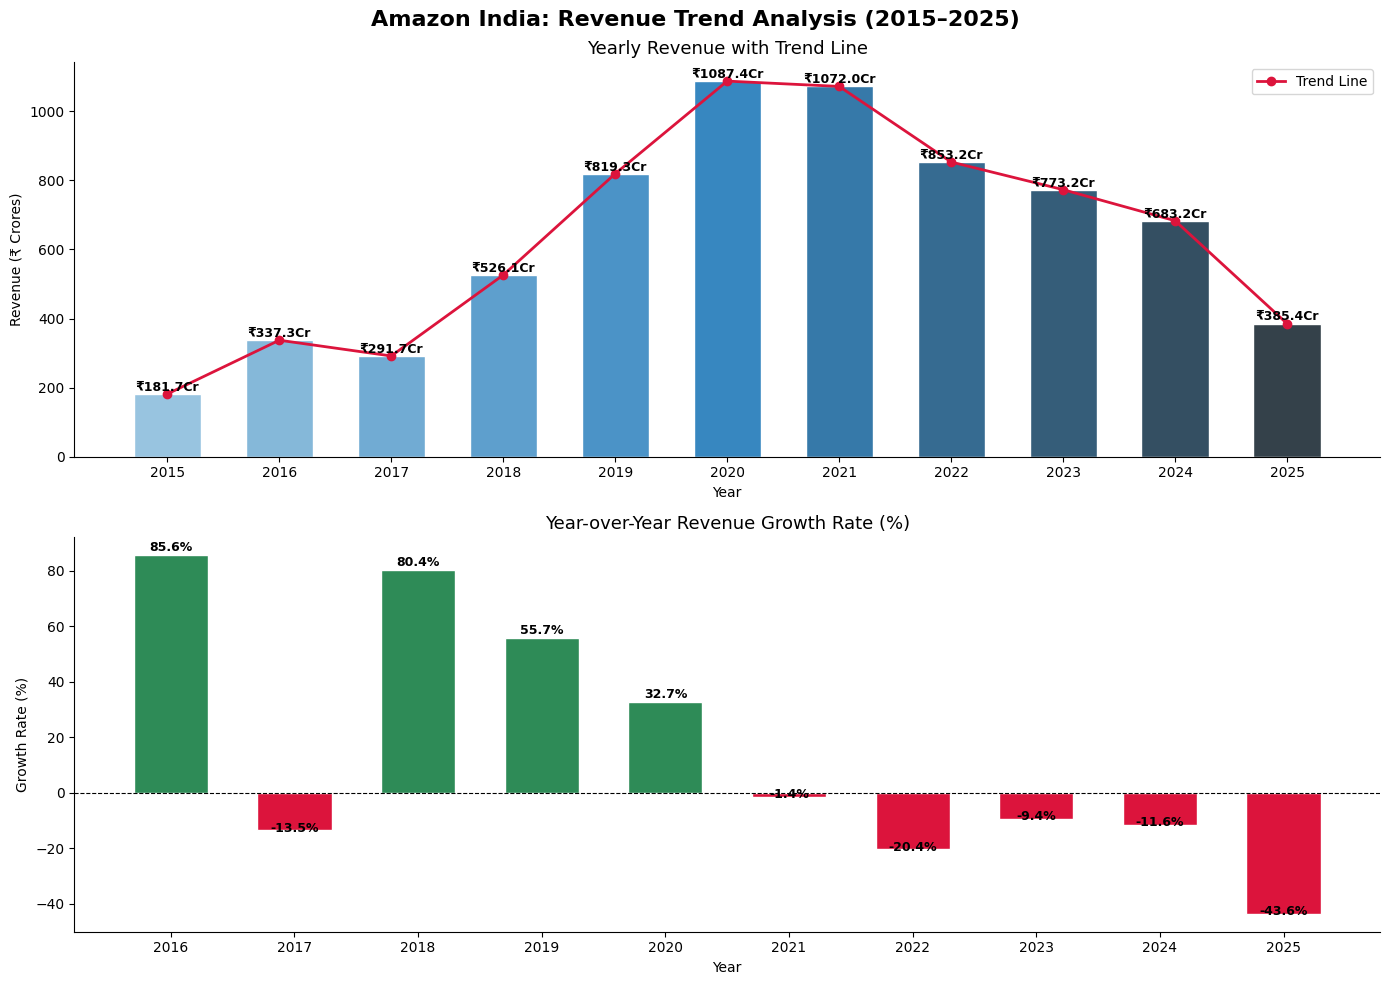

In [19]:
from sqlalchemy import text
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# -- SQL Query ------------------------------------------

query = text("""
    SELECT 
        order_year,
        SUM(final_amount_inr)                          AS total_revenue,
        COUNT(transaction_id)                          AS total_orders,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)       AS avg_order_value
    FROM transactions
    GROUP BY order_year
    ORDER BY order_year
""")

# -- Fetch Data --------------------------------------------

with engine.connect() as conn:
    df_revenue = pd.read_sql(query, conn)

print(df_revenue)

# -- Calculate Growth % in Pandas --------------------------
df_revenue["growth_pct"] = df_revenue["total_revenue"].pct_change() * 100
df_revenue["revenue_cr"] = df_revenue["total_revenue"] / 1e7

print("\nYearly Revenue Summary:")
print(df_revenue.to_string(index=False))

# -- Plotting ----------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Amazon India: Revenue Trend Analysis (2015–2025)", 
             fontsize=16, fontweight="bold")

# -- Plot 1: Revenue Bar + Trend Line ----------------------
ax1 = axes[0]
bars = ax1.bar(df_revenue["order_year"], df_revenue["revenue_cr"],
               color=sns.color_palette("Blues_d", len(df_revenue)), 
               edgecolor="white", width=0.6)
ax1.plot(df_revenue["order_year"], df_revenue["revenue_cr"],
         color="crimson", marker="o", linewidth=2, markersize=6, label="Trend Line")

for bar, val in zip(bars, df_revenue["revenue_cr"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"₹{val:.1f}Cr", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_title("Yearly Revenue with Trend Line", fontsize=13)
ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue (₹ Crores)")
ax1.legend()
ax1.set_xticks(df_revenue["order_year"])
sns.despine(ax=ax1)

# -- Plot 2: YoY Growth Rate ---------------------------------
ax2 = axes[1]
growth_data = df_revenue.dropna(subset=["growth_pct"])
colors = ["seagreen" if x >= 0 else "crimson" for x in growth_data["growth_pct"]]
bars2 = ax2.bar(growth_data["order_year"], growth_data["growth_pct"],
                color=colors, edgecolor="white", width=0.6)

for bar, val in zip(bars2, growth_data["growth_pct"]):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Year-over-Year Revenue Growth Rate (%)", fontsize=13)
ax2.set_xlabel("Year")
ax2.set_ylabel("Growth Rate (%)")
ax2.set_xticks(growth_data["order_year"])
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig("eda_q1_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

Question 2
Analyze seasonal patterns in sales data. Create monthly sales heatmaps and identify peak selling months. Compare seasonal trends across different years and categories.


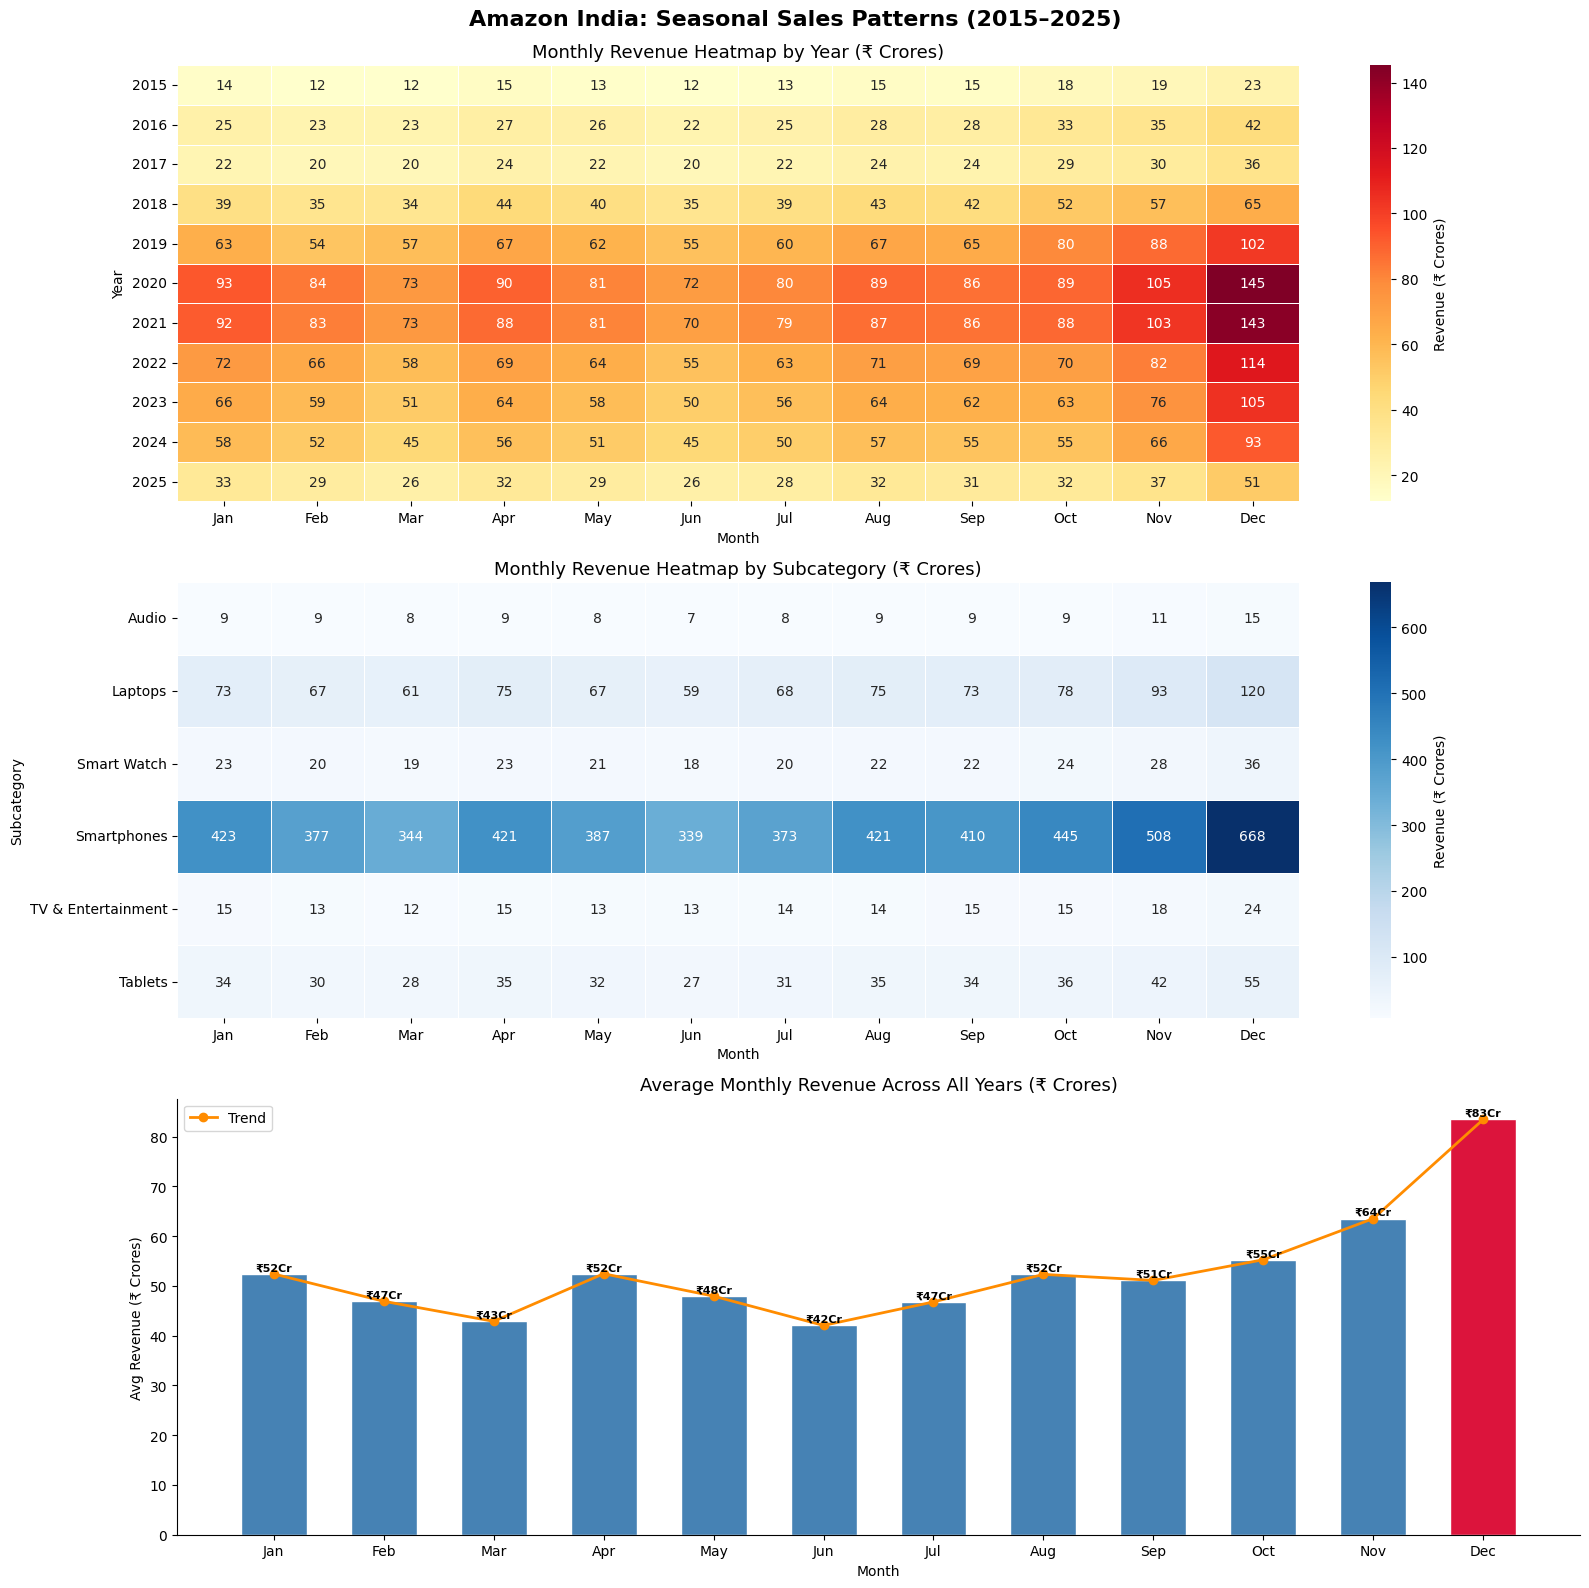

In [20]:
# -- EDA Q2: Seasonal Patterns-----------------------------

# --SQL Query 1: Monthly Revenue by Year-------------------
query1 = text("""
    SELECT 
        order_year,
        order_month,
        SUM(final_amount_inr)                    AS total_revenue,
        COUNT(transaction_id)                    AS total_orders
    FROM transactions
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""")

# -- SQL Query 2: Monthly Revenue by Subcategory ----------
query2 = text("""
    SELECT 
        order_month,
        subcategory,
        SUM(final_amount_inr)                    AS total_revenue
    FROM transactions
    GROUP BY order_month, subcategory
    ORDER BY order_month, subcategory
""")

#-- SQL Query 3: Average Monthly Revenue ------------------
query3 = text("""
    SELECT 
        order_month,
        ROUND(AVG(monthly_revenue)::NUMERIC, 2)  AS avg_revenue
    FROM (
        SELECT 
            order_year,
            order_month,
            SUM(final_amount_inr) AS monthly_revenue
        FROM transactions
        GROUP BY order_year, order_month
    ) AS monthly_data
    GROUP BY order_month
    ORDER BY order_month
""")

# -- Fetch Data --------------------------------------------
with engine.connect() as conn:
    df_monthly      = pd.read_sql(query1, conn)
    df_sub_monthly  = pd.read_sql(query2, conn)
    df_avg_monthly  = pd.read_sql(query3, conn)

# -- Data Prep for Heatmaps --------------------------------
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

heatmap_data = df_monthly.pivot(
    index="order_year", columns="order_month", values="total_revenue"
) / 1e7
heatmap_data.columns = month_labels

category_pivot = df_sub_monthly.pivot(
    index="subcategory", columns="order_month", values="total_revenue"
).fillna(0) / 1e7
category_pivot.columns = month_labels

df_avg_monthly["avg_revenue_cr"] = df_avg_monthly["avg_revenue"] / 1e7

# -- Plotting -----------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(16, 16))
fig.suptitle("Amazon India: Seasonal Sales Patterns (2015–2025)", 
             fontsize=16, fontweight="bold", y=0.99)

# -- Plot 1: Yearly x Monthly Heatmap -----------------------
ax1 = axes[0]
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax1, cbar_kws={"label": "Revenue (₹ Crores)"})
ax1.set_title("Monthly Revenue Heatmap by Year (₹ Crores)", fontsize=13)
ax1.set_xlabel("Month")
ax1.set_ylabel("Year")
ax1.tick_params(axis="x", rotation=0)
ax1.tick_params(axis="y", rotation=0)

# -- Plot 2: Subcategory x Monthly Heatmap -------------------
ax2 = axes[1]
sns.heatmap(category_pivot, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, ax=ax2, cbar_kws={"label": "Revenue (₹ Crores)"})
ax2.set_title("Monthly Revenue Heatmap by Subcategory (₹ Crores)", fontsize=13)
ax2.set_xlabel("Month")
ax2.set_ylabel("Subcategory")
ax2.tick_params(axis="x", rotation=0)
ax2.tick_params(axis="y", rotation=0)

# -- Plot 3: Average Monthly Revenue Bar ----------------------
ax3 = axes[2]
colors = ["crimson" if v == df_avg_monthly["avg_revenue_cr"].max() 
          else "steelblue" for v in df_avg_monthly["avg_revenue_cr"]]
bars = ax3.bar(month_labels, df_avg_monthly["avg_revenue_cr"],
               color=colors, edgecolor="white", width=0.6)
ax3.plot(month_labels, df_avg_monthly["avg_revenue_cr"],
         color="darkorange", marker="o", linewidth=2, markersize=6, label="Trend")

for bar, val in zip(bars, df_avg_monthly["avg_revenue_cr"]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"₹{val:.0f}Cr", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax3.set_title("Average Monthly Revenue Across All Years (₹ Crores)", fontsize=13)
ax3.set_xlabel("Month")
ax3.set_ylabel("Avg Revenue (₹ Crores)")
ax3.legend()
sns.despine(ax=ax3)

plt.tight_layout()
plt.savefig("eda_q2_seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

Question 3
Build a customer segmentation analysis using RFM (Recency, Frequency, Monetary) methodology. Create scatter plots and segment customers into meaningful groups with actionable insights.


RFM data shape: (354362, 8)
          customer_id  recency  frequency   monetary  r_score  f_score  \
0  CUST_2017_00017866     2201          7  683482.09        5        5   
1  CUST_2018_00010880     2249          6  362303.58        5        5   
2  CUST_2015_00009515     2206          6  401703.64        5        5   
3  CUST_2017_00010290     2201          6  417291.99        5        5   
4  CUST_2017_00020180     2265          8  326821.25        5        5   

   m_score  rfm_score  
0        5         15  
1        5         15  
2        5         15  
3        5         15  
4        5         15  


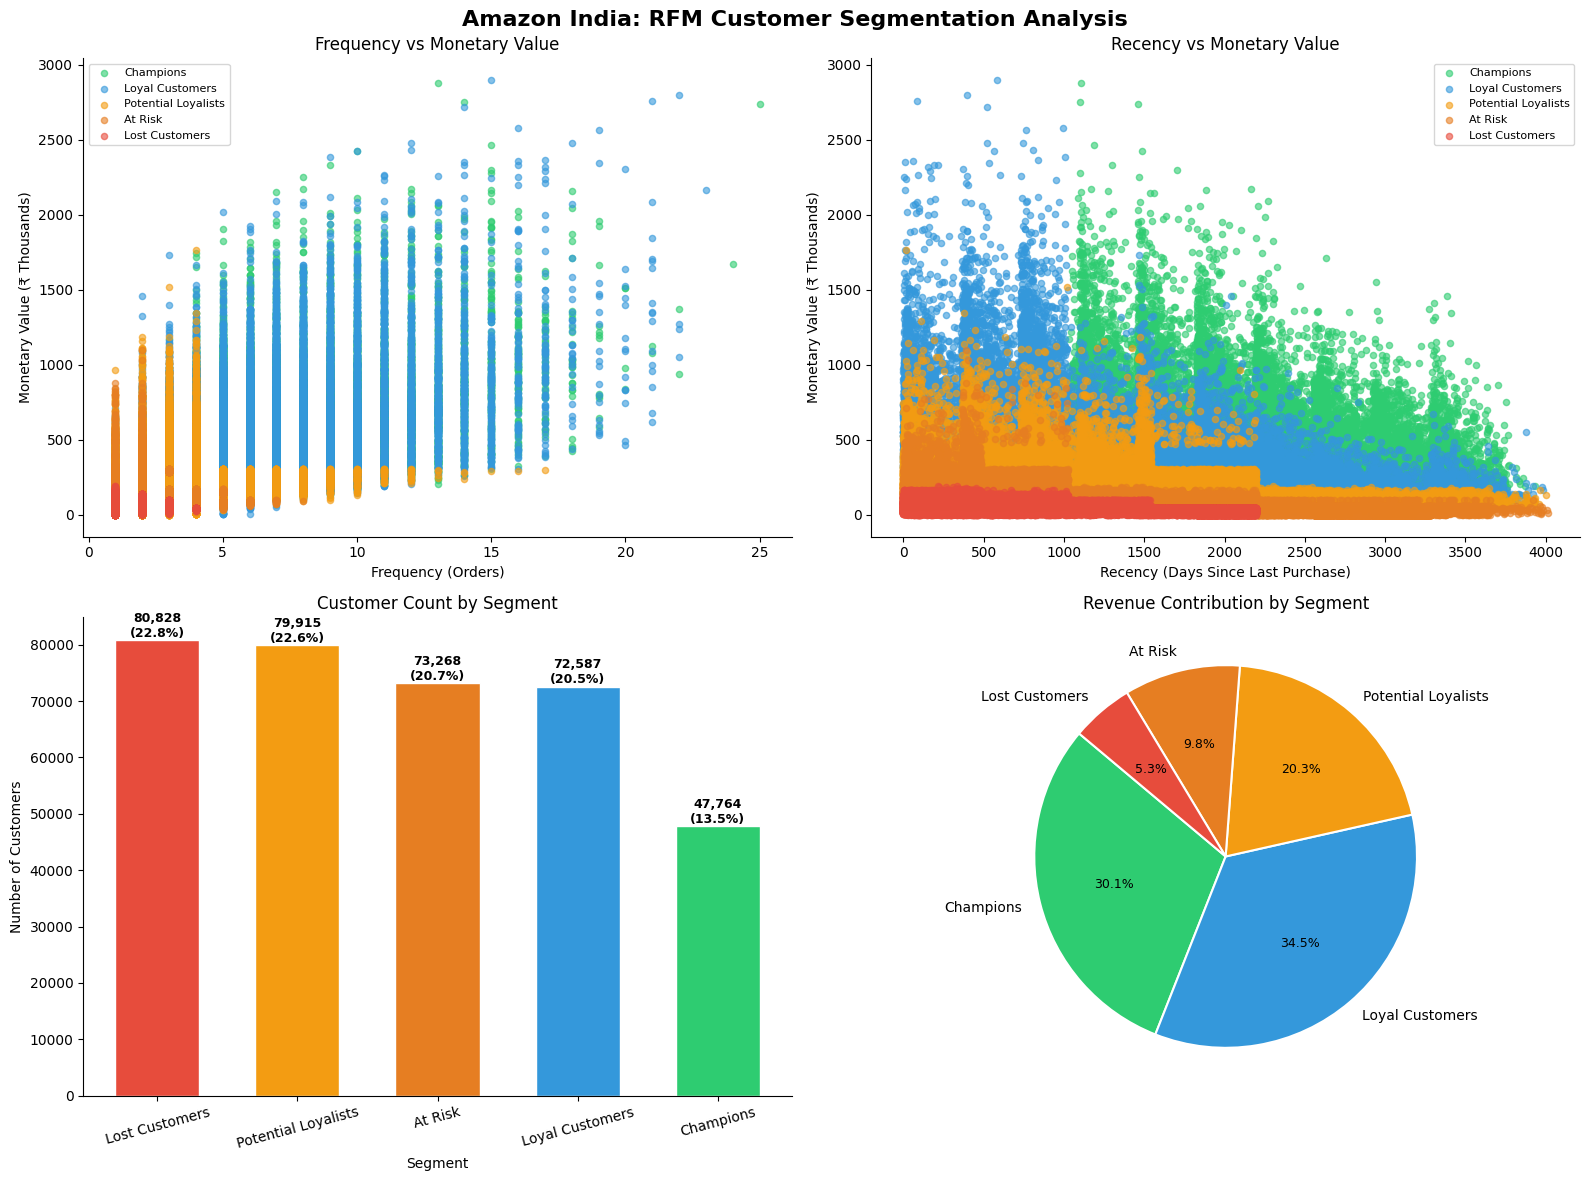

                     customers  avg_recency  avg_frequency  avg_monetary
segment                                                                 
At Risk                  73268      1379.55           1.96      94004.29
Champions                47764      2100.00           6.18     442141.46
Lost Customers           80828       776.91           1.39      45564.73
Loyal Customers          72587      1464.21           4.57     333220.84
Potential Loyalists      79915      1392.12           2.91     178040.99


In [21]:
# -- EDA Q3: RFM Customer Segmentation -----------------------

# -- SQL Query: RFM Calculation ------------------------------
query_rfm = text("""
    WITH rfm_base AS (
        SELECT
            customer_id,
            MAX(order_date::DATE)                               AS last_purchase_date,
            COUNT(transaction_id)                               AS frequency,
            SUM(final_amount_inr)                               AS monetary
        FROM transactions
        GROUP BY customer_id
    ),
    snapshot AS (
        SELECT MAX(order_date::DATE) AS max_date FROM transactions
    ),
    rfm_scores AS (
        SELECT
            r.customer_id,
            (s.max_date - r.last_purchase_date)                 AS recency,
            r.frequency,
            r.monetary,
            NTILE(5) OVER (ORDER BY r.last_purchase_date DESC)  AS r_score,
            NTILE(5) OVER (ORDER BY r.frequency ASC)            AS f_score,
            NTILE(5) OVER (ORDER BY r.monetary ASC)             AS m_score
        FROM rfm_base r, snapshot s
    )
    SELECT
        customer_id,
        recency,
        frequency,
        monetary,
        r_score,
        f_score,
        m_score,
        (r_score + f_score + m_score) AS rfm_score
    FROM rfm_scores
    ORDER BY rfm_score DESC
""")

with engine.connect() as conn:
    df_rfm = pd.read_sql(query_rfm, conn)

print(f"RFM data shape: {df_rfm.shape}")
print(df_rfm.head())

# -- Segment Customers in Pandas ----------------------------
def segment_customer(score):
    if score >= 13:
        return "Champions"
    elif score >= 11:
        return "Loyal Customers"
    elif score >= 9:
        return "Potential Loyalists"
    elif score >= 7:
        return "At Risk"
    else:
        return "Lost Customers"

df_rfm["segment"] = df_rfm["rfm_score"].apply(segment_customer)

segment_colors = {
    "Champions":           "#2ecc71",
    "Loyal Customers":     "#3498db",
    "Potential Loyalists": "#f39c12",
    "At Risk":             "#e67e22",
    "Lost Customers":      "#e74c3c"
}

# -- Plotting ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Amazon India: RFM Customer Segmentation Analysis",
             fontsize=16, fontweight="bold")

# -- Plot 1: Frequency vs Monetary --------------------
ax1 = axes[0, 0]
for seg, color in segment_colors.items():
    data = df_rfm[df_rfm["segment"] == seg]
    ax1.scatter(data["frequency"], data["monetary"] / 1e3,
                c=color, label=seg, alpha=0.6, s=20)
ax1.set_title("Frequency vs Monetary Value", fontsize=12)
ax1.set_xlabel("Frequency (Orders)")
ax1.set_ylabel("Monetary Value (₹ Thousands)")
ax1.legend(fontsize=8)
sns.despine(ax=ax1)

# -- Plot 2: Recency vs Monetary ------------------------
ax2 = axes[0, 1]
for seg, color in segment_colors.items():
    data = df_rfm[df_rfm["segment"] == seg]
    ax2.scatter(data["recency"], data["monetary"] / 1e3,
                c=color, label=seg, alpha=0.6, s=20)
ax2.set_title("Recency vs Monetary Value", fontsize=12)
ax2.set_xlabel("Recency (Days Since Last Purchase)")
ax2.set_ylabel("Monetary Value (₹ Thousands)")
ax2.legend(fontsize=8)
sns.despine(ax=ax2)

# -- Plot 3: Customer Count by Segment ----------------
ax3 = axes[1, 0]
segment_counts = df_rfm["segment"].value_counts()
bars = ax3.bar(segment_counts.index,
               segment_counts.values,
               color=[segment_colors[s] for s in segment_counts.index],
               edgecolor="white", width=0.6)
for bar, val in zip(bars, segment_counts.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f"{val:,}\n({val/len(df_rfm)*100:.1f}%)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_title("Customer Count by Segment", fontsize=12)
ax3.set_xlabel("Segment")
ax3.set_ylabel("Number of Customers")
ax3.tick_params(axis="x", rotation=15)
sns.despine(ax=ax3)

# -- Plot 4: Revenue Contribution by Segment ----------
ax4 = axes[1, 1]
segment_revenue = df_rfm.groupby("segment")["monetary"].sum().reindex(segment_colors.keys())
wedges, texts, autotexts = ax4.pie(
    segment_revenue,
    labels=segment_revenue.index,
    colors=[segment_colors[s] for s in segment_revenue.index],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in autotexts:
    text.set_fontsize(9)
ax4.set_title("Revenue Contribution by Segment", fontsize=12)

plt.tight_layout()
plt.savefig("eda_q3_rfm_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()

# -- Summary Table --------------------------------------
summary = df_rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean")
).round(2)
print(summary.to_string())

Question 4
Visualize the evolution of payment methods from 2015-2025. Show the rise of UPI, decline of COD, and create stacked area charts to demonstrate market share changes over time.


payment_method  total_transactions  revenue_cr  avg_order_value
           UPI              382930     2426.93         63377.87
           COD              316543     1922.48         60733.53
   Credit Card              170484     1083.67         63564.56
    Debit Card              138727      890.96         64224.24
   Net Banking               64310      417.98         64995.17
        Wallet               22821      153.39         67214.01
          BNPL               20295      115.03         56680.71


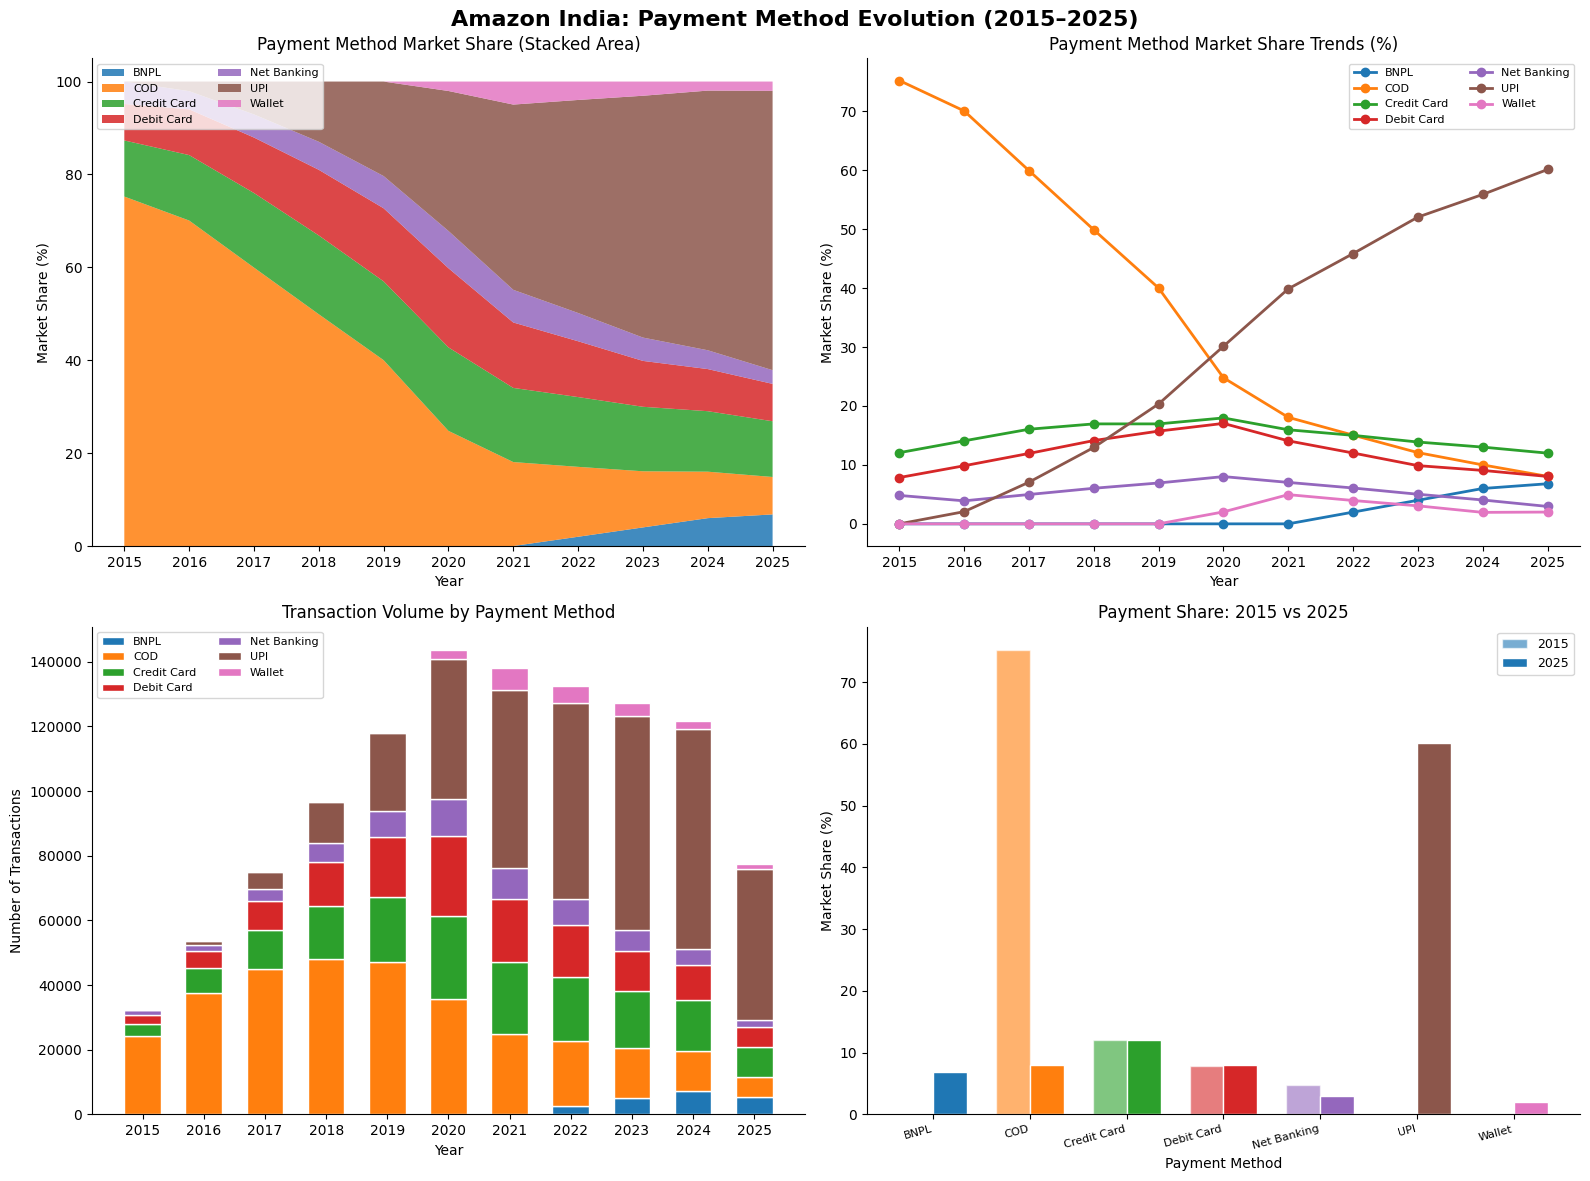

In [22]:

from sqlalchemy import text
# -- EDA Q4: Payment Method Evolution -------------------

# -- SQL Query 1: Yearly Payment Method Transactions ---
query_payment = text("""
    SELECT
        order_year,
        payment_method,
        COUNT(transaction_id)                          AS transactions,
        SUM(final_amount_inr)                          AS total_revenue,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)       AS avg_order_value
    FROM transactions
    GROUP BY order_year, payment_method
    ORDER BY order_year, payment_method
""")

# -- SQL Query 2: Overall Payment Method Summary -----
query_payment_summary = text("""
    SELECT
        payment_method,
        COUNT(transaction_id)                                   AS total_transactions,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value
    FROM transactions
    GROUP BY payment_method
    ORDER BY total_transactions DESC
""")
# -- Fetch Data ------------------------------------------
with engine.connect() as conn:
    df_payment       = pd.read_sql(query_payment, conn)
    df_payment_summary = pd.read_sql(query_payment_summary, conn)

print(df_payment_summary.to_string(index=False))

# -- Data Prep ------------------------------------------
# Market share % per year
df_payment["market_share"] = df_payment.groupby("order_year")["transactions"].transform(
    lambda x: x / x.sum() * 100
)

# Pivot for charts
payment_pivot = df_payment.pivot(
    index="order_year", columns="payment_method", values="market_share"
).fillna(0)

payment_volume = df_payment.pivot(
    index="order_year", columns="payment_method", values="transactions"
).fillna(0)

palette = sns.color_palette("tab10", len(payment_pivot.columns))
payment_colors = {col: palette[i] for i, col in enumerate(payment_pivot.columns)}

# -- Plotting ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Amazon India: Payment Method Evolution (2015–2025)",
             fontsize=16, fontweight="bold")

# -- Plot 1: Stacked Area Chart -------------------------
ax1 = axes[0, 0]
ax1.stackplot(payment_pivot.index, payment_pivot.T,
              labels=payment_pivot.columns,
              colors=palette, alpha=0.85)
ax1.set_title("Payment Method Market Share (Stacked Area)", fontsize=12)
ax1.set_xlabel("Year")
ax1.set_ylabel("Market Share (%)")
ax1.legend(loc="upper left", fontsize=8, ncol=2)
ax1.set_xticks(payment_pivot.index)
sns.despine(ax=ax1)

# -- Plot 2: Line Chart ---------------------------------
ax2 = axes[0, 1]
for col, color in payment_colors.items():
    ax2.plot(payment_pivot.index, payment_pivot[col],
             marker="o", linewidth=2, label=col, color=color)
ax2.set_title("Payment Method Market Share Trends (%)", fontsize=12)
ax2.set_xlabel("Year")
ax2.set_ylabel("Market Share (%)")
ax2.legend(fontsize=8, ncol=2)
ax2.set_xticks(payment_pivot.index)
sns.despine(ax=ax2)

# -- Plot 3: Stacked Bar - Transaction Volume ------------
ax3 = axes[1, 0]
bottom = pd.Series([0] * len(payment_volume), index=payment_volume.index)
for col, color in zip(payment_volume.columns, palette):
    ax3.bar(payment_volume.index, payment_volume[col],
            bottom=bottom, label=col, color=color, edgecolor="white", width=0.6)
    bottom += payment_volume[col]
ax3.set_title("Transaction Volume by Payment Method", fontsize=12)
ax3.set_xlabel("Year")
ax3.set_ylabel("Number of Transactions")
ax3.legend(fontsize=8, ncol=2)
ax3.set_xticks(payment_volume.index)
sns.despine(ax=ax3)

# -- Plot 4: First vs Last Year Comparison -----------------
ax4 = axes[1, 1]
first_year = payment_pivot.iloc[0]
last_year  = payment_pivot.iloc[-1]
x = range(len(payment_pivot.columns))
width = 0.35
ax4.bar([i - width/2 for i in x], first_year,
        width=width, label=str(payment_pivot.index[0]),
        color=palette, alpha=0.6, edgecolor="white")
ax4.bar([i + width/2 for i in x], last_year,
        width=width, label=str(payment_pivot.index[-1]),
        color=palette, alpha=1.0, edgecolor="white")
ax4.set_title(f"Payment Share: {payment_pivot.index[0]} vs {payment_pivot.index[-1]}", fontsize=12)
ax4.set_xlabel("Payment Method")
ax4.set_ylabel("Market Share (%)")
ax4.set_xticks(list(x))
ax4.set_xticklabels(payment_pivot.columns, rotation=15, ha="right", fontsize=8)
ax4.legend(fontsize=9)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q4_payment_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

Question 5
Perform category-wise performance analysis. Create treemaps, bar charts, and pie charts showing revenue contribution, growth rates, and market share for each product category.


       subcategory  revenue_cr  market_share  total_orders  avg_order_value
       Smartphones 5115.022579         72.96        819050         62450.68
           Laptops  908.298746         12.96         87325        104013.60
           Tablets  419.474429          5.98         69343         60492.69
       Smart Watch  276.716418          3.95         73942         37423.44
TV & Entertainment  180.711454          2.58         16298        110879.53
             Audio  110.226693          1.57         50152         21978.52


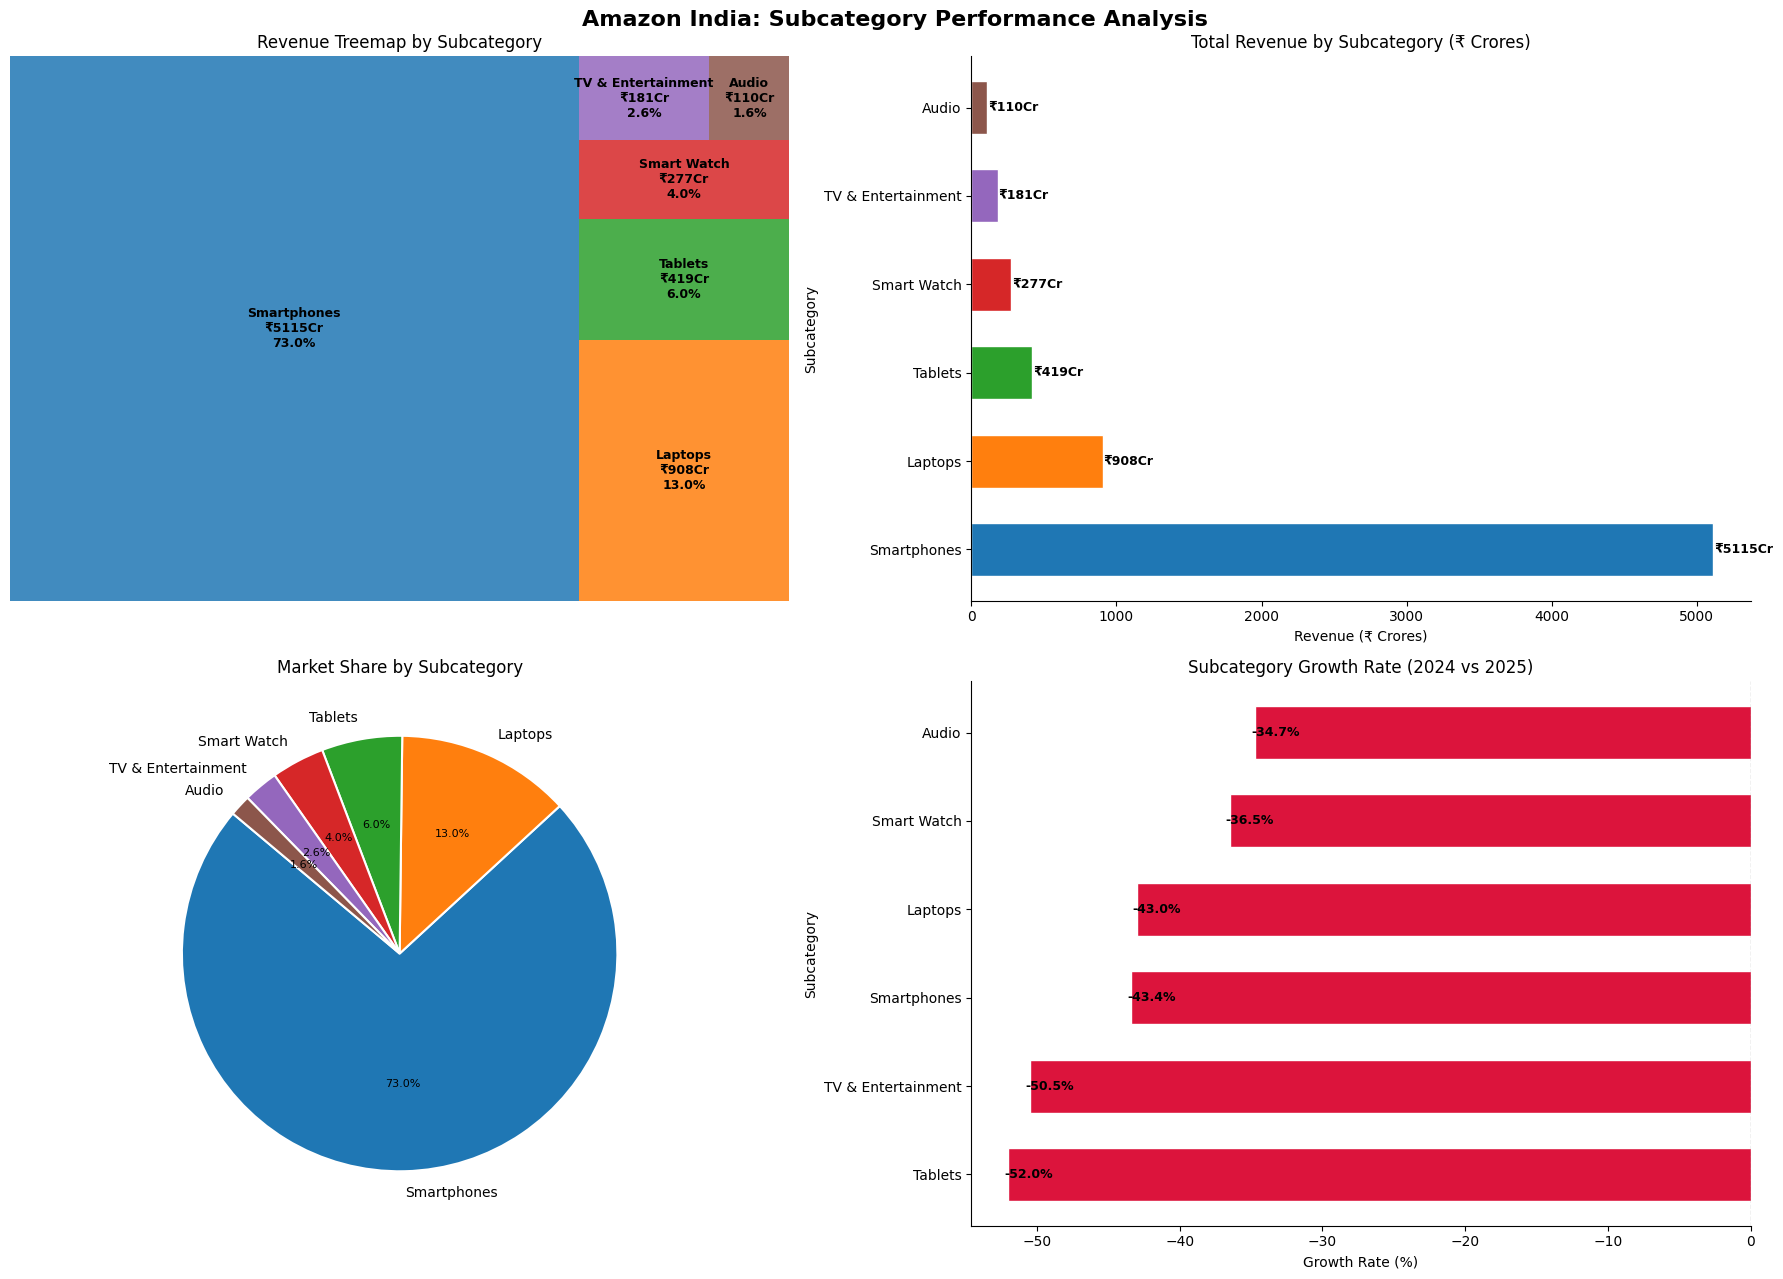

In [23]:
# -- EDA Q5: Subcategory Performance Analysis ------------

# -- SQL Query 1: Subcategory Revenue Summary ------------

query_sub = text("""
    SELECT
        subcategory,
        SUM(final_amount_inr)                               AS total_revenue,
        COUNT(transaction_id)                               AS total_orders,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)            AS avg_order_value,
        ROUND((SUM(final_amount_inr) * 100.0 /
            SUM(SUM(final_amount_inr)) OVER ())::NUMERIC, 2) AS market_share
    FROM transactions
    GROUP BY subcategory
    ORDER BY total_revenue DESC
""")

# -- SQL Query 2: Subcategory Growth (2024 vs 2025) ----
query_sub_growth = text("""
    SELECT
        subcategory,
        SUM(CASE WHEN order_year = 2024 THEN final_amount_inr ELSE 0 END) AS rev_2024,
        SUM(CASE WHEN order_year = 2025 THEN final_amount_inr ELSE 0 END) AS rev_2025,
        ROUND(((SUM(CASE WHEN order_year = 2025 THEN final_amount_inr ELSE 0 END) -
                SUM(CASE WHEN order_year = 2024 THEN final_amount_inr ELSE 0 END)) /
                NULLIF(SUM(CASE WHEN order_year = 2024 THEN final_amount_inr ELSE 0 END), 0)
                * 100)::NUMERIC, 1) AS growth_pct
    FROM transactions
    GROUP BY subcategory
    ORDER BY growth_pct DESC
""")

# -- SQL Query 3: Yearly Subcategory Trend ------------
query_sub_yearly = text("""
    SELECT
        order_year,
        subcategory,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)   AS revenue_cr
    FROM transactions
    GROUP BY order_year, subcategory
    ORDER BY order_year, subcategory
""")

# -- Fetch Data ---------------------------------------
with engine.connect() as conn:
    df_sub          = pd.read_sql(query_sub, conn)
    df_sub_growth   = pd.read_sql(query_sub_growth, conn)
    df_sub_yearly   = pd.read_sql(query_sub_yearly, conn)

df_sub["revenue_cr"] = df_sub["total_revenue"] / 1e7

print(df_sub[["subcategory", "revenue_cr", "market_share", "total_orders", "avg_order_value"]].to_string(index=False))

# -- Plotting ------------------------------------------
import squarify

palette     = sns.color_palette("tab10", len(df_sub))
sub_colors  = {sub: palette[i] for i, sub in enumerate(df_sub["subcategory"])}

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Subcategory Performance Analysis",
             fontsize=16, fontweight="bold")

# -- Plot 1: Treemap ------------------------------------
ax1 = axes[0, 0]
squarify.plot(
    sizes=df_sub["revenue_cr"],
    label=[f"{row['subcategory']}\n₹{row['revenue_cr']:.0f}Cr\n{row['market_share']:.1f}%"
           for _, row in df_sub.iterrows()],
    color=[sub_colors[s] for s in df_sub["subcategory"]],
    alpha=0.85, ax=ax1, text_kwargs={"fontsize": 9, "fontweight": "bold"}
)
ax1.set_title("Revenue Treemap by Subcategory", fontsize=12)
ax1.axis("off")

# -- Plot 2: Horizontal Bar ------------------------------
ax2 = axes[0, 1]
bars = ax2.barh(df_sub["subcategory"], df_sub["revenue_cr"],
                color=[sub_colors[s] for s in df_sub["subcategory"]],
                edgecolor="white", height=0.6)
for bar, val in zip(bars, df_sub["revenue_cr"]):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f"₹{val:.0f}Cr", va="center", fontsize=9, fontweight="bold")
ax2.set_title("Total Revenue by Subcategory (₹ Crores)", fontsize=12)
ax2.set_xlabel("Revenue (₹ Crores)")
ax2.set_ylabel("Subcategory")
sns.despine(ax=ax2)

# -- Plot 3: Pie Chart -------------------------------------
ax3 = axes[1, 0]
wedges, texts, autotexts = ax3.pie(
    df_sub["market_share"],
    labels=df_sub["subcategory"],
    colors=[sub_colors[s] for s in df_sub["subcategory"]],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in autotexts:
    text.set_fontsize(8)
ax3.set_title("Market Share by Subcategory", fontsize=12)

# -- Plot 4: Growth Rate -----------------------------------
ax4 = axes[1, 1]
df_sub_growth_sorted = df_sub_growth.sort_values("growth_pct", ascending=True)
colors_growth = ["seagreen" if x >= 0 else "crimson"
                 for x in df_sub_growth_sorted["growth_pct"]]
bars4 = ax4.barh(df_sub_growth_sorted["subcategory"],
                 df_sub_growth_sorted["growth_pct"],
                 color=colors_growth, edgecolor="white", height=0.6)
for bar, val in zip(bars4, df_sub_growth_sorted["growth_pct"]):
    ax4.text(bar.get_width() + 0.3 if val >= 0 else bar.get_width() - 0.3,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax4.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax4.set_title("Subcategory Growth Rate (2024 vs 2025)", fontsize=12)
ax4.set_xlabel("Growth Rate (%)")
ax4.set_ylabel("Subcategory")
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q5_subcategory_performance.png", dpi=150, bbox_inches="tight")
plt.show()

Question 6
Analyze Prime membership impact on customer behavior. Compare average order values, order frequency, and category preferences between Prime and non-Prime customers using multiple visualization types.


 is_prime_member  total_orders  revenue_cr  avg_order_value  avg_discount  avg_delivery_days  unique_customers
            True        427593     3185.88         74507.32         17.32               1.72            160523
           False        688517     3824.57         55547.93         17.48               4.32            193839


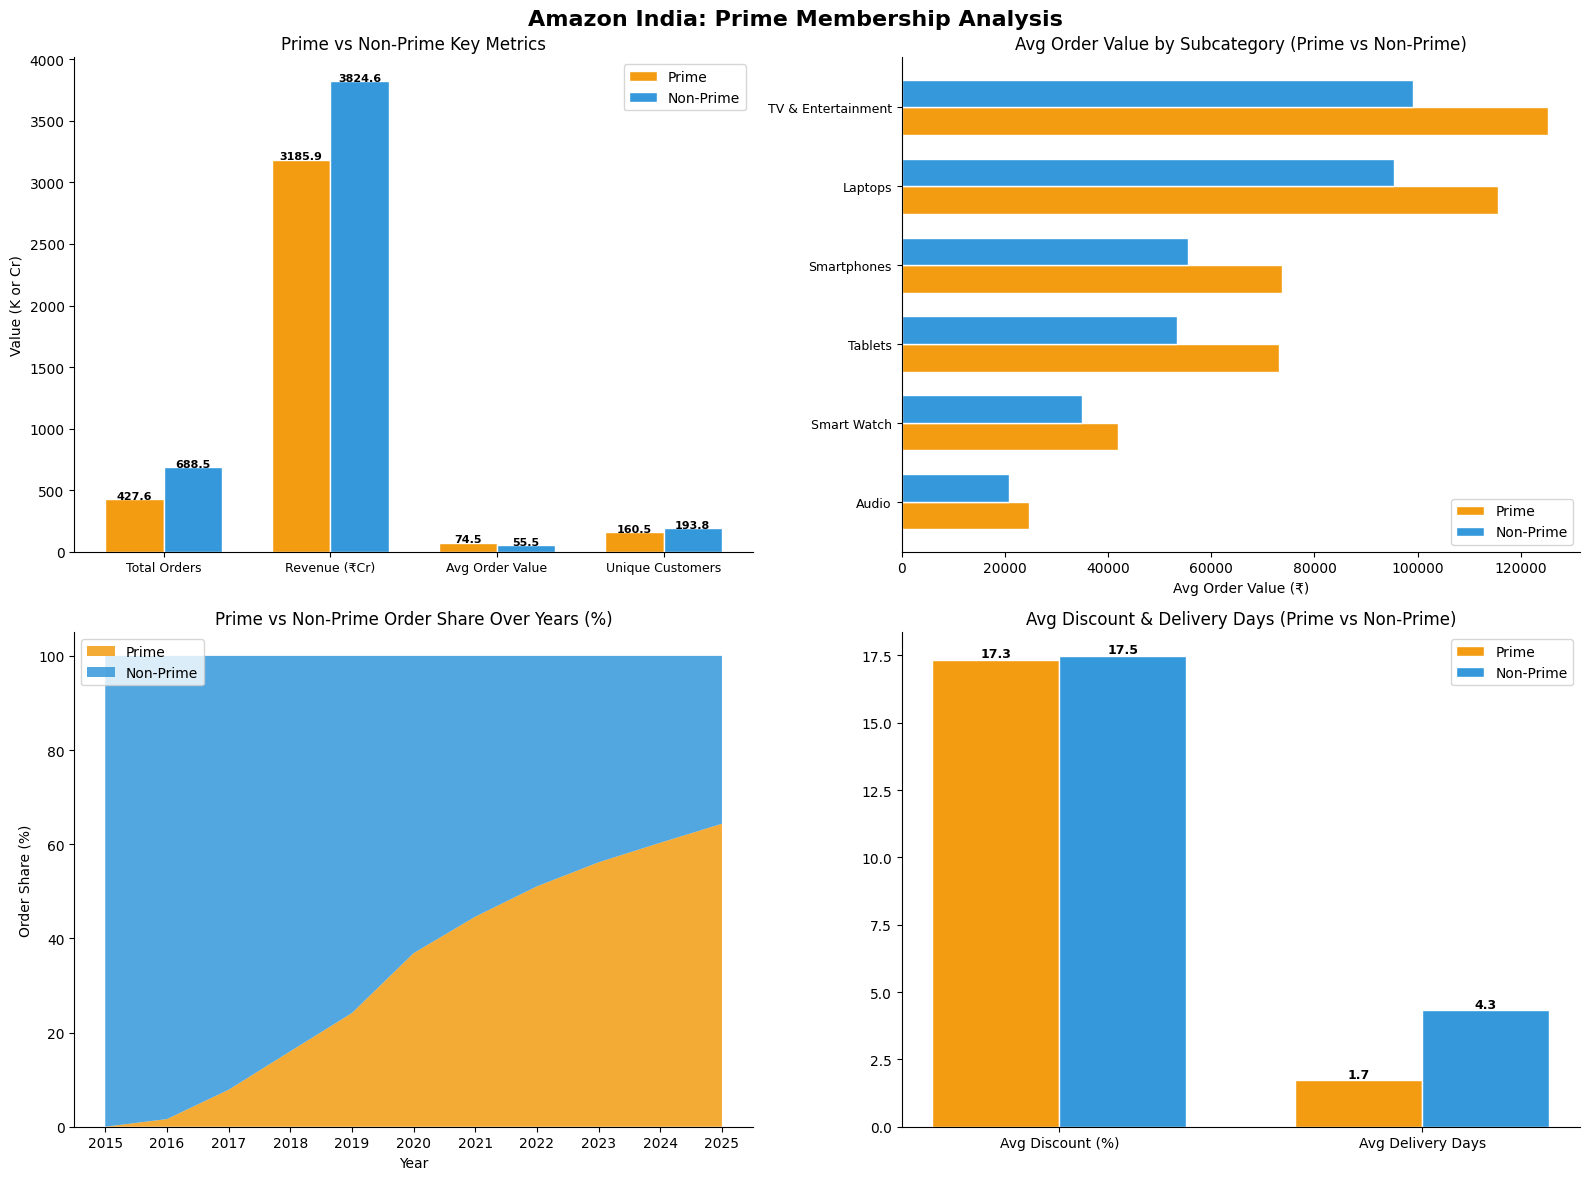

In [24]:
from sqlalchemy import text

# -- EDA Q6: Prime Membership Analysis ------------------

# -- SQL Query 1: Prime vs Non-Prime Overview -----------
query_prime = text("""
    SELECT
        is_prime_member,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        ROUND(AVG(delivery_days)::NUMERIC, 2)                  AS avg_delivery_days,
        COUNT(DISTINCT customer_id)                             AS unique_customers
    FROM transactions
    GROUP BY is_prime_member
    ORDER BY is_prime_member DESC
""")

# -- SQL Query 2: Prime vs Non-Prime by Subcategory -----
query_prime_sub = text("""
    SELECT
        subcategory,
        is_prime_member,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    GROUP BY subcategory, is_prime_member
    ORDER BY subcategory, is_prime_member DESC
""")

# -- SQL Query 3: Prime Membership Growth by Year --------
query_prime_yearly = text("""
    SELECT
        order_year,
        is_prime_member,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER (PARTITION BY order_year))::NUMERIC, 2)
                                                                AS order_share
    FROM transactions
    GROUP BY order_year, is_prime_member
    ORDER BY order_year, is_prime_member DESC
""")

# -- Fetch Data -----------------------------------------
with engine.connect() as conn:
    df_prime         = pd.read_sql(query_prime, conn)
    df_prime_sub     = pd.read_sql(query_prime_sub, conn)
    df_prime_yearly  = pd.read_sql(query_prime_yearly, conn)

print(df_prime.to_string(index=False))

# -- Plotting -------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Amazon India: Prime Membership Analysis",
             fontsize=16, fontweight="bold")

prime_colors = {True: "#f39c12", False: "#3498db"}
labels       = {True: "Prime", False: "Non-Prime"}

# -- Plot 1: Revenue & Orders Comparison ----------------
ax1 = axes[0, 0]
x      = ["Total Orders", "Revenue (₹Cr)", "Avg Order Value", "Unique Customers"]
prime  = df_prime[df_prime["is_prime_member"] == True].iloc[0]
nonprime = df_prime[df_prime["is_prime_member"] == False].iloc[0]

metrics_prime    = [prime["total_orders"] / 1e3,
                    float(prime["revenue_cr"]),
                    float(prime["avg_order_value"]) / 1e3,
                    prime["unique_customers"] / 1e3]
metrics_nonprime = [nonprime["total_orders"] / 1e3,
                    float(nonprime["revenue_cr"]),
                    float(nonprime["avg_order_value"]) / 1e3,
                    nonprime["unique_customers"] / 1e3]

x_pos = range(len(x))
width = 0.35
bars1 = ax1.bar([i - width/2 for i in x_pos], metrics_prime,
                width=width, label="Prime", color="#f39c12", edgecolor="white")
bars2 = ax1.bar([i + width/2 for i in x_pos], metrics_nonprime,
                width=width, label="Non-Prime", color="#3498db", edgecolor="white")
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")
ax1.set_title("Prime vs Non-Prime Key Metrics", fontsize=12)
ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(x, fontsize=9)
ax1.legend()
ax1.set_ylabel("Value (K or Cr)")
sns.despine(ax=ax1)

# -- Plot 2: Avg Order Value by Subcategory ---------------
ax2 = axes[0, 1]
prime_pivot = df_prime_sub.pivot(
    index="subcategory", columns="is_prime_member", values="avg_order_value"
)
prime_pivot.columns = ["Non-Prime", "Prime"]
prime_pivot = prime_pivot.sort_values("Prime", ascending=True)
x2    = range(len(prime_pivot))
bars3 = ax2.barh([i - width/2 for i in x2], prime_pivot["Prime"],
                 height=width, label="Prime", color="#f39c12", edgecolor="white")
bars4 = ax2.barh([i + width/2 for i in x2], prime_pivot["Non-Prime"],
                 height=width, label="Non-Prime", color="#3498db", edgecolor="white")
ax2.set_yticks(list(x2))
ax2.set_yticklabels(prime_pivot.index, fontsize=9)
ax2.set_title("Avg Order Value by Subcategory (Prime vs Non-Prime)", fontsize=12)
ax2.set_xlabel("Avg Order Value (₹)")
ax2.legend()
sns.despine(ax=ax2)

# -- Plot 3: Prime Membership Growth Over Years ------------------
ax3 = axes[1, 0]
prime_yearly_pivot = df_prime_yearly.pivot(
    index="order_year", columns="is_prime_member", values="order_share"
).fillna(0)
prime_yearly_pivot.columns = ["Non-Prime", "Prime"]
ax3.stackplot(prime_yearly_pivot.index,
              prime_yearly_pivot["Prime"],
              prime_yearly_pivot["Non-Prime"],
              labels=["Prime", "Non-Prime"],
              colors=["#f39c12", "#3498db"], alpha=0.85)
ax3.set_title("Prime vs Non-Prime Order Share Over Years (%)", fontsize=12)
ax3.set_xlabel("Year")
ax3.set_ylabel("Order Share (%)")
ax3.legend(loc="upper left")
ax3.set_xticks(prime_yearly_pivot.index)
sns.despine(ax=ax3)

# -- Plot 4: Avg Discount & Delivery Days -------------------
ax4 = axes[1, 1]
metrics2       = ["Avg Discount (%)", "Avg Delivery Days"]
prime_vals     = [float(prime["avg_discount"]), float(prime["avg_delivery_days"])]
nonprime_vals  = [float(nonprime["avg_discount"]), float(nonprime["avg_delivery_days"])]
x3 = range(len(metrics2))
ax4.bar([i - width/2 for i in x3], prime_vals,
        width=width, label="Prime", color="#f39c12", edgecolor="white")
ax4.bar([i + width/2 for i in x3], nonprime_vals,
        width=width, label="Non-Prime", color="#3498db", edgecolor="white")
for i, (pv, nv) in enumerate(zip(prime_vals, nonprime_vals)):
    ax4.text(i - width/2, pv + 0.1, f"{pv:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax4.text(i + width/2, nv + 0.1, f"{nv:.1f}", ha="center", fontsize=9, fontweight="bold")
ax4.set_title("Avg Discount & Delivery Days (Prime vs Non-Prime)", fontsize=12)
ax4.set_xticks(list(x3))
ax4.set_xticklabels(metrics2, fontsize=10)
ax4.legend()
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q6_prime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Question 7
Create geographic analysis of sales performance across Indian cities and states. Build choropleth maps and bar charts showing revenue density and growth patterns by tier (Metro/Tier1/Tier2/Rural).


=== State-wise Revenue (Top 10) ===
customer_state  total_orders  revenue_cr  avg_order_value  unique_customers
   Maharashtra        243948     1590.88         65213.76             76143
         Delhi        121967      828.33         67914.12             36818
    Tamil Nadu        110216      711.80         64582.13             34042
     Karnataka        101263      684.86         67632.08             30556
       Gujarat        111393      670.73         60213.11             36890
 Uttar Pradesh        117484      640.27         54498.32             39682
   West Bengal         66053      450.17         68152.36             20054
     Telangana         44029      298.29         67748.20             13328
     Rajasthan         40122      247.06         61576.96             13251
        Punjab         38175      206.53         54100.39             12943

=== Tier-wise Revenue ===
customer_tier  total_orders  revenue_cr  avg_order_value  unique_customers  order_share
        Metro

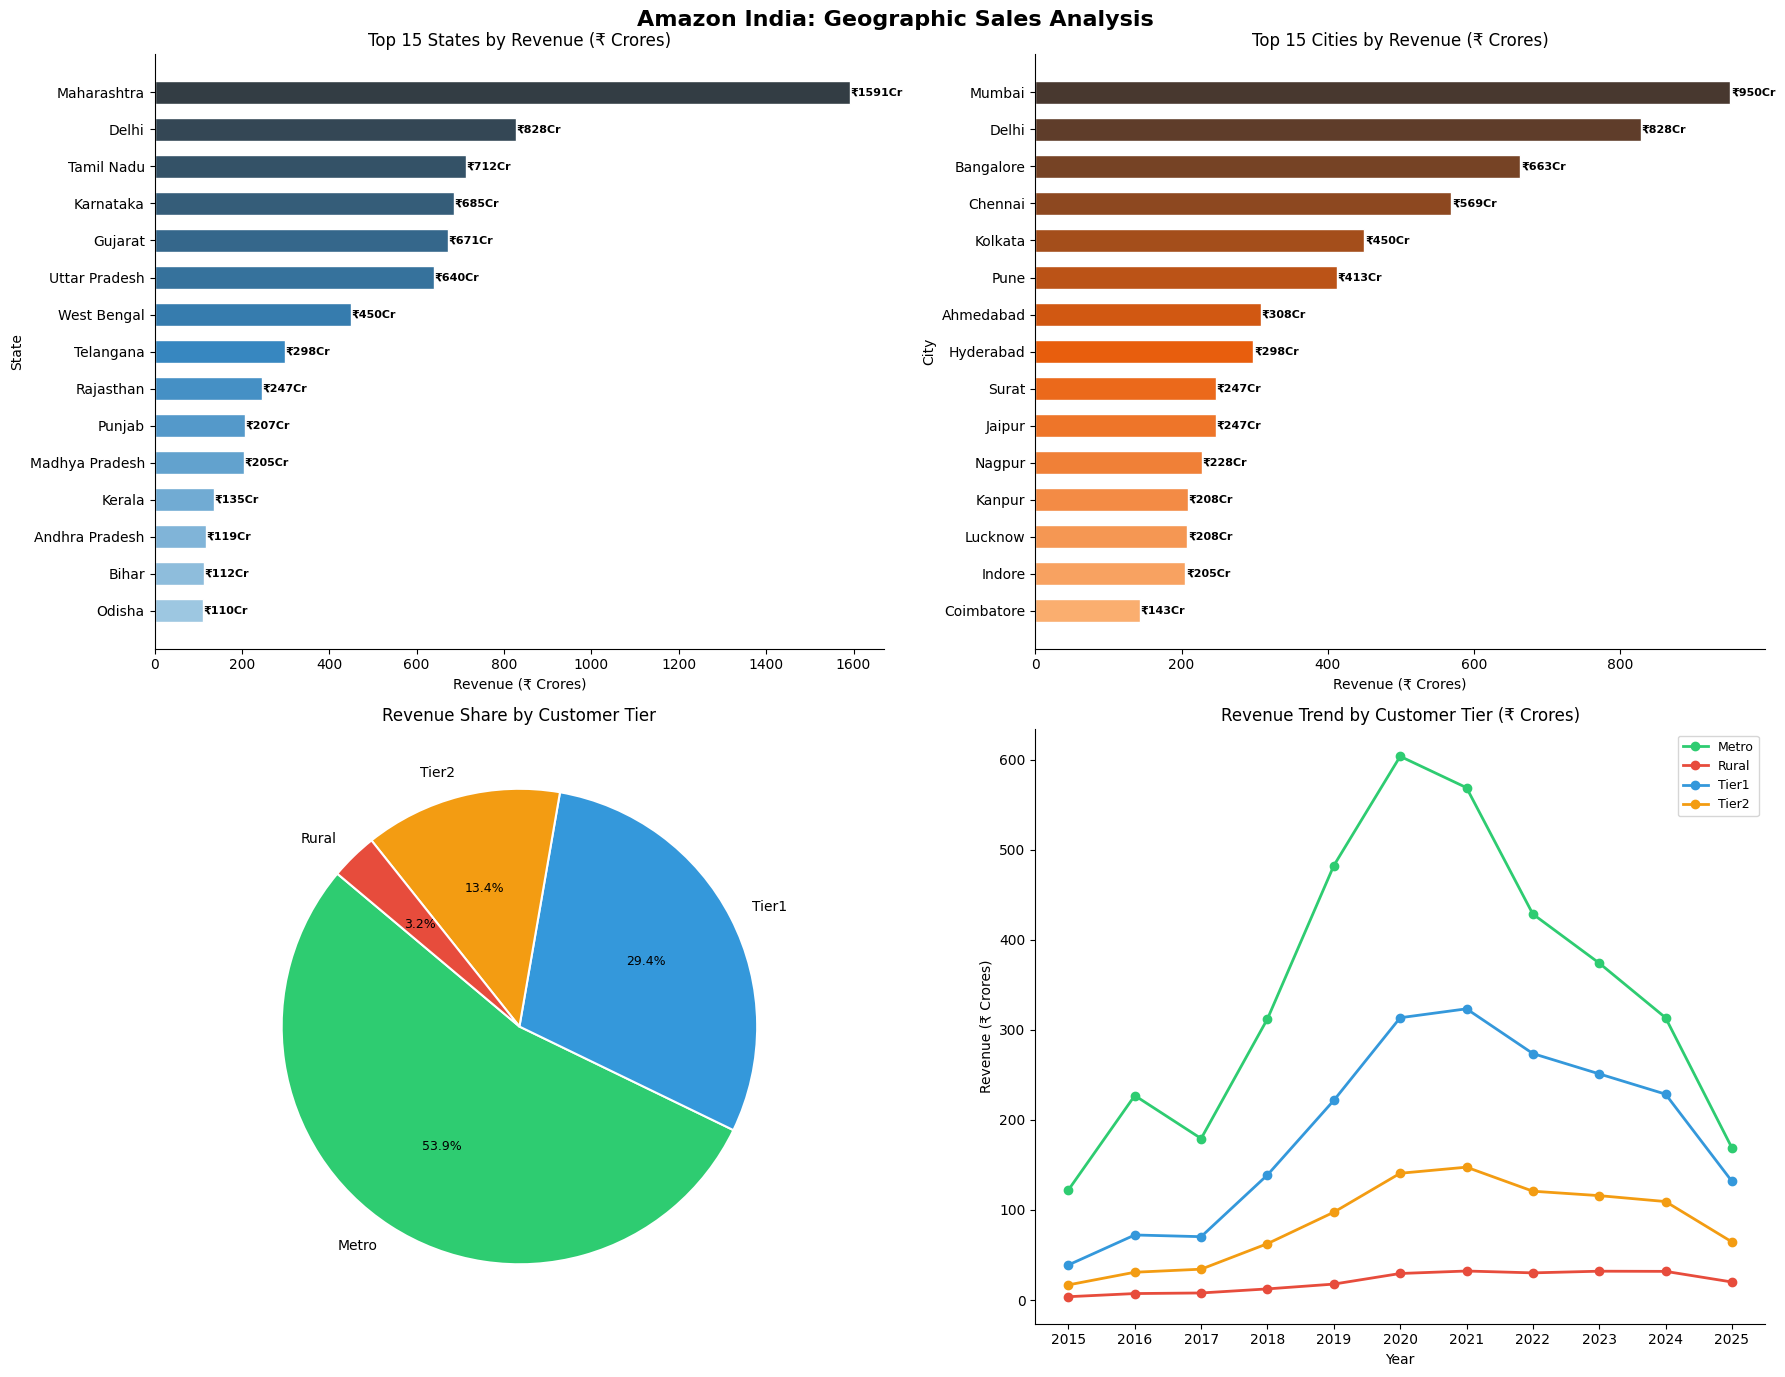

In [25]:
# -- EDA Q7: Geographic Analysis -----------------------

# -- SQL Query 1: State-wise Revenue -------------------
query_state = text("""
    SELECT
        customer_state,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        COUNT(DISTINCT customer_id)                             AS unique_customers
    FROM transactions
    GROUP BY customer_state
    ORDER BY revenue_cr DESC
""")

# -- SQL Query 2: City-wise Revenue (Top 15) ------------
query_city = text("""
    SELECT
        customer_city,
        customer_state,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value
    FROM transactions
    GROUP BY customer_city, customer_state
    ORDER BY revenue_cr DESC
    LIMIT 15
""")

# -- SQL Query 3: Tier-wise Revenue ---------------------
query_tier = text("""
    SELECT
        customer_tier,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        COUNT(DISTINCT customer_id)                             AS unique_customers,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER ())::NUMERIC, 2)   AS order_share
    FROM transactions
    GROUP BY customer_tier
    ORDER BY revenue_cr DESC
""")

# -- SQL Query 4: Tier Revenue Growth by Year --------------
query_tier_yearly = text("""
    SELECT
        order_year,
        customer_tier,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    GROUP BY order_year, customer_tier
    ORDER BY order_year, revenue_cr DESC
""")

# -- Fetch Data --------------------------------------------
with engine.connect() as conn:
    df_state        = pd.read_sql(query_state, conn)
    df_city         = pd.read_sql(query_city, conn)
    df_tier         = pd.read_sql(query_tier, conn)
    df_tier_yearly  = pd.read_sql(query_tier_yearly, conn)

print("=== State-wise Revenue (Top 10) ===")
print(df_state.head(10).to_string(index=False))
print("\n=== Tier-wise Revenue ===")
print(df_tier.to_string(index=False))

# -- Plotting ----------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Amazon India: Geographic Sales Analysis",
             fontsize=16, fontweight="bold")

tier_colors = {
    "Metro":  "#2ecc71",
    "Tier1":  "#3498db",
    "Tier2":  "#f39c12",
    "Rural":  "#e74c3c"
}

# -- Plot 1: Top 15 States by Revenue ----------------------
ax1 = axes[0, 0]
top15_states = df_state.head(15).sort_values("revenue_cr", ascending=True)
bars = ax1.barh(top15_states["customer_state"], top15_states["revenue_cr"],
                color=sns.color_palette("Blues_d", len(top15_states)),
                edgecolor="white", height=0.6)
for bar, val in zip(bars, top15_states["revenue_cr"]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"₹{val:.0f}Cr", va="center", fontsize=8, fontweight="bold")
ax1.set_title("Top 15 States by Revenue (₹ Crores)", fontsize=12)
ax1.set_xlabel("Revenue (₹ Crores)")

ax1.set_ylabel("State")
sns.despine(ax=ax1)

# -- Plot 2: Top 15 Cities by Revenue -----------------------
ax2 = axes[0, 1]
top15_cities = df_city.sort_values("revenue_cr", ascending=True)
bars2 = ax2.barh(top15_cities["customer_city"], top15_cities["revenue_cr"],
                 color=sns.color_palette("Oranges_d", len(top15_cities)),
                 edgecolor="white", height=0.6)
for bar, val in zip(bars2, top15_cities["revenue_cr"]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"₹{val:.0f}Cr", va="center", fontsize=8, fontweight="bold")
ax2.set_title("Top 15 Cities by Revenue (₹ Crores)", fontsize=12)
ax2.set_xlabel("Revenue (₹ Crores)")
ax2.set_ylabel("City")
sns.despine(ax=ax2)

# -- Plot 3: Tier-wise Revenue Pie --------------------------
ax3 = axes[1, 0]
wedges, texts, autotexts = ax3.pie(
    df_tier["revenue_cr"],
    labels=df_tier["customer_tier"],
    colors=[tier_colors.get(t, "#95a5a6") for t in df_tier["customer_tier"]],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in autotexts:
    text.set_fontsize(9)
ax3.set_title("Revenue Share by Customer Tier", fontsize=12)

# -- Plot 4: Tier Revenue Growth Over Years ------------------
ax4 = axes[1, 1]
tier_pivot = df_tier_yearly.pivot(
    index="order_year", columns="customer_tier", values="revenue_cr"
).fillna(0)
for col in tier_pivot.columns:
    ax4.plot(tier_pivot.index, tier_pivot[col],
             marker="o", linewidth=2, label=col,
             color=tier_colors.get(col, "#95a5a6"))
ax4.set_title("Revenue Trend by Customer Tier (₹ Crores)", fontsize=12)
ax4.set_xlabel("Year")
ax4.set_ylabel("Revenue (₹ Crores)")
ax4.legend(fontsize=9)
ax4.set_xticks(tier_pivot.index)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q7_geographic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Question 8
Study festival sales impact using before/during/after analysis. Visualize revenue spikes during Diwali, Prime Day, and other festivals with detailed time series analysis.


=== Festival vs Non-Festival ===
 is_festival_sale  total_orders  revenue_cr  avg_order_value  avg_discount
             True        346192     1512.93         43702.01         42.52
            False        769918     5497.52         71403.99          6.13

=== Revenue by Festival ===
               festival_name  total_orders  revenue_cr  avg_order_value  avg_discount
              Back to School         84494      371.82         44005.21         42.53
                 Diwali Sale         82657      357.75         43281.79         42.54
Amazon Great Indian Festival         52482      229.19         43669.58         42.53
                 Summer Sale         44468      193.30         43469.03         42.53
               Holi Festival         39210      172.74         44055.75         42.53
           Republic Day Sale         20014       87.71         43822.86         42.58
              Valentine Sale         13972       60.67         43422.12         42.37
                   Prime 

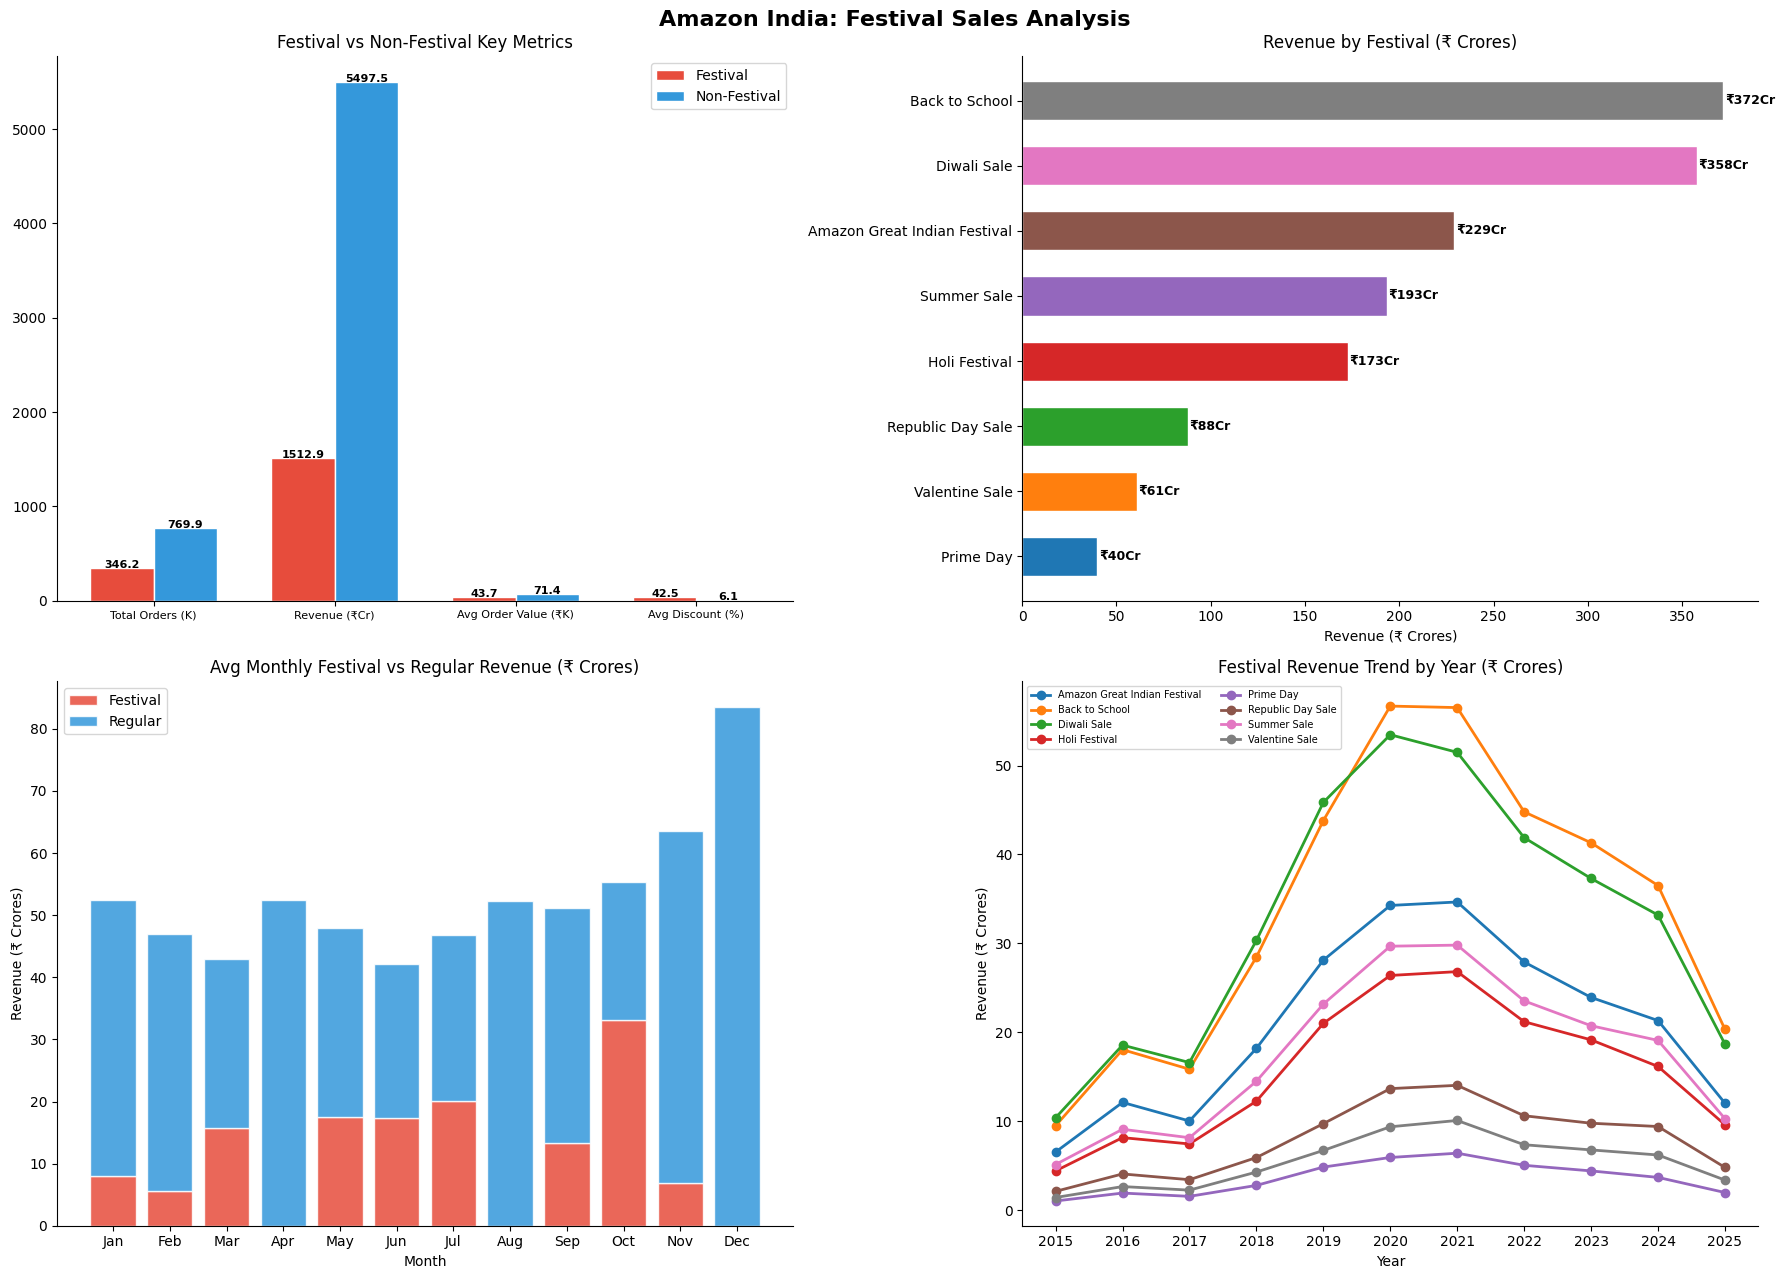

In [26]:
from sqlalchemy import text

# -- EDA Q8: Festival Sales Analysis --------------------

# -- SQL Query 1: Festival vs Non-Festival Overview -----
query_festival = text("""
    SELECT
        is_festival_sale,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount
    FROM transactions
    GROUP BY is_festival_sale
    ORDER BY is_festival_sale DESC
""")

# -- SQL Query 2: Revenue by Festival Name -------------
query_festival_name = text("""
    SELECT
        festival_name,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount
    FROM transactions
    WHERE is_festival_sale = TRUE
    GROUP BY festival_name
    ORDER BY revenue_cr DESC
""")

# -- SQL Query 3: Monthly Festival Revenue by Year -----
query_festival_monthly = text("""
    SELECT
        order_year,
        order_month,
        SUM(CASE WHEN is_festival_sale = TRUE 
            THEN final_amount_inr ELSE 0 END) / 1e7            AS festival_revenue_cr,
        SUM(CASE WHEN is_festival_sale = FALSE 
            THEN final_amount_inr ELSE 0 END) / 1e7            AS regular_revenue_cr
    FROM transactions
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""")

# -- SQL Query 4: Festival Performance by Year ---------
query_festival_yearly = text("""
    SELECT
        order_year,
        festival_name,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount
    FROM transactions
    WHERE is_festival_sale = TRUE
    GROUP BY order_year, festival_name
    ORDER BY order_year, revenue_cr DESC
""")

# -- Fetch Data -----------------------------------------
with engine.connect() as conn:
    df_festival         = pd.read_sql(query_festival, conn)
    df_festival_name    = pd.read_sql(query_festival_name, conn)
    df_festival_monthly = pd.read_sql(query_festival_monthly, conn)
    df_festival_yearly  = pd.read_sql(query_festival_yearly, conn)

print("=== Festival vs Non-Festival ===")
print(df_festival.to_string(index=False))
print("\n=== Revenue by Festival ===")
print(df_festival_name.to_string(index=False))

# -- Plotting ---------------------------------------------
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Festival Sales Analysis",
             fontsize=16, fontweight="bold")

festival_palette = sns.color_palette("tab10", len(df_festival_name))

# -- Plot 1: Festival vs Non-Festival Comparison ------------
ax1 = axes[0, 0]
metrics    = ["Total Orders (K)", "Revenue (₹Cr)", "Avg Order Value (₹K)", "Avg Discount (%)"]
fest       = df_festival[df_festival["is_festival_sale"] == True].iloc[0]
non_fest   = df_festival[df_festival["is_festival_sale"] == False].iloc[0]
fest_vals  = [fest["total_orders"]/1e3, float(fest["revenue_cr"]),
              float(fest["avg_order_value"])/1e3, float(fest["avg_discount"])]
nfest_vals = [non_fest["total_orders"]/1e3, float(non_fest["revenue_cr"]),
              float(non_fest["avg_order_value"])/1e3, float(non_fest["avg_discount"])]
x     = range(len(metrics))
width = 0.35
b1 = ax1.bar([i - width/2 for i in x], fest_vals,
             width=width, label="Festival", color="#e74c3c", edgecolor="white")
b2 = ax1.bar([i + width/2 for i in x], nfest_vals,
             width=width, label="Non-Festival", color="#3498db", edgecolor="white")
for bar in b1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")
for bar in b2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")
ax1.set_title("Festival vs Non-Festival Key Metrics", fontsize=12)
ax1.set_xticks(list(x))
ax1.set_xticklabels(metrics, fontsize=8)
ax1.legend()
sns.despine(ax=ax1)

# -- Plot 2: Revenue by Festival Name -------------------------
ax2 = axes[0, 1]
df_fn_sorted = df_festival_name.sort_values("revenue_cr", ascending=True)
bars = ax2.barh(df_fn_sorted["festival_name"], df_fn_sorted["revenue_cr"],
                color=festival_palette[:len(df_fn_sorted)],
                edgecolor="white", height=0.6)
for bar, val in zip(bars, df_fn_sorted["revenue_cr"]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"₹{val:.0f}Cr", va="center", fontsize=9, fontweight="bold")
ax2.set_title("Revenue by Festival (₹ Crores)", fontsize=12)
ax2.set_xlabel("Revenue (₹ Crores)")
sns.despine(ax=ax2)

# -- Plot 3: Monthly Festival vs Regular Revenue --------------
ax3 = axes[1, 0]
df_fm_avg = df_festival_monthly.groupby("order_month")[
    ["festival_revenue_cr", "regular_revenue_cr"]].mean()
ax3.bar(month_labels, df_fm_avg["festival_revenue_cr"],
        label="Festival", color="#e74c3c", edgecolor="white", alpha=0.85)
ax3.bar(month_labels, df_fm_avg["regular_revenue_cr"],
        bottom=df_fm_avg["festival_revenue_cr"],
        label="Regular", color="#3498db", edgecolor="white", alpha=0.85)
ax3.set_title("Avg Monthly Festival vs Regular Revenue (₹ Crores)", fontsize=12)
ax3.set_xlabel("Month")
ax3.set_ylabel("Revenue (₹ Crores)")
ax3.legend()
sns.despine(ax=ax3)

# -- Plot 4: Top Festivals by Year ----------------------------
ax4 = axes[1, 1]
fest_pivot = df_festival_yearly.pivot_table(
    index="order_year", columns="festival_name", values="revenue_cr", aggfunc="sum"
).fillna(0)
fest_colors = sns.color_palette("tab10", len(fest_pivot.columns))
for col, color in zip(fest_pivot.columns, fest_colors):
    ax4.plot(fest_pivot.index, fest_pivot[col],
             marker="o", linewidth=2, label=col, color=color)
ax4.set_title("Festival Revenue Trend by Year (₹ Crores)", fontsize=12)
ax4.set_xlabel("Year")
ax4.set_ylabel("Revenue (₹ Crores)")
ax4.legend(fontsize=7, ncol=2)
ax4.set_xticks(fest_pivot.index)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q8_festival_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Question 9
Analyze customer age group behavior and preferences. Create demographic analysis with category preferences, spending patterns, and shopping frequency across different age segments.


=== Age Group Overview ===
customer_age_group  total_orders  revenue_cr  avg_order_value  avg_discount  unique_customers  order_share
             26-35        344374     2168.22         62961.24         17.40            120261        35.06
             18-25        313130     1966.60         62804.63         17.47            108759        31.88
             36-45        197144     1236.37         62713.83         17.38             68417        20.07
             46-55         97981      615.61         62829.70         17.39             34014         9.98
               55+         29549      184.12         62310.36         17.28             10394         3.01


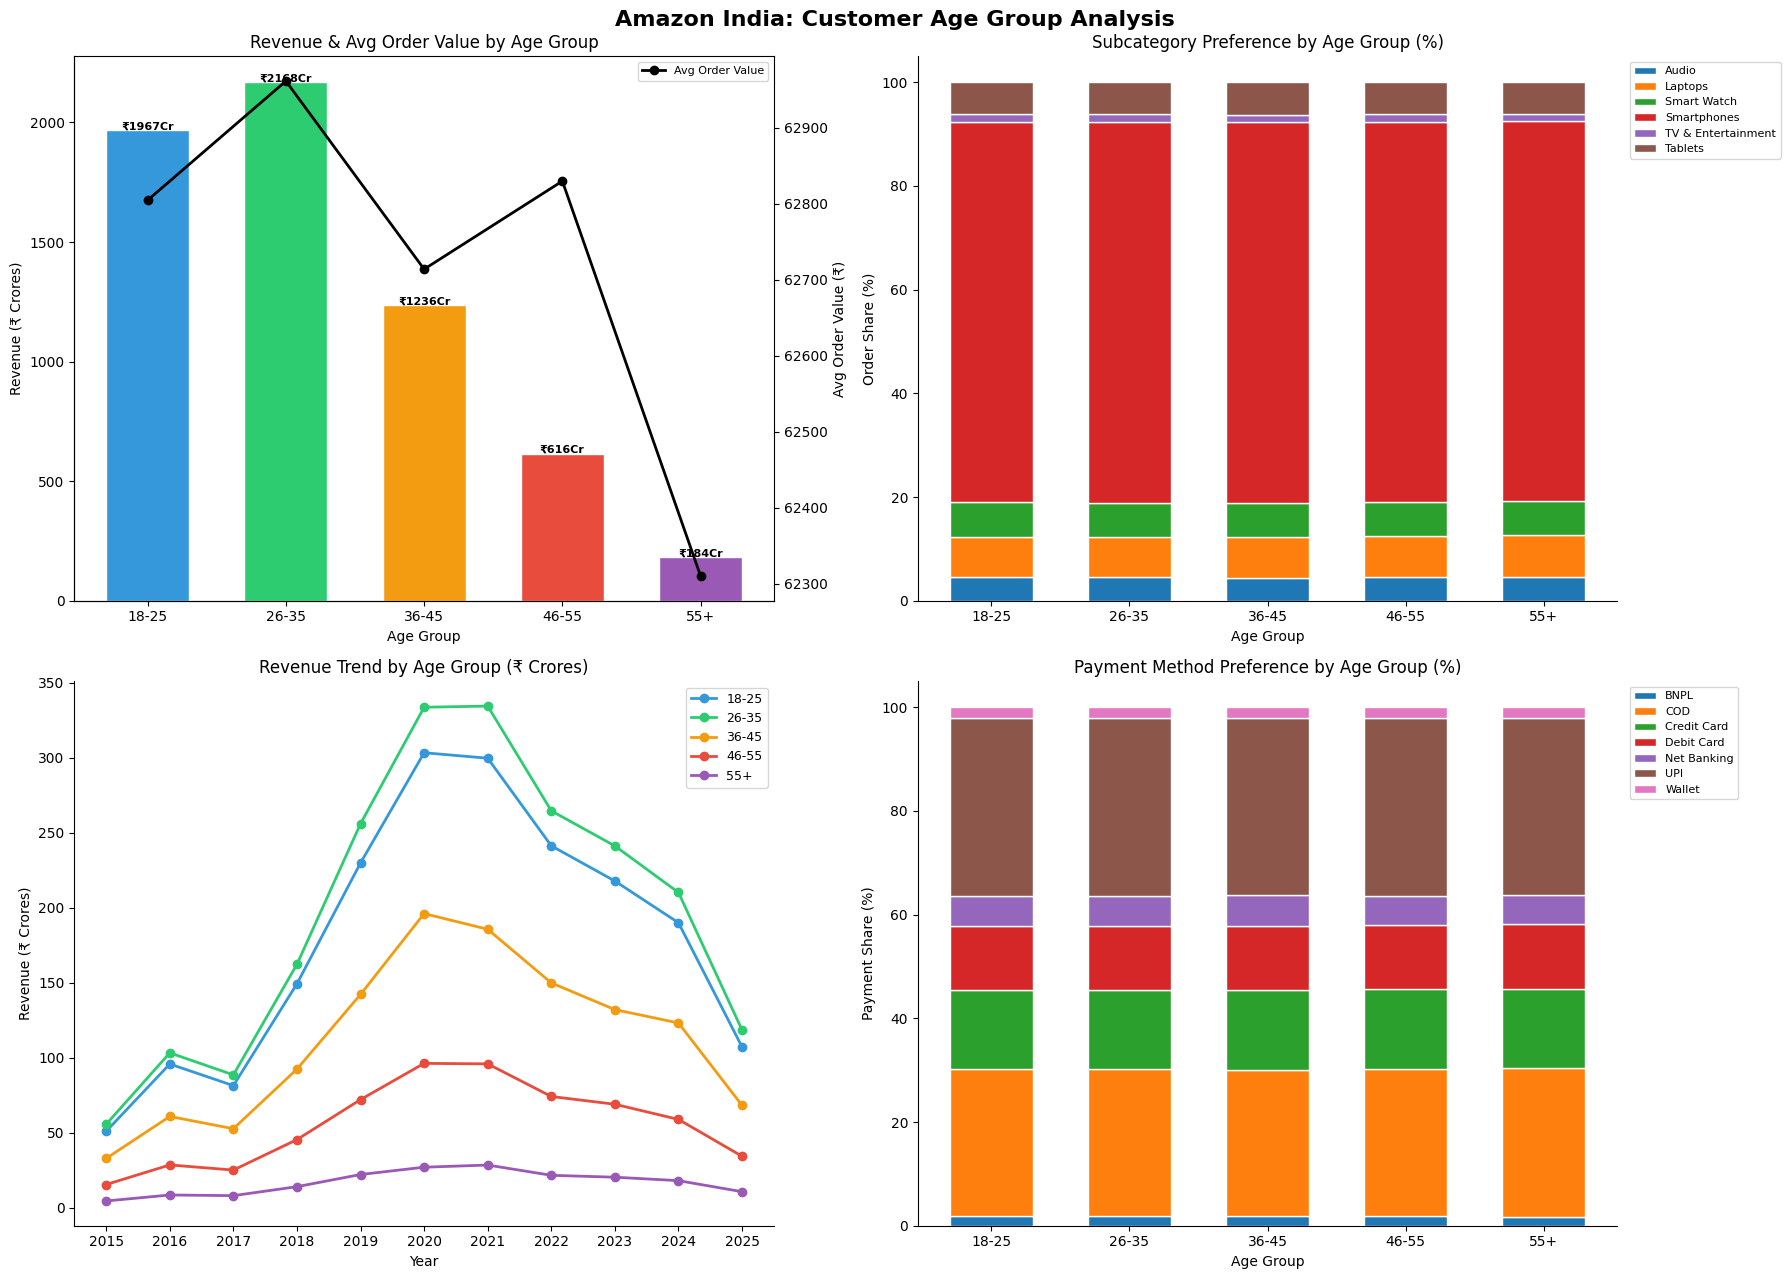

In [27]:
# -- EDA Q9: Customer Age Group Analysis ---------------

# -- SQL Query 1: Age Group Overview -------------------
query_age = text("""
    SELECT
        customer_age_group,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        COUNT(DISTINCT customer_id)                             AS unique_customers,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER ())::NUMERIC, 2)   AS order_share
    FROM transactions
    WHERE customer_age_group != 'Unknown'
    GROUP BY customer_age_group
    ORDER BY total_orders DESC
""")

# -- SQL Query 2: Age Group by Subcategory -------------
query_age_sub = text("""
    SELECT
        customer_age_group,
        subcategory,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value
    FROM transactions
    WHERE customer_age_group != 'Unknown'
    GROUP BY customer_age_group, subcategory
    ORDER BY customer_age_group, total_orders DESC
""")

# -- SQL Query 3: Age Group Revenue by Year ------------
query_age_yearly = text("""
    SELECT
        order_year,
        customer_age_group,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    WHERE customer_age_group != 'Unknown'
    GROUP BY order_year, customer_age_group
    ORDER BY order_year, revenue_cr DESC
""")

# -- SQL Query 4: Age Group Payment Preferences ----------
query_age_payment = text("""
    SELECT
        customer_age_group,
        payment_method,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER 
            (PARTITION BY customer_age_group))::NUMERIC, 2)    AS payment_share
    FROM transactions
    WHERE customer_age_group != 'Unknown'
    GROUP BY customer_age_group, payment_method
    ORDER BY customer_age_group, total_orders DESC
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_age          = pd.read_sql(query_age, conn)
    df_age_sub      = pd.read_sql(query_age_sub, conn)
    df_age_yearly   = pd.read_sql(query_age_yearly, conn)
    df_age_payment  = pd.read_sql(query_age_payment, conn)

print("=== Age Group Overview ===")
print(df_age.to_string(index=False))

# -- Age Group Order ------------------------------------
age_order  = ["18-25", "26-35", "36-45", "46-55", "55+"]
age_colors = {
    "18-25": "#3498db",
    "26-35": "#2ecc71",
    "36-45": "#f39c12",
    "46-55": "#e74c3c",
    "55+":   "#9b59b6"
}

# -- Plotting ------------------------------------------─
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Customer Age Group Analysis",
             fontsize=16, fontweight="bold")

# -- Plot 1: Revenue & Orders by Age Group ------------─
ax1 = axes[0, 0]
df_age_sorted = df_age.set_index("customer_age_group").reindex(age_order).reset_index()
bars = ax1.bar(df_age_sorted["customer_age_group"],
               df_age_sorted["revenue_cr"],
               color=[age_colors[a] for a in df_age_sorted["customer_age_group"]],
               edgecolor="white", width=0.6)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_age_sorted["customer_age_group"],
              df_age_sorted["avg_order_value"],
              color="black", marker="o", linewidth=2, label="Avg Order Value")
for bar, val in zip(bars, df_age_sorted["revenue_cr"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"₹{val:.0f}Cr", ha="center", fontsize=8, fontweight="bold")
ax1.set_title("Revenue & Avg Order Value by Age Group", fontsize=12)
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Revenue (₹ Crores)")
ax1_twin.set_ylabel("Avg Order Value (₹)")
ax1_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax1)

# -- Plot 2: Subcategory Preference by Age Group --------
ax2 = axes[0, 1]
age_sub_pivot = df_age_sub.pivot_table(
    index="customer_age_group", columns="subcategory",
    values="total_orders", aggfunc="sum"
).fillna(0)
age_sub_pivot = age_sub_pivot.div(age_sub_pivot.sum(axis=1), axis=0) * 100
age_sub_pivot = age_sub_pivot.reindex(age_order)
sub_palette = sns.color_palette("tab10", len(age_sub_pivot.columns))
bottom = pd.Series([0.0] * len(age_sub_pivot), index=age_sub_pivot.index)
for col, color in zip(age_sub_pivot.columns, sub_palette):
    ax2.bar(age_sub_pivot.index, age_sub_pivot[col],
            bottom=bottom, label=col, color=color, edgecolor="white", width=0.6)
    bottom += age_sub_pivot[col]
ax2.set_title("Subcategory Preference by Age Group (%)", fontsize=12)
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Order Share (%)")
ax2.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine(ax=ax2)

# -- Plot 3: Age Group Revenue Trend ------------------─
ax3 = axes[1, 0]
age_yearly_pivot = df_age_yearly.pivot(
    index="order_year", columns="customer_age_group", values="revenue_cr"
).fillna(0)
for col in age_order:
    if col in age_yearly_pivot.columns:
        ax3.plot(age_yearly_pivot.index, age_yearly_pivot[col],
                 marker="o", linewidth=2, label=col, color=age_colors[col])
ax3.set_title("Revenue Trend by Age Group (₹ Crores)", fontsize=12)
ax3.set_xlabel("Year")
ax3.set_ylabel("Revenue (₹ Crores)")
ax3.legend(fontsize=9)
ax3.set_xticks(age_yearly_pivot.index)
sns.despine(ax=ax3)

# -- Plot 4: Payment Method by Age Group --------------─
ax4 = axes[1, 1]
age_pay_pivot = df_age_payment.pivot_table(
    index="customer_age_group", columns="payment_method",
    values="payment_share", aggfunc="sum"
).fillna(0)
age_pay_pivot = age_pay_pivot.reindex(age_order)
pay_palette = sns.color_palette("tab10", len(age_pay_pivot.columns))
bottom2 = pd.Series([0.0] * len(age_pay_pivot), index=age_pay_pivot.index)
for col, color in zip(age_pay_pivot.columns, pay_palette):
    ax4.bar(age_pay_pivot.index, age_pay_pivot[col],
            bottom=bottom2, label=col, color=color, edgecolor="white", width=0.6)
    bottom2 += age_pay_pivot[col]
ax4.set_title("Payment Method Preference by Age Group (%)", fontsize=12)
ax4.set_xlabel("Age Group")
ax4.set_ylabel("Payment Share (%)")
ax4.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q9_age_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Question 10
Build price vs demand analysis using scatter plots and correlation matrices. Analyze how pricing strategies affect sales volumes across different categories and customer segments.


=== Price Range vs Demand ===
price_range  total_orders  avg_quantity  revenue_cr  avg_discount  avg_price
     < ₹10K         54164          1.25       17.51         17.60    2899.14
   ₹10K-25K        183524          1.25      371.79         17.47   19602.68
   ₹25K-50K        406717          1.25     1513.31         17.42   36049.31
    ₹50K-1L        253083          1.25     1878.31         17.36   71795.49
      > ₹1L        218622          1.25     3229.54         17.38  143253.11

=== Price vs Demand by Subcategory ===
       subcategory  avg_price  avg_discount  total_orders  avg_quantity  avg_rating
TV & Entertainment  107218.43         17.35         11387          1.25        4.38
           Laptops  100826.72         17.30         60922          1.25        4.37
       Smartphones   60542.17         17.42        570838          1.25        4.31
           Tablets   58611.50         17.49         48294          1.25        4.33
       Smart Watch   36270.02         17.49     

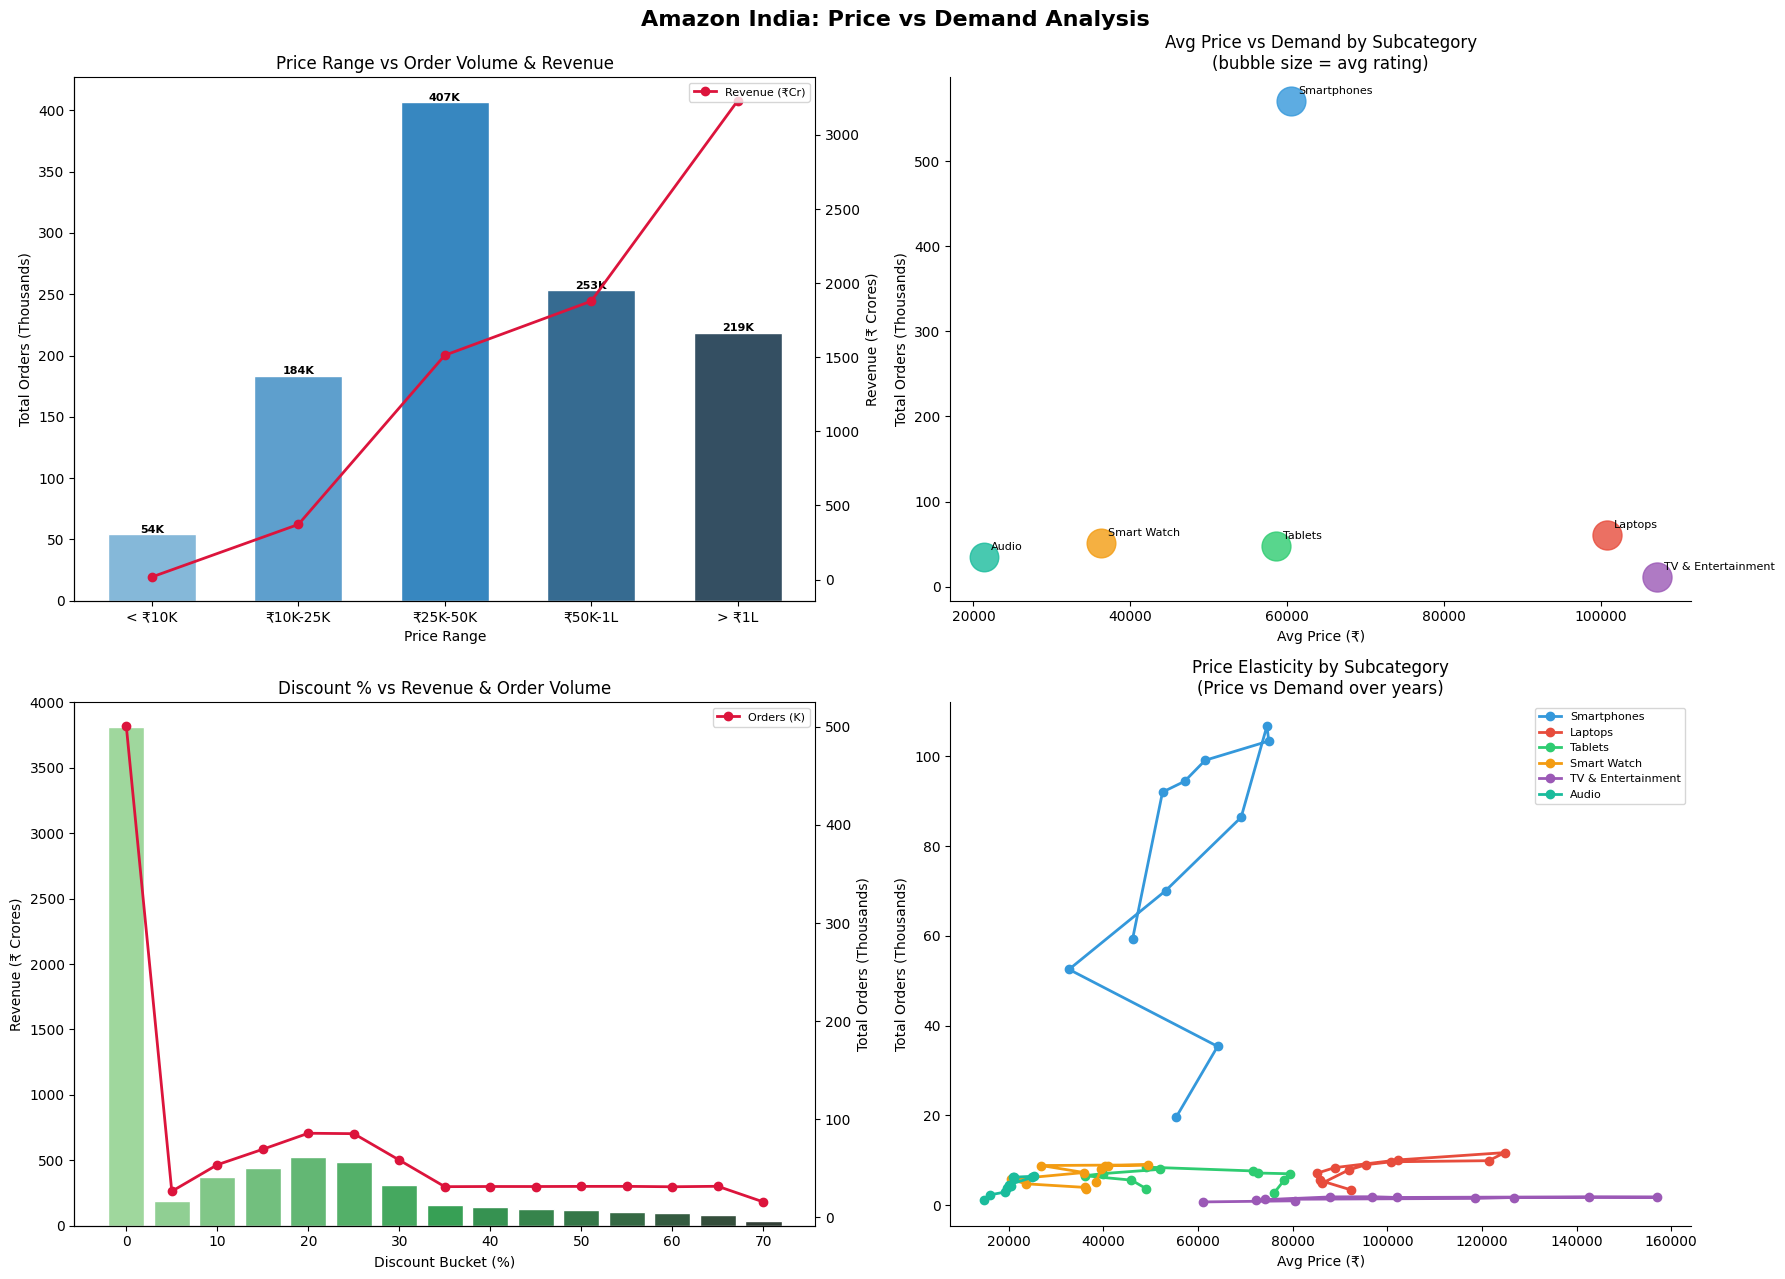

In [28]:
from sqlalchemy import text

# -- EDA Q10: Price vs Demand Analysis  ------------

# -- SQL Query 1: Price Range Buckets vs Demand --------─
query_price_demand = text("""
    SELECT
        CASE
            WHEN original_price_inr < 10000  THEN '< ₹10K'
            WHEN original_price_inr < 25000  THEN '₹10K-25K'
            WHEN original_price_inr < 50000  THEN '₹25K-50K'
            WHEN original_price_inr < 100000 THEN '₹50K-1L'
            ELSE '> ₹1L'
        END                                                     AS price_range,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND(AVG(quantity)::NUMERIC, 2)                        AS avg_quantity,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        ROUND(AVG(original_price_inr)::NUMERIC, 2)             AS avg_price
    FROM transactions
    GROUP BY price_range
    ORDER BY avg_price
""")

# -- SQL Query 2: Price vs Demand by Subcategory --------
query_price_sub = text("""
    SELECT
        subcategory,
        ROUND(AVG(original_price_inr)::NUMERIC, 2)             AS avg_price,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND(AVG(quantity)::NUMERIC, 2)                        AS avg_quantity,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating
    FROM transactions
    WHERE customer_rating IS NOT NULL
    GROUP BY subcategory
    ORDER BY avg_price DESC
""")

# -- SQL Query 3: Discount vs Revenue Correlation ------
query_discount = text("""
    SELECT
        ROUND(discount_percent / 5) * 5                        AS discount_bucket,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    GROUP BY discount_bucket
    ORDER BY discount_bucket
""")

# -- SQL Query 4: Price Elasticity by Subcategory ------
query_elasticity = text("""
    SELECT
        subcategory,
        order_year,
        ROUND(AVG(original_price_inr)::NUMERIC, 2)             AS avg_price,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    GROUP BY subcategory, order_year
    ORDER BY subcategory, order_year
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_price_demand = pd.read_sql(query_price_demand, conn)
    df_price_sub    = pd.read_sql(query_price_sub, conn)
    df_discount     = pd.read_sql(query_discount, conn)
    df_elasticity   = pd.read_sql(query_elasticity, conn)

print("=== Price Range vs Demand ===")
print(df_price_demand.to_string(index=False))
print("\n=== Price vs Demand by Subcategory ===")
print(df_price_sub.to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Price vs Demand Analysis",
             fontsize=16, fontweight="bold")

sub_colors = {
    "Smartphones":        "#3498db",
    "Laptops":            "#e74c3c",
    "Tablets":            "#2ecc71",
    "Smart Watch":        "#f39c12",
    "TV & Entertainment": "#9b59b6",
    "Audio":              "#1abc9c"
}

# -- Plot 1: Price Range vs Orders --------------------
ax1 = axes[0, 0]
bars = ax1.bar(df_price_demand["price_range"],
               df_price_demand["total_orders"] / 1e3,
               color=sns.color_palette("Blues_d", len(df_price_demand)),
               edgecolor="white", width=0.6)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_price_demand["price_range"],
              df_price_demand["revenue_cr"],
              color="crimson", marker="o", linewidth=2, label="Revenue (₹Cr)")
for bar, val in zip(bars, df_price_demand["total_orders"] / 1e3):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}K", ha="center", fontsize=8, fontweight="bold")
ax1.set_title("Price Range vs Order Volume & Revenue", fontsize=12)
ax1.set_xlabel("Price Range")
ax1.set_ylabel("Total Orders (Thousands)")
ax1_twin.set_ylabel("Revenue (₹ Crores)")
ax1_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax1)

# -- Plot 2: Subcategory Price vs Demand Scatter --------
ax2 = axes[0, 1]
for _, row in df_price_sub.iterrows():
    ax2.scatter(row["avg_price"], row["total_orders"] / 1e3,
                s=row["avg_rating"] * 100,
                color=sub_colors.get(row["subcategory"], "#95a5a6"),
                alpha=0.8, label=row["subcategory"])
    ax2.annotate(row["subcategory"],
                 (row["avg_price"], row["total_orders"] / 1e3),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax2.set_title("Avg Price vs Demand by Subcategory\n(bubble size = avg rating)", fontsize=12)
ax2.set_xlabel("Avg Price (₹)")
ax2.set_ylabel("Total Orders (Thousands)")
sns.despine(ax=ax2)

# -- Plot 3: Discount Bucket vs Revenue ----------------
ax3 = axes[1, 0]
bars3 = ax3.bar(df_discount["discount_bucket"],
                df_discount["revenue_cr"],
                color=sns.color_palette("Greens_d", len(df_discount)),
                edgecolor="white", width=4)
ax3_twin = ax3.twinx()
ax3_twin.plot(df_discount["discount_bucket"],
              df_discount["total_orders"] / 1e3,
              color="crimson", marker="o", linewidth=2, label="Orders (K)")
ax3.set_title("Discount % vs Revenue & Order Volume", fontsize=12)
ax3.set_xlabel("Discount Bucket (%)")
ax3.set_ylabel("Revenue (₹ Crores)")
ax3_twin.set_ylabel("Total Orders (Thousands)")
ax3_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax3)

# -- Plot 4: Price Elasticity by Subcategory ------------
ax4 = axes[1, 1]
for sub, color in sub_colors.items():
    data = df_elasticity[df_elasticity["subcategory"] == sub]
    ax4.plot(data["avg_price"], data["total_orders"] / 1e3,
             marker="o", linewidth=2, label=sub, color=color)
ax4.set_title("Price Elasticity by Subcategory\n(Price vs Demand over years)", fontsize=12)
ax4.set_xlabel("Avg Price (₹)")
ax4.set_ylabel("Total Orders (Thousands)")
ax4.legend(fontsize=8)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q10_price_demand.png", dpi=150, bbox_inches="tight")
plt.show()

Question 11
Create delivery performance analysis showing delivery days distribution, on-time performance, and customer satisfaction correlation with delivery speed across different cities and customer tiers.


=== Delivery Type Overview ===
delivery_type  total_orders  avg_delivery_days  min_days  max_days  order_share
     Same Day        213998               1.03       0.0      15.0        19.17
      Express        128374               2.01       0.0      15.0        11.50
     Standard        773738               4.17       0.0      15.0        69.32

=== Delivery vs Rating ===
 delivery_day  avg_rating  total_orders
            0        4.32          4599
            1        4.35        150744
            2        4.36         88048
            3        4.31        201868
            4        4.28        143068
            5        4.28         94101
            6        4.28         70641
            7        4.28         23370
           15        4.32          1489


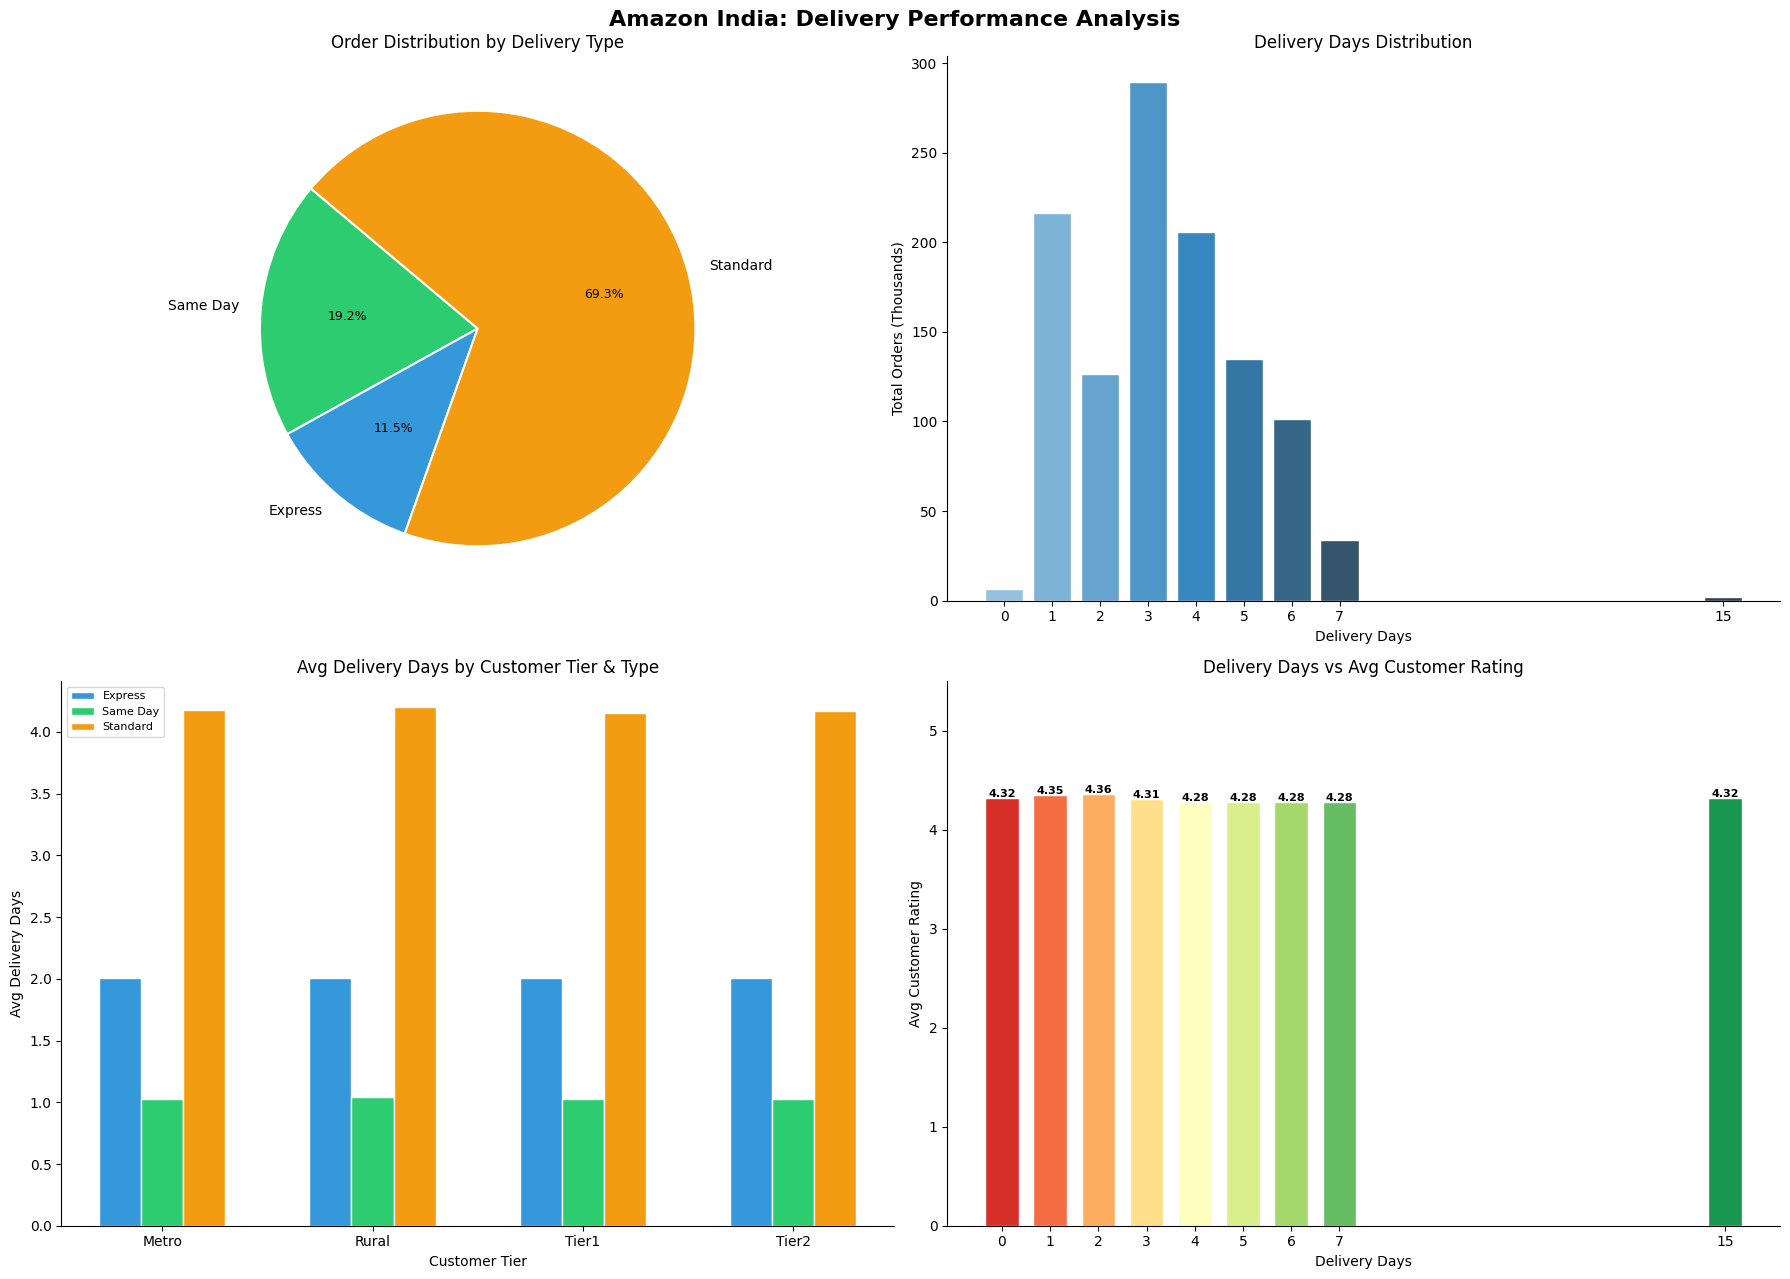

In [29]:
from sqlalchemy import text
# -- EDA Q11: Delivery Performance Analysis  ------

# -- SQL Query 1: Overall Delivery Stats --------------
query_delivery = text("""
    SELECT
        delivery_type,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND(AVG(delivery_days)::NUMERIC, 2)                  AS avg_delivery_days,
        ROUND(MIN(delivery_days)::NUMERIC, 2)                  AS min_days,
        ROUND(MAX(delivery_days)::NUMERIC, 2)                  AS max_days,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER ())::NUMERIC, 2)   AS order_share
    FROM transactions
    GROUP BY delivery_type
    ORDER BY avg_delivery_days
""")

# -- SQL Query 2: Delivery Days Distribution ----------
query_delivery_dist = text("""
    SELECT
        delivery_days,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    WHERE delivery_days IS NOT NULL
      AND delivery_days BETWEEN 0 AND 15
    GROUP BY delivery_days
    ORDER BY delivery_days
""")

# -- SQL Query 3: Delivery by Customer Tier ------------
query_delivery_tier = text("""
    SELECT
        customer_tier,
        delivery_type,
        ROUND(AVG(delivery_days)::NUMERIC, 2)                  AS avg_delivery_days,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    GROUP BY customer_tier, delivery_type
    ORDER BY customer_tier, avg_delivery_days
""")

# -- SQL Query 4: Delivery vs Customer Rating ----------
query_delivery_rating = text("""
    SELECT
        ROUND(delivery_days)::INT                              AS delivery_day,
        ROUND(AVG(customer_rating)::NUMERIC, 2)               AS avg_rating,
        COUNT(transaction_id)                                  AS total_orders
    FROM transactions
    WHERE customer_rating IS NOT NULL
      AND delivery_days BETWEEN 0 AND 15
    GROUP BY ROUND(delivery_days)::INT
    ORDER BY delivery_day
""")

# -- SQL Query 5: Delivery Performance by State --------
query_delivery_state = text("""
    SELECT
        customer_state,
        ROUND(AVG(delivery_days)::NUMERIC, 2)                  AS avg_delivery_days,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    GROUP BY customer_state
    ORDER BY avg_delivery_days
    LIMIT 10
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_delivery         = pd.read_sql(query_delivery, conn)
    df_delivery_dist    = pd.read_sql(query_delivery_dist, conn)
    df_delivery_tier    = pd.read_sql(query_delivery_tier, conn)
    df_delivery_rating  = pd.read_sql(query_delivery_rating, conn)
    df_delivery_state   = pd.read_sql(query_delivery_state, conn)

print("=== Delivery Type Overview ===")
print(df_delivery.to_string(index=False))
print("\n=== Delivery vs Rating ===")
print(df_delivery_rating.to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Delivery Performance Analysis",
             fontsize=16, fontweight="bold")

delivery_colors = {
    "Same Day":     "#2ecc71",
    "Express":      "#3498db",
    "Standard":     "#f39c12",
    "Economy":      "#e74c3c"
}
tier_colors = {
    "Metro":  "#2ecc71",
    "Tier1":  "#3498db",
    "Tier2":  "#f39c12",
    "Rural":  "#e74c3c"
}

# -- Plot 1: Delivery Type Distribution ----------------
ax1 = axes[0, 0]
wedges, texts, autotexts = ax1.pie(
    df_delivery["total_orders"],
    labels=df_delivery["delivery_type"],
    colors=[delivery_colors.get(t, "#95a5a6") for t in df_delivery["delivery_type"]],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in autotexts:
    text.set_fontsize(9)
ax1.set_title("Order Distribution by Delivery Type", fontsize=12)

# -- Plot 2: Delivery Days Distribution ----------------
ax2 = axes[0, 1]
bars = ax2.bar(df_delivery_dist["delivery_days"],
               df_delivery_dist["total_orders"] / 1e3,
               color=sns.color_palette("Blues_d", len(df_delivery_dist)),
               edgecolor="white", width=0.8)
ax2.set_title("Delivery Days Distribution", fontsize=12)
ax2.set_xlabel("Delivery Days")
ax2.set_ylabel("Total Orders (Thousands)")
ax2.set_xticks(df_delivery_dist["delivery_days"])
sns.despine(ax=ax2)

# -- Plot 3: Avg Delivery Days by Tier & Type ----------
ax3 = axes[1, 0]
tier_delivery_pivot = df_delivery_tier.pivot(
    index="customer_tier", columns="delivery_type", values="avg_delivery_days"
).fillna(0)
x3    = range(len(tier_delivery_pivot))
width = 0.2
for i, col in enumerate(tier_delivery_pivot.columns):
    ax3.bar([j + i * width for j in x3],
            tier_delivery_pivot[col],
            width=width, label=col,
            color=delivery_colors.get(col, "#95a5a6"),
            edgecolor="white")
ax3.set_title("Avg Delivery Days by Customer Tier & Type", fontsize=12)
ax3.set_xlabel("Customer Tier")
ax3.set_ylabel("Avg Delivery Days")
ax3.set_xticks([j + width for j in x3])
ax3.set_xticklabels(tier_delivery_pivot.index)
ax3.legend(fontsize=8)
sns.despine(ax=ax3)

# -- Plot 4: Delivery Days vs Customer Rating ----------
ax4 = axes[1, 1]
bars4 = ax4.bar(df_delivery_rating["delivery_day"],
                df_delivery_rating["avg_rating"],
                color=sns.color_palette("RdYlGn", len(df_delivery_rating)),
                edgecolor="white", width=0.7)
for bar, val in zip(bars4, df_delivery_rating["avg_rating"]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha="center", fontsize=8, fontweight="bold")
ax4.set_title("Delivery Days vs Avg Customer Rating", fontsize=12)
ax4.set_xlabel("Delivery Days")
ax4.set_ylabel("Avg Customer Rating")
ax4.set_ylim(0, 5.5)
ax4.set_xticks(df_delivery_rating["delivery_day"])
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q11_delivery_performance.png", dpi=150, bbox_inches="tight")
plt.show()

Question 12
Analyze return patterns and customer satisfaction using return rates, reasons, and correlation with product ratings, prices, and categories through multiple visualization techniques.


=== Return Overview ===
return_status  total_orders  revenue_cr  avg_order_value  avg_rating  order_share
    Delivered       1011969     6406.20         63304.34        4.31        90.67
     Returned         78362      453.74         57903.18        4.29         7.02
    Cancelled         25779      150.51         58383.22        4.29         2.31

=== Return Rate by Subcategory ===
       subcategory  total_orders  returned_orders  return_rate
             Audio         50152             4007         7.99
       Smart Watch         73942             5452         7.37
           Tablets         69343             4847         6.99
       Smartphones        819050            57079         6.97
           Laptops         87325             6025         6.90
TV & Entertainment         16298              952         5.84


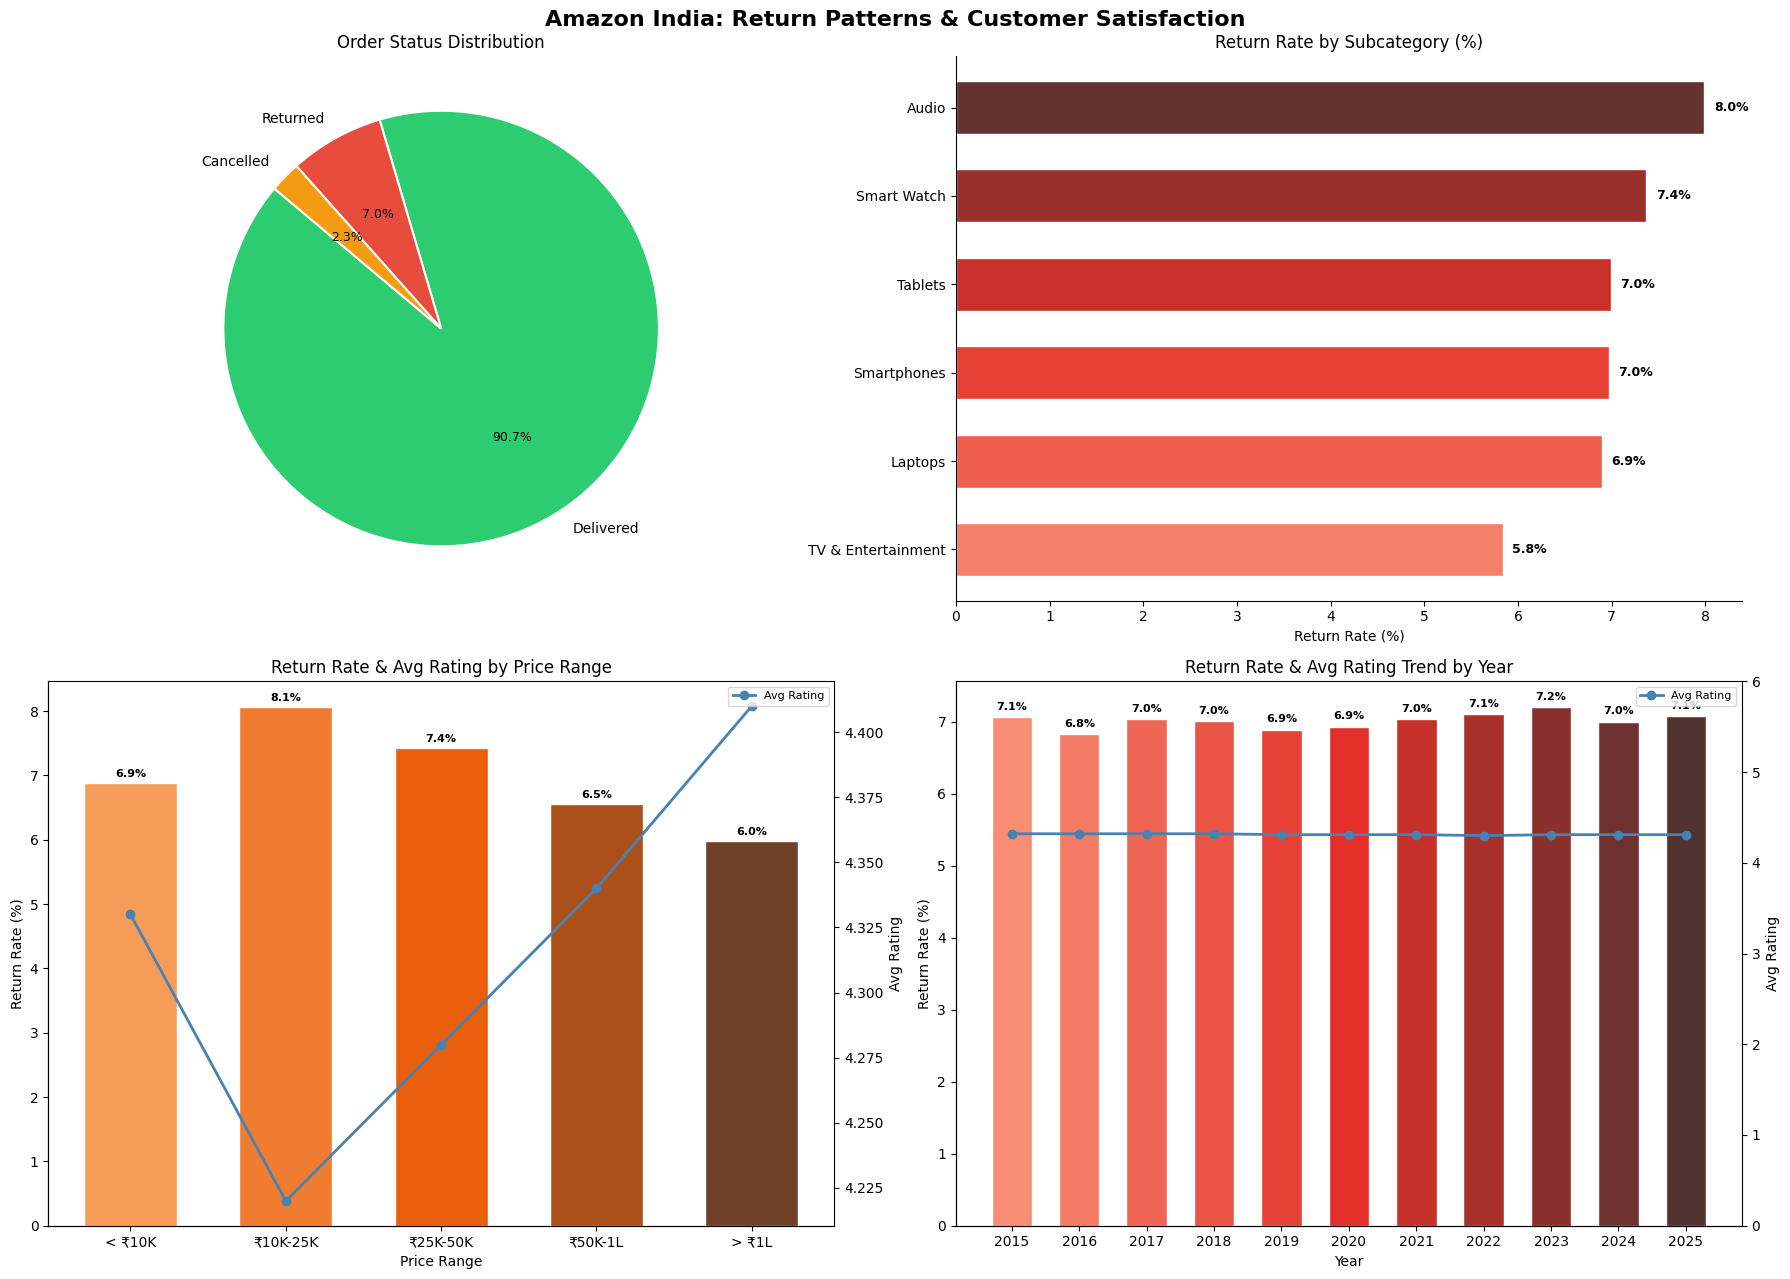

In [30]:
from sqlalchemy import text
# -- EDA Q12: Return Patterns Analysis  ------------

# -- SQL Query 1: Overall Return Overview --------------
query_return = text("""
    SELECT
        return_status,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER ())::NUMERIC, 2)   AS order_share
    FROM transactions
    GROUP BY return_status
    ORDER BY total_orders DESC
""")

# -- SQL Query 2: Return Rate by Subcategory ------------
query_return_sub = text("""
    SELECT
        subcategory,
        COUNT(transaction_id)                                   AS total_orders,
        SUM(CASE WHEN return_status = 'Returned' 
            THEN 1 ELSE 0 END)                                  AS returned_orders,
        ROUND((SUM(CASE WHEN return_status = 'Returned'
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                 AS return_rate
    FROM transactions
    GROUP BY subcategory
    ORDER BY return_rate DESC
""")

# -- SQL Query 3: Return Rate by Price Range ------------
query_return_price = text("""
    SELECT
        CASE
            WHEN original_price_inr < 10000  THEN '< ₹10K'
            WHEN original_price_inr < 25000  THEN '₹10K-25K'
            WHEN original_price_inr < 50000  THEN '₹25K-50K'
            WHEN original_price_inr < 100000 THEN '₹50K-1L'
            ELSE '> ₹1L'
        END                                                     AS price_range,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(CASE WHEN return_status = 'Returned'
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                 AS return_rate,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating
    FROM transactions
    GROUP BY price_range
    ORDER BY return_rate DESC
""")

# -- SQL Query 4: Return Rate by Year ------------------
query_return_yearly = text("""
    SELECT
        order_year,
        COUNT(transaction_id)                                   AS total_orders,
        SUM(CASE WHEN return_status = 'Returned'
            THEN 1 ELSE 0 END)                                  AS returned_orders,
        ROUND((SUM(CASE WHEN return_status = 'Returned'
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                 AS return_rate,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating
    FROM transactions
    GROUP BY order_year
    ORDER BY order_year
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_return         = pd.read_sql(query_return, conn)
    df_return_sub     = pd.read_sql(query_return_sub, conn)
    df_return_price   = pd.read_sql(query_return_price, conn)
    df_return_yearly  = pd.read_sql(query_return_yearly, conn)

print("=== Return Overview ===")
print(df_return.to_string(index=False))
print("\n=== Return Rate by Subcategory ===")
print(df_return_sub.to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Return Patterns & Customer Satisfaction",
             fontsize=16, fontweight="bold")

# -- Plot 1: Return Status Distribution ----------------
ax1 = axes[0, 0]
colors_return = {"Delivered": "#2ecc71", "Returned": "#e74c3c", "Cancelled": "#f39c12"}
wedges, texts, autotexts = ax1.pie(
    df_return["total_orders"],
    labels=df_return["return_status"],
    colors=[colors_return.get(s, "#95a5a6") for s in df_return["return_status"]],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in autotexts:
    text.set_fontsize(9)
ax1.set_title("Order Status Distribution", fontsize=12)

# -- Plot 2: Return Rate by Subcategory ----------------
ax2 = axes[0, 1]
df_rs_sorted = df_return_sub.sort_values("return_rate", ascending=True)
bars = ax2.barh(df_rs_sorted["subcategory"], df_rs_sorted["return_rate"],
                color=sns.color_palette("Reds_d", len(df_rs_sorted)),
                edgecolor="white", height=0.6)
for bar, val in zip(bars, df_rs_sorted["return_rate"]):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax2.set_title("Return Rate by Subcategory (%)", fontsize=12)
ax2.set_xlabel("Return Rate (%)")
sns.despine(ax=ax2)

# -- Plot 3: Return Rate by Price Range ----------------
ax3 = axes[1, 0]
price_order = ["< ₹10K", "₹10K-25K", "₹25K-50K", "₹50K-1L", "> ₹1L"]
df_rp = df_return_price.set_index("price_range").reindex(price_order).reset_index()
bars3 = ax3.bar(df_rp["price_range"], df_rp["return_rate"],
                color=sns.color_palette("Oranges_d", len(df_rp)),
                edgecolor="white", width=0.6)
ax3_twin = ax3.twinx()
ax3_twin.plot(df_rp["price_range"], df_rp["avg_rating"],
              color="steelblue", marker="o", linewidth=2, label="Avg Rating")
for bar, val in zip(bars3, df_rp["return_rate"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax3.set_title("Return Rate & Avg Rating by Price Range", fontsize=12)
ax3.set_xlabel("Price Range")
ax3.set_ylabel("Return Rate (%)")
ax3_twin.set_ylabel("Avg Rating")
ax3_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax3)

# -- Plot 4: Return Rate Trend by Year ----------------─
ax4 = axes[1, 1]
bars4 = ax4.bar(df_return_yearly["order_year"],
                df_return_yearly["return_rate"],
                color=sns.color_palette("Reds_d", len(df_return_yearly)),
                edgecolor="white", width=0.6)
ax4_twin = ax4.twinx()
ax4_twin.plot(df_return_yearly["order_year"],
              df_return_yearly["avg_rating"],
              color="steelblue", marker="o", linewidth=2, label="Avg Rating")
for bar, val in zip(bars4, df_return_yearly["return_rate"]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax4.set_title("Return Rate & Avg Rating Trend by Year", fontsize=12)
ax4.set_xlabel("Year")
ax4.set_ylabel("Return Rate (%)")
ax4_twin.set_ylabel("Avg Rating")
ax4_twin.set_ylim(0, 6)
ax4_twin.legend(loc="upper right", fontsize=8)
ax4.set_xticks(df_return_yearly["order_year"])
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q12_return_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Question 13
Study brand performance and market share evolution. Create brand comparison charts, market share trends, and competitive positioning analysis across different categories.


=== Top 15 Brands by Revenue ===
    brand  total_orders  revenue_cr  avg_order_value  avg_discount  avg_rating  market_share
  Samsung        220230     1859.23         84422.31         17.42        3.97         19.73
    Apple        110572     1328.03        120105.18         17.41        3.99          9.91
  OnePlus        172662     1186.35         68709.29         17.47        4.02         15.47
   Xiaomi        154422      534.09         34586.61         17.37        3.97         13.84
   Realme         84273      284.57         33767.11         17.32        3.96          7.55
     Vivo         70556      233.30         33066.04         17.25        3.98          6.32
     Oppo         70560      225.88         32011.79         17.53        3.97          6.32
   Lenovo         22458      181.94         81012.60         17.64        3.98          2.01
Alienware         14490      159.16        109843.15         17.30        4.15          1.30
     ASUS         12882      138.69  

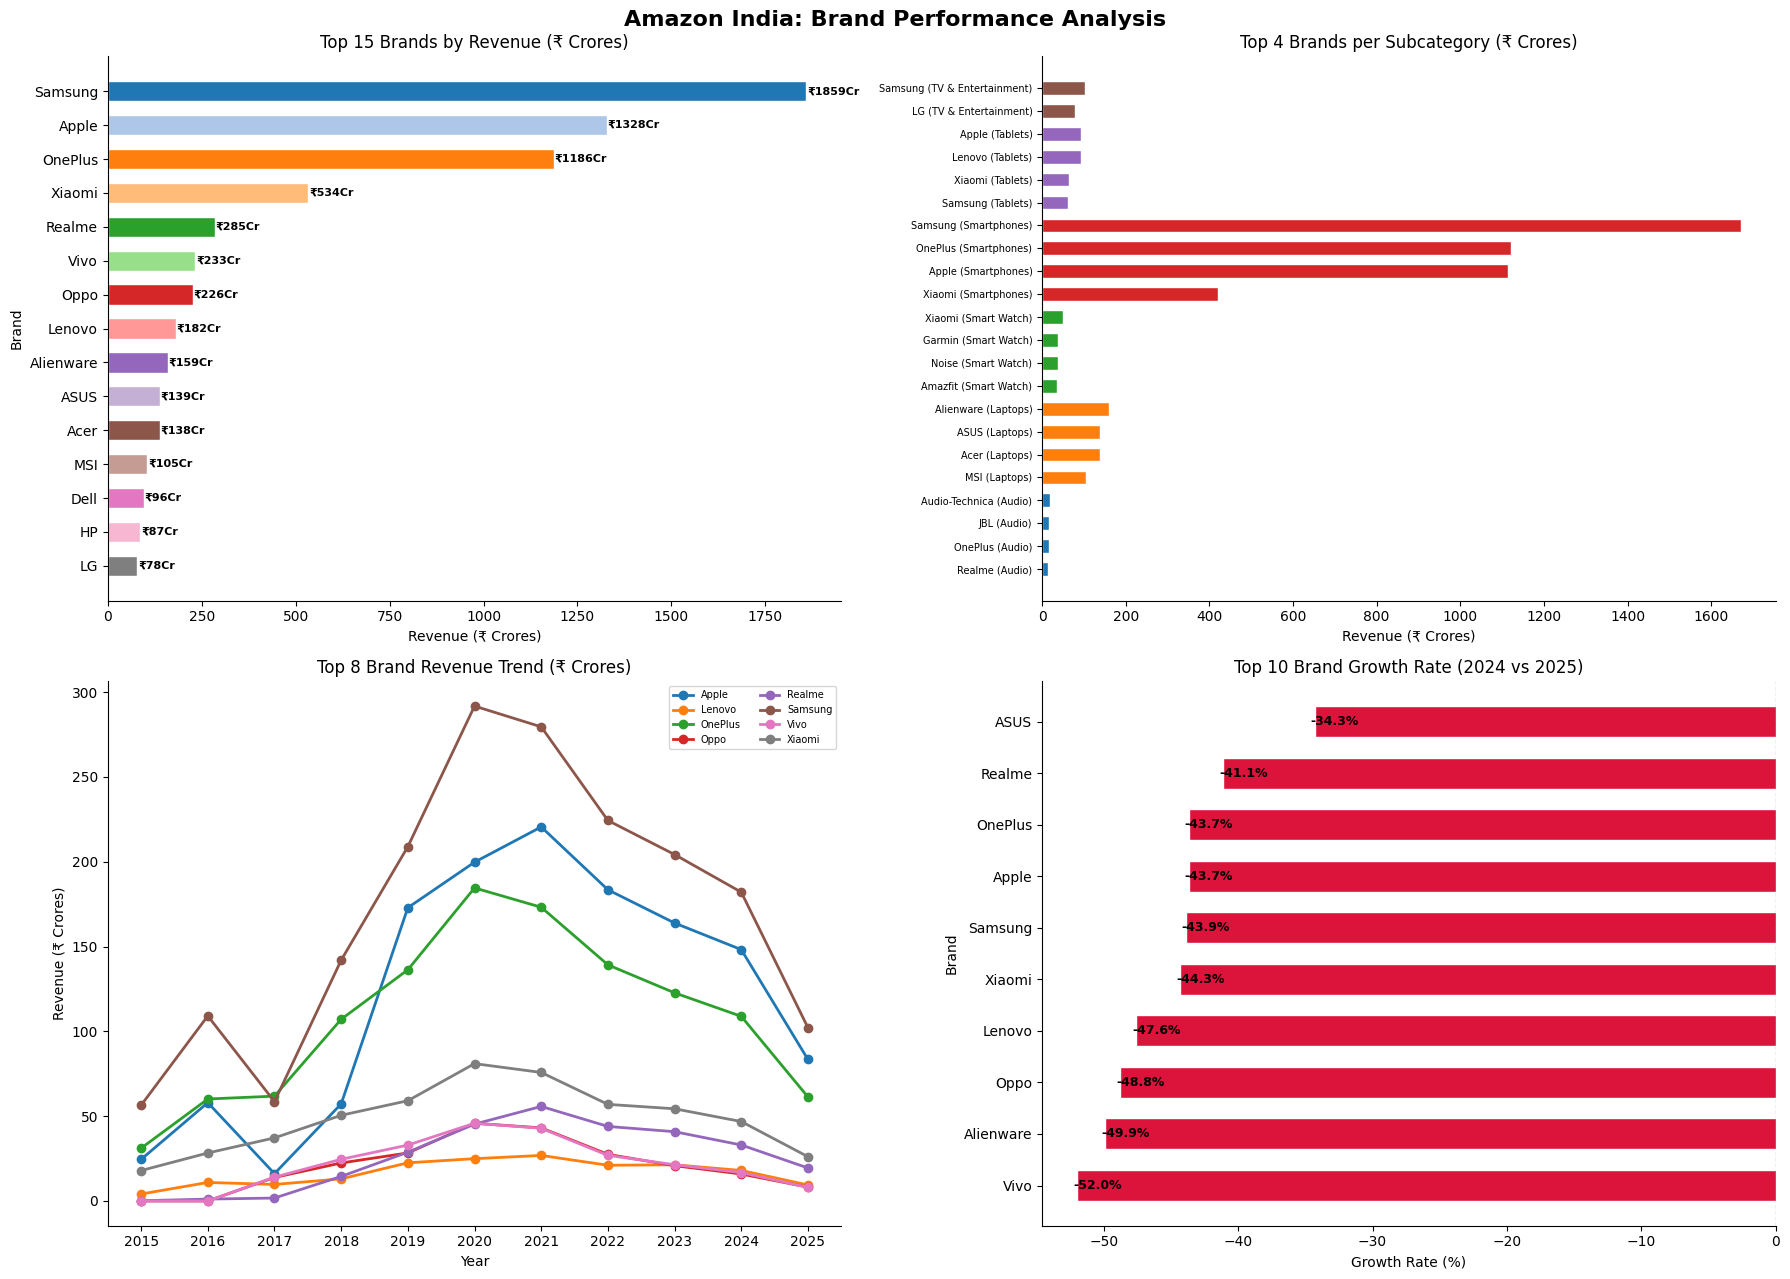

In [31]:
from sqlalchemy import text 
# -- EDA Q13: Brand Performance Analysis  ----------

# -- SQL Query 1: Top Brands by Revenue ----------------
query_brand = text("""
    SELECT
        brand,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        ROUND(AVG(product_rating)::NUMERIC, 2)                 AS avg_rating,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER ())::NUMERIC, 2)   AS market_share
    FROM transactions
    GROUP BY brand
    ORDER BY revenue_cr DESC
    LIMIT 15
""")

# -- SQL Query 2: Brand Market Share by Subcategory ----
query_brand_sub = text("""
    SELECT
        subcategory,
        brand,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    GROUP BY subcategory, brand
    ORDER BY subcategory, revenue_cr DESC
""")

# -- SQL Query 3: Top Brand Revenue Trend --------------
query_brand_yearly = text("""
    SELECT
        order_year,
        brand,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    WHERE brand IN (
        SELECT brand FROM transactions
        GROUP BY brand
        ORDER BY SUM(final_amount_inr) DESC
        LIMIT 8
    )
    GROUP BY order_year, brand
    ORDER BY order_year, revenue_cr DESC
""")

# -- SQL Query 4: Brand Growth (2024 vs 2025) ----------
query_brand_growth = text("""
    SELECT
        brand,
        SUM(CASE WHEN order_year = 2024
            THEN final_amount_inr ELSE 0 END) / 1e7            AS rev_2024,
        SUM(CASE WHEN order_year = 2025
            THEN final_amount_inr ELSE 0 END) / 1e7            AS rev_2025,
        ROUND(((SUM(CASE WHEN order_year = 2025 THEN final_amount_inr ELSE 0 END) -
                SUM(CASE WHEN order_year = 2024 THEN final_amount_inr ELSE 0 END)) /
                NULLIF(SUM(CASE WHEN order_year = 2024
                THEN final_amount_inr ELSE 0 END), 0) * 100)::NUMERIC, 1) AS growth_pct
    FROM transactions
    WHERE brand IN (
        SELECT brand FROM transactions
        GROUP BY brand
        ORDER BY SUM(final_amount_inr) DESC
        LIMIT 10
    )
    GROUP BY brand
    ORDER BY growth_pct DESC
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_brand        = pd.read_sql(query_brand, conn)
    df_brand_sub    = pd.read_sql(query_brand_sub, conn)
    df_brand_yearly = pd.read_sql(query_brand_yearly, conn)
    df_brand_growth = pd.read_sql(query_brand_growth, conn)

print("=== Top 15 Brands by Revenue ===")
print(df_brand.to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Brand Performance Analysis",
             fontsize=16, fontweight="bold")

brand_palette = sns.color_palette("tab20", len(df_brand))
brand_colors  = {b: brand_palette[i] for i, b in enumerate(df_brand["brand"])}

# -- Plot 1: Top 15 Brands Revenue --------------------
ax1 = axes[0, 0]
df_brand_sorted = df_brand.sort_values("revenue_cr", ascending=True)
bars = ax1.barh(df_brand_sorted["brand"], df_brand_sorted["revenue_cr"],
                color=[brand_colors[b] for b in df_brand_sorted["brand"]],
                edgecolor="white", height=0.6)
for bar, val in zip(bars, df_brand_sorted["revenue_cr"]):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f"₹{val:.0f}Cr", va="center", fontsize=8, fontweight="bold")
ax1.set_title("Top 15 Brands by Revenue (₹ Crores)", fontsize=12)
ax1.set_xlabel("Revenue (₹ Crores)")
ax1.set_ylabel("Brand")
sns.despine(ax=ax1)

# -- Plot 2: Top Brand per Subcategory ----------------
ax2 = axes[0, 1]
top_brand_sub = df_brand_sub.groupby("subcategory").head(4)
sub_list      = top_brand_sub["subcategory"].unique()
sub_palette   = sns.color_palette("tab10", len(sub_list))
sub_color_map = {s: sub_palette[i] for i, s in enumerate(sub_list)}
for sub in sub_list:
    data = top_brand_sub[top_brand_sub["subcategory"] == sub].sort_values(
        "revenue_cr", ascending=True)
    ax2.barh(data["brand"] + f" ({sub})", data["revenue_cr"],
             color=sub_color_map[sub], edgecolor="white", height=0.6)
ax2.set_title("Top 4 Brands per Subcategory (₹ Crores)", fontsize=12)
ax2.set_xlabel("Revenue (₹ Crores)")
ax2.tick_params(axis="y", labelsize=7)
sns.despine(ax=ax2)

# -- Plot 3: Top Brand Revenue Trend -----------------
ax3 = axes[1, 0]
brand_yearly_pivot = df_brand_yearly.pivot(
    index="order_year", columns="brand", values="revenue_cr"
).fillna(0)
trend_palette = sns.color_palette("tab10", len(brand_yearly_pivot.columns))
for col, color in zip(brand_yearly_pivot.columns, trend_palette):
    ax3.plot(brand_yearly_pivot.index, brand_yearly_pivot[col],
             marker="o", linewidth=2, label=col, color=color)
ax3.set_title("Top 8 Brand Revenue Trend (₹ Crores)", fontsize=12)
ax3.set_xlabel("Year")
ax3.set_ylabel("Revenue (₹ Crores)")
ax3.legend(fontsize=7, ncol=2)
ax3.set_xticks(brand_yearly_pivot.index)
sns.despine(ax=ax3)

# -- Plot 4: Brand Growth Rate 2024 vs 2025 ------------
ax4 = axes[1, 1]
df_bg_sorted  = df_brand_growth.sort_values("growth_pct", ascending=True)
colors_growth = ["seagreen" if x >= 0 else "crimson"
                 for x in df_bg_sorted["growth_pct"]]
bars4 = ax4.barh(df_bg_sorted["brand"], df_bg_sorted["growth_pct"],
                 color=colors_growth, edgecolor="white", height=0.6)
for bar, val in zip(bars4, df_bg_sorted["growth_pct"]):
    ax4.text(bar.get_width() + 0.3 if val >= 0 else bar.get_width() - 0.3,
             bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax4.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax4.set_title("Top 10 Brand Growth Rate (2024 vs 2025)", fontsize=12)
ax4.set_xlabel("Growth Rate (%)")
ax4.set_ylabel("Brand")
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q13_brand_performance.png", dpi=150, bbox_inches="tight")
plt.show()

Question 14
Build customer lifetime value (CLV) analysis using cohort analysis, retention curves, and CLV distribution across different customer segments and acquisition years.


=== CLV Segment Overview ===
clv_segment  total_customers   avg_clv  total_revenue_cr  customer_share
 High Value             8106 717405.08            581.53            2.29
  Mid Value            66210 390458.65           2585.23           18.68
  Low Value           280046 137252.27           3843.70           79.03

=== CLV by Acquisition Year ===
 acquisition_year  total_customers  avg_clv  total_revenue_cr
             2015            11152 58017.21            503.54
             2016            16894 60198.63            533.55
             2017            23867 53803.15            545.51
             2018            30974 62369.47            712.14
             2019            37981 69805.65            873.31
             2020            45391 72312.97            993.05
             2021            43652 72029.91            896.10
             2022            41893 61861.36            686.27
             2023            40089 59084.07            569.56
             2024         

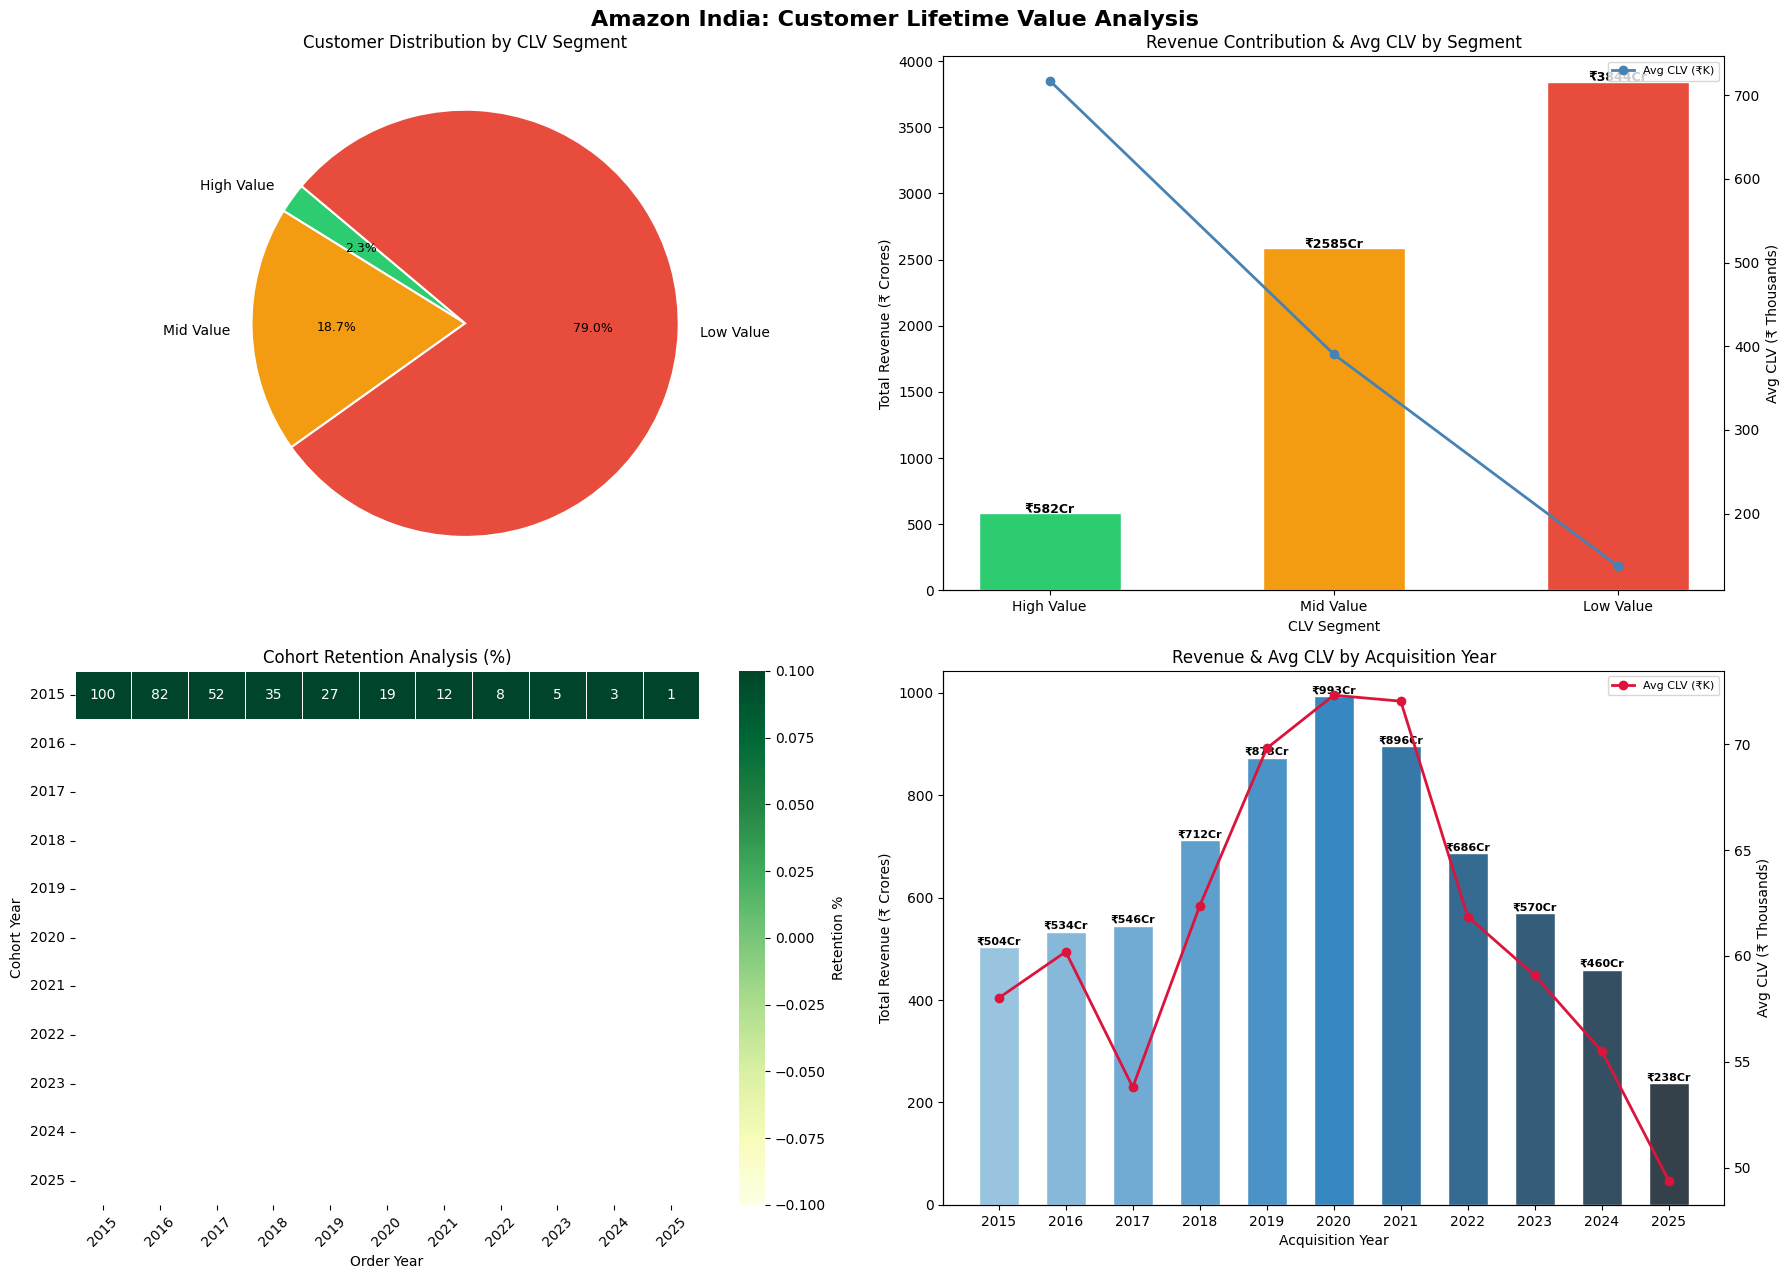

In [32]:
from sqlalchemy import text
# -- EDA Q14: Customer Lifetime Value Analysis (SQL) ----

# -- SQL Query 1: CLV by Customer ----------------------
query_clv = text("""
    WITH customer_stats AS (
        SELECT
            customer_id,
            MIN(order_date::DATE)                               AS first_purchase,
            MAX(order_date::DATE)                               AS last_purchase,
            COUNT(transaction_id)                               AS total_orders,
            SUM(final_amount_inr)                               AS total_revenue,
            ROUND(AVG(final_amount_inr)::NUMERIC, 2)            AS avg_order_value,
            (MAX(order_date::DATE) - MIN(order_date::DATE))     AS customer_lifespan_days
        FROM transactions
        GROUP BY customer_id
    )
    SELECT
        customer_id,
        first_purchase,
        last_purchase,
        total_orders,
        ROUND(total_revenue::NUMERIC, 2)                        AS clv,
        avg_order_value,
        customer_lifespan_days,
        CASE
            WHEN total_orders >= 10 THEN 'High Value'
            WHEN total_orders >= 5  THEN 'Mid Value'
            ELSE 'Low Value'
        END                                                     AS clv_segment
    FROM customer_stats
    ORDER BY clv DESC
""")

# -- SQL Query 2: CLV by Acquisition Year --------------
query_clv_yearly = text("""
    WITH first_year AS (
        SELECT
            customer_id,
            MIN(order_year)                                     AS acquisition_year
        FROM transactions
        GROUP BY customer_id
    )
    SELECT
        f.acquisition_year,
        COUNT(DISTINCT t.customer_id)                           AS total_customers,
        ROUND(AVG(t.final_amount_inr)::NUMERIC, 2)             AS avg_clv,
        ROUND((SUM(t.final_amount_inr) / 1e7)::NUMERIC, 2)     AS total_revenue_cr
    FROM transactions t
    JOIN first_year f ON t.customer_id = f.customer_id
    GROUP BY f.acquisition_year
    ORDER BY f.acquisition_year
""")

# -- SQL Query 3: Cohort Retention --------------------
query_cohort = text("""
    WITH first_year AS (
        SELECT
            customer_id,
            MIN(order_year)                                     AS cohort_year
        FROM transactions
        GROUP BY customer_id
    )
    SELECT
        f.cohort_year,
        t.order_year,
        COUNT(DISTINCT t.customer_id)                           AS active_customers
    FROM transactions t
    JOIN first_year f ON t.customer_id = f.customer_id
    GROUP BY f.cohort_year, t.order_year
    ORDER BY f.cohort_year, t.order_year
""")

# -- SQL Query 4: CLV Segment Overview ----------------
query_clv_segment = text("""
    WITH customer_stats AS (
        SELECT
            customer_id,
            COUNT(transaction_id)                               AS total_orders,
            SUM(final_amount_inr)                               AS total_revenue
        FROM transactions
        GROUP BY customer_id
    ),
    segmented AS (
        SELECT
            CASE
                WHEN total_orders >= 10 THEN 'High Value'
                WHEN total_orders >= 5  THEN 'Mid Value'
                ELSE 'Low Value'
            END                                                 AS clv_segment,
            total_revenue
        FROM customer_stats
    )
    SELECT
        clv_segment,
        COUNT(*)                                                AS total_customers,
        ROUND(AVG(total_revenue)::NUMERIC, 2)                  AS avg_clv,
        ROUND((SUM(total_revenue) / 1e7)::NUMERIC, 2)          AS total_revenue_cr,
        ROUND((COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER ())::NUMERIC, 2)                AS customer_share
    FROM segmented
    GROUP BY clv_segment
    ORDER BY avg_clv DESC
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_clv          = pd.read_sql(query_clv, conn)
    df_clv_yearly   = pd.read_sql(query_clv_yearly, conn)
    df_cohort       = pd.read_sql(query_cohort, conn)
    df_clv_segment  = pd.read_sql(query_clv_segment, conn)

print("=== CLV Segment Overview ===")
print(df_clv_segment.to_string(index=False))
print("\n=== CLV by Acquisition Year ===")
print(df_clv_yearly.to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Customer Lifetime Value Analysis",
             fontsize=16, fontweight="bold")

clv_colors = {
    "High Value": "#2ecc71",
    "Mid Value":  "#f39c12",
    "Low Value":  "#e74c3c"
}

# -- Plot 1: CLV Segment Distribution ------------------
ax1 = axes[0, 0]
wedges, texts, autotexts = ax1.pie(
    df_clv_segment["total_customers"],
    labels=df_clv_segment["clv_segment"],
    colors=[clv_colors[s] for s in df_clv_segment["clv_segment"]],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in autotexts:
    text.set_fontsize(9)
ax1.set_title("Customer Distribution by CLV Segment", fontsize=12)

# -- Plot 2: Revenue Contribution by CLV Segment ------
ax2 = axes[0, 1]
bars = ax2.bar(df_clv_segment["clv_segment"],
               df_clv_segment["total_revenue_cr"],
               color=[clv_colors[s] for s in df_clv_segment["clv_segment"]],
               edgecolor="white", width=0.5)
ax2_twin = ax2.twinx()
ax2_twin.plot(df_clv_segment["clv_segment"],
              df_clv_segment["avg_clv"] / 1e3,
              color="steelblue", marker="o", linewidth=2, label="Avg CLV (₹K)")
for bar, val in zip(bars, df_clv_segment["total_revenue_cr"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"₹{val:.0f}Cr", ha="center", fontsize=9, fontweight="bold")
ax2.set_title("Revenue Contribution & Avg CLV by Segment", fontsize=12)
ax2.set_xlabel("CLV Segment")
ax2.set_ylabel("Total Revenue (₹ Crores)")
ax2_twin.set_ylabel("Avg CLV (₹ Thousands)")
ax2_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax2)

# -- Plot 3: Cohort Retention Heatmap ------------------
ax3 = axes[1, 0]
cohort_pivot = df_cohort.pivot(
    index="cohort_year", columns="order_year", values="active_customers"
).fillna(0)
cohort_pct = cohort_pivot.div(cohort_pivot.iloc[:, 0], axis=0) * 100
sns.heatmap(cohort_pct.round(1), annot=True, fmt=".0f", cmap="YlGn",
            linewidths=0.5, ax=ax3, cbar_kws={"label": "Retention %"})
ax3.set_title("Cohort Retention Analysis (%)", fontsize=12)
ax3.set_xlabel("Order Year")
ax3.set_ylabel("Cohort Year")
ax3.tick_params(axis="x", rotation=45)
ax3.tick_params(axis="y", rotation=0)

# -- Plot 4: CLV by Acquisition Year ------------------
ax4 = axes[1, 1]
bars4 = ax4.bar(df_clv_yearly["acquisition_year"],
                df_clv_yearly["total_revenue_cr"],
                color=sns.color_palette("Blues_d", len(df_clv_yearly)),
                edgecolor="white", width=0.6)
ax4_twin = ax4.twinx()
ax4_twin.plot(df_clv_yearly["acquisition_year"],
              df_clv_yearly["avg_clv"] / 1e3,
              color="crimson", marker="o", linewidth=2, label="Avg CLV (₹K)")
for bar, val in zip(bars4, df_clv_yearly["total_revenue_cr"]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"₹{val:.0f}Cr", ha="center", fontsize=8, fontweight="bold")
ax4.set_title("Revenue & Avg CLV by Acquisition Year", fontsize=12)
ax4.set_xlabel("Acquisition Year")
ax4.set_ylabel("Total Revenue (₹ Crores)")
ax4_twin.set_ylabel("Avg CLV (₹ Thousands)")
ax4_twin.legend(loc="upper right", fontsize=8)
ax4.set_xticks(df_clv_yearly["acquisition_year"])
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q14_clv_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Question 15
Analyze discount and promotional effectiveness. Create discount impact analysis showing correlation between discount percentages, sales volumes, and revenue across categories and time periods.


=== Discount Impact Overview ===
discount_range  total_orders  revenue_cr  avg_order_value  avg_quantity  order_share
   No Discount        500822     3811.63         76107.58          1.25        44.87
         1-10%         53453      376.12         70365.51          1.25         4.79
        11-20%        139014      889.97         64020.19          1.25        12.46
        21-30%        171125      977.29         57109.59          1.25        15.33
        31-50%        125637      572.13         45538.46          1.25        11.26
          50%+        126059      383.30         30406.49          1.25        11.29

=== Discount by Subcategory ===
       subcategory  avg_discount  total_orders  revenue_cr  avg_order_value
             Audio         17.50         50152      110.23         21978.52
       Smartphones         17.42        819050     5115.02         62450.68
           Tablets         17.42         69343      419.47         60492.69
       Smart Watch         17.41   

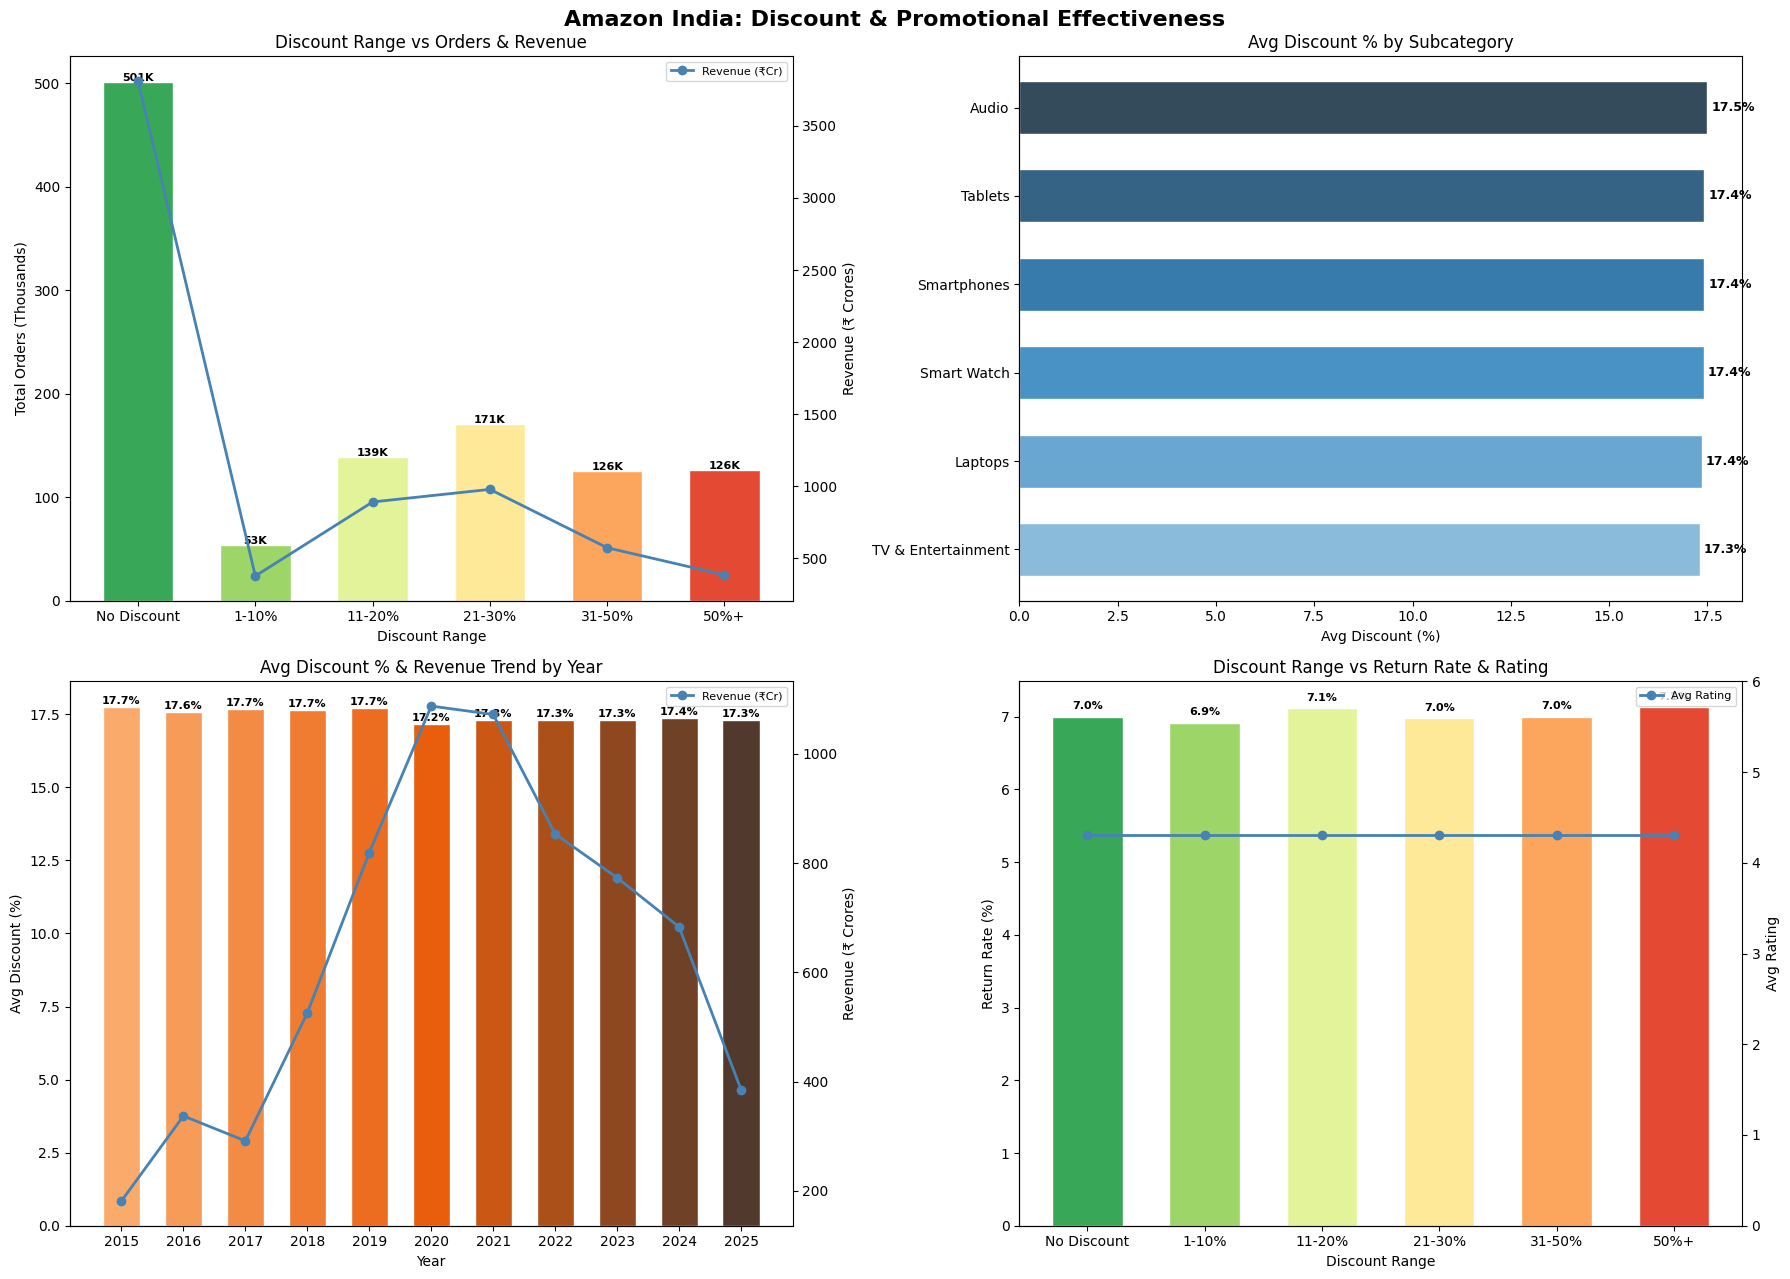

In [33]:

from sqlalchemy import text
# -- EDA Q15: Discount & Promotional Effectiveness -------

# -- SQL Query 1: Discount Impact Overview ------------
query_discount = text("""
    SELECT
        CASE
            WHEN discount_percent = 0        THEN 'No Discount'
            WHEN discount_percent <= 10      THEN '1-10%'
            WHEN discount_percent <= 20      THEN '11-20%'
            WHEN discount_percent <= 30      THEN '21-30%'
            WHEN discount_percent <= 50      THEN '31-50%'
            ELSE '50%+'
        END                                                     AS discount_range,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(quantity)::NUMERIC, 2)                        AS avg_quantity,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER ())::NUMERIC, 2)   AS order_share
    FROM transactions
    GROUP BY discount_range
    ORDER BY MIN(discount_percent)
""")

# -- SQL Query 2: Discount Effectiveness by Subcategory --
query_discount_sub = text("""
    SELECT
        subcategory,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value
    FROM transactions
    GROUP BY subcategory
    ORDER BY avg_discount DESC
""")

# -- SQL Query 3: Discount Trend by Year --------------
query_discount_yearly = text("""
    SELECT
        order_year,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    GROUP BY order_year
    ORDER BY order_year
""")

# -- SQL Query 4: Discount vs Return Rate --------------
query_discount_return = text("""
    SELECT
        CASE
            WHEN discount_percent = 0        THEN 'No Discount'
            WHEN discount_percent <= 10      THEN '1-10%'
            WHEN discount_percent <= 20      THEN '11-20%'
            WHEN discount_percent <= 30      THEN '21-30%'
            WHEN discount_percent <= 50      THEN '31-50%'
            ELSE '50%+'
        END                                                     AS discount_range,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(CASE WHEN return_status = 'Returned'
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                 AS return_rate,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating
    FROM transactions
    GROUP BY discount_range
    ORDER BY MIN(discount_percent)
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_discount         = pd.read_sql(query_discount, conn)
    df_discount_sub     = pd.read_sql(query_discount_sub, conn)
    df_discount_yearly  = pd.read_sql(query_discount_yearly, conn)
    df_discount_return  = pd.read_sql(query_discount_return, conn)

print("=== Discount Impact Overview ===")
print(df_discount.to_string(index=False))
print("\n=== Discount by Subcategory ===")
print(df_discount_sub.to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Discount & Promotional Effectiveness",
             fontsize=16, fontweight="bold")

discount_order  = ["No Discount", "1-10%", "11-20%", "21-30%", "31-50%", "50%+"]
discount_colors = sns.color_palette("RdYlGn_r", len(discount_order))

# -- Plot 1: Discount Range vs Orders & Revenue --------
ax1 = axes[0, 0]
df_d = df_discount.set_index("discount_range").reindex(discount_order).reset_index()
bars = ax1.bar(df_d["discount_range"], df_d["total_orders"] / 1e3,
               color=discount_colors, edgecolor="white", width=0.6)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_d["discount_range"], df_d["revenue_cr"],
              color="steelblue", marker="o", linewidth=2, label="Revenue (₹Cr)")
for bar, val in zip(bars, df_d["total_orders"] / 1e3):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}K", ha="center", fontsize=8, fontweight="bold")
ax1.set_title("Discount Range vs Orders & Revenue", fontsize=12)
ax1.set_xlabel("Discount Range")
ax1.set_ylabel("Total Orders (Thousands)")
ax1_twin.set_ylabel("Revenue (₹ Crores)")
ax1_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax1)

# -- Plot 2: Avg Discount by Subcategory --------------
ax2 = axes[0, 1]
df_ds_sorted = df_discount_sub.sort_values("avg_discount", ascending=True)
bars2 = ax2.barh(df_ds_sorted["subcategory"], df_ds_sorted["avg_discount"],
                 color=sns.color_palette("Blues_d", len(df_ds_sorted)),
                 edgecolor="white", height=0.6)
ax2_twin = ax2.twinx()
ax2_twin.set_yticks([])
for bar, val in zip(bars2, df_ds_sorted["avg_discount"]):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax2.set_title("Avg Discount % by Subcategory", fontsize=12)
ax2.set_xlabel("Avg Discount (%)")
sns.despine(ax=ax2)

# -- Plot 3: Discount Trend by Year --------------------
ax3 = axes[1, 0]
bars3 = ax3.bar(df_discount_yearly["order_year"],
                df_discount_yearly["avg_discount"],
                color=sns.color_palette("Oranges_d", len(df_discount_yearly)),
                edgecolor="white", width=0.6)
ax3_twin = ax3.twinx()
ax3_twin.plot(df_discount_yearly["order_year"],
              df_discount_yearly["revenue_cr"],
              color="steelblue", marker="o", linewidth=2, label="Revenue (₹Cr)")
for bar, val in zip(bars3, df_discount_yearly["avg_discount"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax3.set_title("Avg Discount % & Revenue Trend by Year", fontsize=12)
ax3.set_xlabel("Year")
ax3.set_ylabel("Avg Discount (%)")
ax3_twin.set_ylabel("Revenue (₹ Crores)")
ax3_twin.legend(loc="upper right", fontsize=8)
ax3.set_xticks(df_discount_yearly["order_year"])
sns.despine(ax=ax3)

# -- Plot 4: Discount vs Return Rate & Rating ----------
ax4 = axes[1, 1]
df_dr = df_discount_return.set_index("discount_range").reindex(discount_order).reset_index()
bars4 = ax4.bar(df_dr["discount_range"], df_dr["return_rate"],
                color=discount_colors, edgecolor="white", width=0.6)
ax4_twin = ax4.twinx()
ax4_twin.plot(df_dr["discount_range"], df_dr["avg_rating"],
              color="steelblue", marker="o", linewidth=2, label="Avg Rating")
for bar, val in zip(bars4, df_dr["return_rate"]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax4.set_title("Discount Range vs Return Rate & Rating", fontsize=12)
ax4.set_xlabel("Discount Range")
ax4.set_ylabel("Return Rate (%)")
ax4_twin.set_ylabel("Avg Rating")
ax4_twin.set_ylim(0, 6)
ax4_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q15_discount_effectiveness.png", dpi=150, bbox_inches="tight")
plt.show()

Question 16
Study product rating patterns and their impact on sales. Analyze rating distributions, correlation with sales performance, and identify patterns across categories and price ranges.


=== Rating Distribution ===
 rating  total_orders  revenue_cr  avg_order_value  order_share
      3         46427      249.36         53709.94         5.97
      4        531729     3227.03         60689.33        68.35
      5        199772     1414.93         70827.29        25.68

=== Rating by Subcategory ===
       subcategory  avg_customer_rating  avg_product_rating  total_orders  revenue_cr
TV & Entertainment                 4.38                4.03         11387      126.57
           Laptops                 4.37                3.92         60922      635.35
           Tablets                 4.33                4.00         48294      292.96
       Smartphones                 4.31                3.98        570838     3567.26
       Smart Watch                 4.28                3.99         51521      192.51
             Audio                 4.23                3.91         34966       76.66


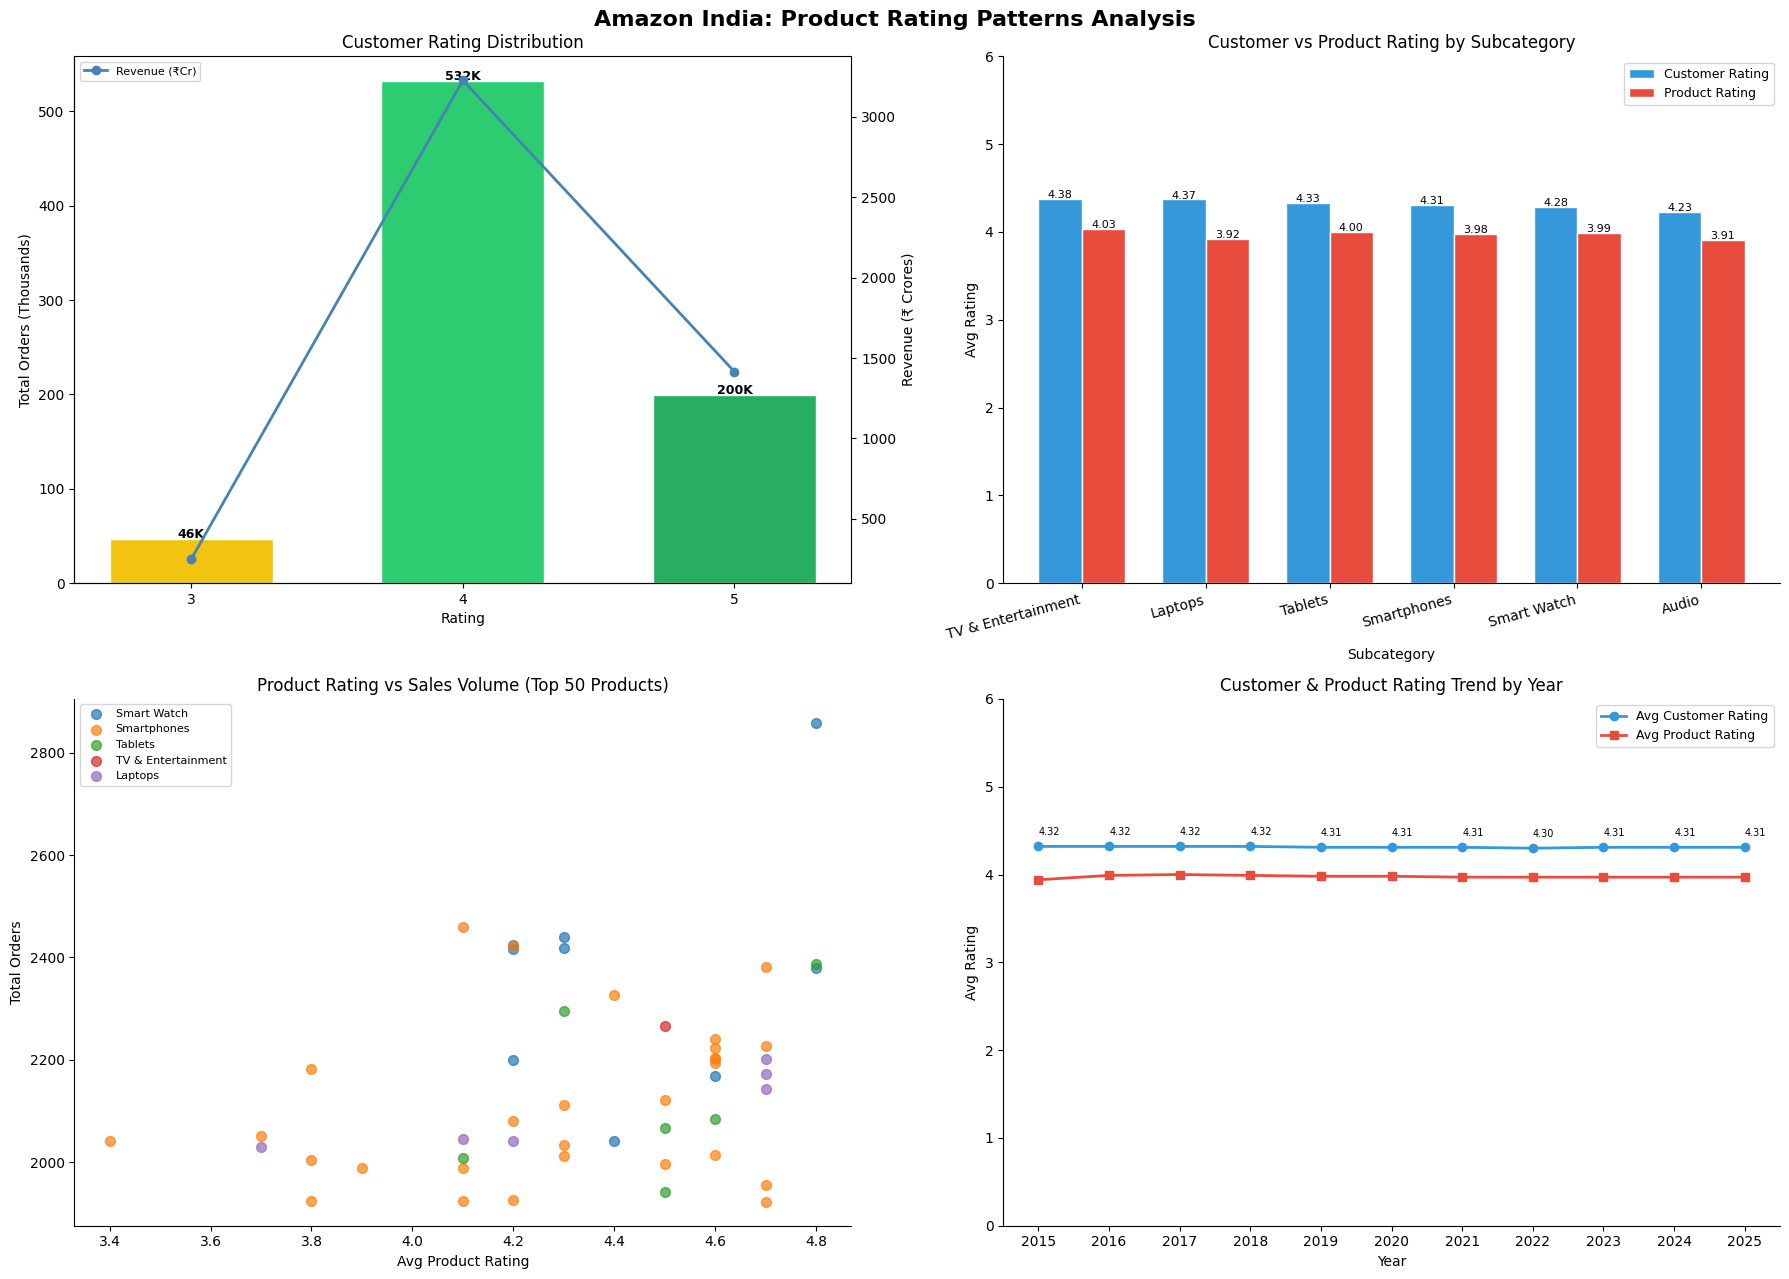

In [34]:
from sqlalchemy import text
# -- EDA Q16: Product Rating Patterns  ------------

# -- SQL Query 1: Rating Distribution ------------------
query_rating = text("""
    SELECT
        ROUND(customer_rating)::INT                            AS rating,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND((COUNT(transaction_id) * 100.0 /
            SUM(COUNT(transaction_id)) OVER ())::NUMERIC, 2)   AS order_share
    FROM transactions
    WHERE customer_rating IS NOT NULL
    GROUP BY ROUND(customer_rating)::INT
    ORDER BY rating
""")

# -- SQL Query 2: Rating by Subcategory ----------------
query_rating_sub = text("""
    SELECT
        subcategory,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_customer_rating,
        ROUND(AVG(product_rating)::NUMERIC, 2)                 AS avg_product_rating,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    WHERE customer_rating IS NOT NULL
    GROUP BY subcategory
    ORDER BY avg_customer_rating DESC
""")

# -- SQL Query 3: Rating vs Sales Performance ----------
query_rating_sales = text("""
    SELECT
        product_id,
        product_name,
        ROUND(AVG(product_rating)::NUMERIC, 2)                 AS avg_product_rating,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(original_price_inr)::NUMERIC, 2)             AS avg_price,
        subcategory
    FROM transactions
    GROUP BY product_id, product_name, subcategory
    ORDER BY total_orders DESC
    LIMIT 50
""")

# -- SQL Query 4: Rating Trend by Year ----------------
query_rating_yearly = text("""
    SELECT
        order_year,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_customer_rating,
        ROUND(AVG(product_rating)::NUMERIC, 2)                 AS avg_product_rating,
        COUNT(transaction_id)                                   AS total_rated_orders
    FROM transactions
    WHERE customer_rating IS NOT NULL
    GROUP BY order_year
    ORDER BY order_year
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_rating           = pd.read_sql(query_rating, conn)
    df_rating_sub       = pd.read_sql(query_rating_sub, conn)
    df_rating_sales     = pd.read_sql(query_rating_sales, conn)
    df_rating_yearly    = pd.read_sql(query_rating_yearly, conn)

print("=== Rating Distribution ===")
print(df_rating.to_string(index=False))
print("\n=== Rating by Subcategory ===")
print(df_rating_sub.to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Product Rating Patterns Analysis",
             fontsize=16, fontweight="bold")

rating_colors = {1: "#e74c3c", 2: "#e67e22", 3: "#f1c40f",
                 4: "#2ecc71", 5: "#27ae60"}

# -- Plot 1: Rating Distribution ----------------------
ax1 = axes[0, 0]
bars = ax1.bar(df_rating["rating"],
               df_rating["total_orders"] / 1e3,
               color=[rating_colors[r] for r in df_rating["rating"]],
               edgecolor="white", width=0.6)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_rating["rating"], df_rating["revenue_cr"],
              color="steelblue", marker="o", linewidth=2, label="Revenue (₹Cr)")
for bar, val in zip(bars, df_rating["total_orders"] / 1e3):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}K", ha="center", fontsize=9, fontweight="bold")
ax1.set_title("Customer Rating Distribution", fontsize=12)
ax1.set_xlabel("Rating")
ax1.set_ylabel("Total Orders (Thousands)")
ax1_twin.set_ylabel("Revenue (₹ Crores)")
ax1_twin.legend(loc="upper left", fontsize=8)
ax1.set_xticks(df_rating["rating"])
sns.despine(ax=ax1)

# -- Plot 2: Customer vs Product Rating by Subcategory --
ax2 = axes[0, 1]
x      = range(len(df_rating_sub))
width  = 0.35
bars2a = ax2.bar([i - width/2 for i in x],
                 df_rating_sub["avg_customer_rating"],
                 width=width, label="Customer Rating",
                 color="#3498db", edgecolor="white")
bars2b = ax2.bar([i + width/2 for i in x],
                 df_rating_sub["avg_product_rating"],
                 width=width, label="Product Rating",
                 color="#e74c3c", edgecolor="white")
for bar, val in zip(bars2a, df_rating_sub["avg_customer_rating"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha="center", fontsize=8)
for bar, val in zip(bars2b, df_rating_sub["avg_product_rating"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha="center", fontsize=8)
ax2.set_title("Customer vs Product Rating by Subcategory", fontsize=12)
ax2.set_xlabel("Subcategory")
ax2.set_ylabel("Avg Rating")
ax2.set_xticks(list(x))
ax2.set_xticklabels(df_rating_sub["subcategory"], rotation=15, ha="right")
ax2.set_ylim(0, 6)
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

# -- Plot 3: Product Rating vs Sales Scatter ------------
ax3 = axes[1, 0]
sub_palette  = sns.color_palette("tab10", len(df_rating_sales["subcategory"].unique()))
sub_color_map = {s: sub_palette[i] for i, s in
                 enumerate(df_rating_sales["subcategory"].unique())}
for sub in df_rating_sales["subcategory"].unique():
    data = df_rating_sales[df_rating_sales["subcategory"] == sub]
    ax3.scatter(data["avg_product_rating"], data["total_orders"],
                c=[sub_color_map[sub]], alpha=0.7, s=50, label=sub)
ax3.set_title("Product Rating vs Sales Volume (Top 50 Products)", fontsize=12)
ax3.set_xlabel("Avg Product Rating")
ax3.set_ylabel("Total Orders")
ax3.legend(fontsize=8)
sns.despine(ax=ax3)

# -- Plot 4: Rating Trend by Year ----------------------
ax4 = axes[1, 1]
ax4.plot(df_rating_yearly["order_year"],
         df_rating_yearly["avg_customer_rating"],
         marker="o", linewidth=2, color="#3498db", label="Avg Customer Rating")
ax4.plot(df_rating_yearly["order_year"],
         df_rating_yearly["avg_product_rating"],
         marker="s", linewidth=2, color="#e74c3c", label="Avg Product Rating")
for i, row in df_rating_yearly.iterrows():
    ax4.annotate(f"{row['avg_customer_rating']:.2f}",
                 (row["order_year"], row["avg_customer_rating"]),
                 textcoords="offset points", xytext=(0, 8), fontsize=7)
ax4.set_title("Customer & Product Rating Trend by Year", fontsize=12)
ax4.set_xlabel("Year")
ax4.set_ylabel("Avg Rating")
ax4.set_ylim(0, 6)
ax4.legend(fontsize=9)
ax4.set_xticks(df_rating_yearly["order_year"])
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q16_rating_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

Question 17
Create customer journey analysis showing purchase frequency patterns, category transitions, and customer evolution from first purchase to loyal customers using flow diagrams and transition matrices.


=== Purchase Frequency Segments ===
purchase_segment  customers  avg_orders  avg_spent  customer_share
        One-time      91973        1.00   63098.63           25.95
      2-3 Orders     147455        2.42  151685.42           41.61
      4-5 Orders      66783        4.39  277564.63           18.85
     6-10 Orders      43005        7.20  451255.26           12.14
      10+ Orders       5146       12.59  775656.44            1.45

=== Category Transitions (Top 10) ===
first_category    second_category  transitions
   Smartphones        Smartphones       140839
       Laptops        Smartphones        14990
   Smartphones            Laptops        14833
   Smart Watch        Smartphones        12815
   Smartphones        Smart Watch        12681
       Tablets        Smartphones        12328
   Smartphones            Tablets        11470
         Audio        Smartphones         8679
   Smartphones              Audio         8564
   Smartphones TV & Entertainment         2757


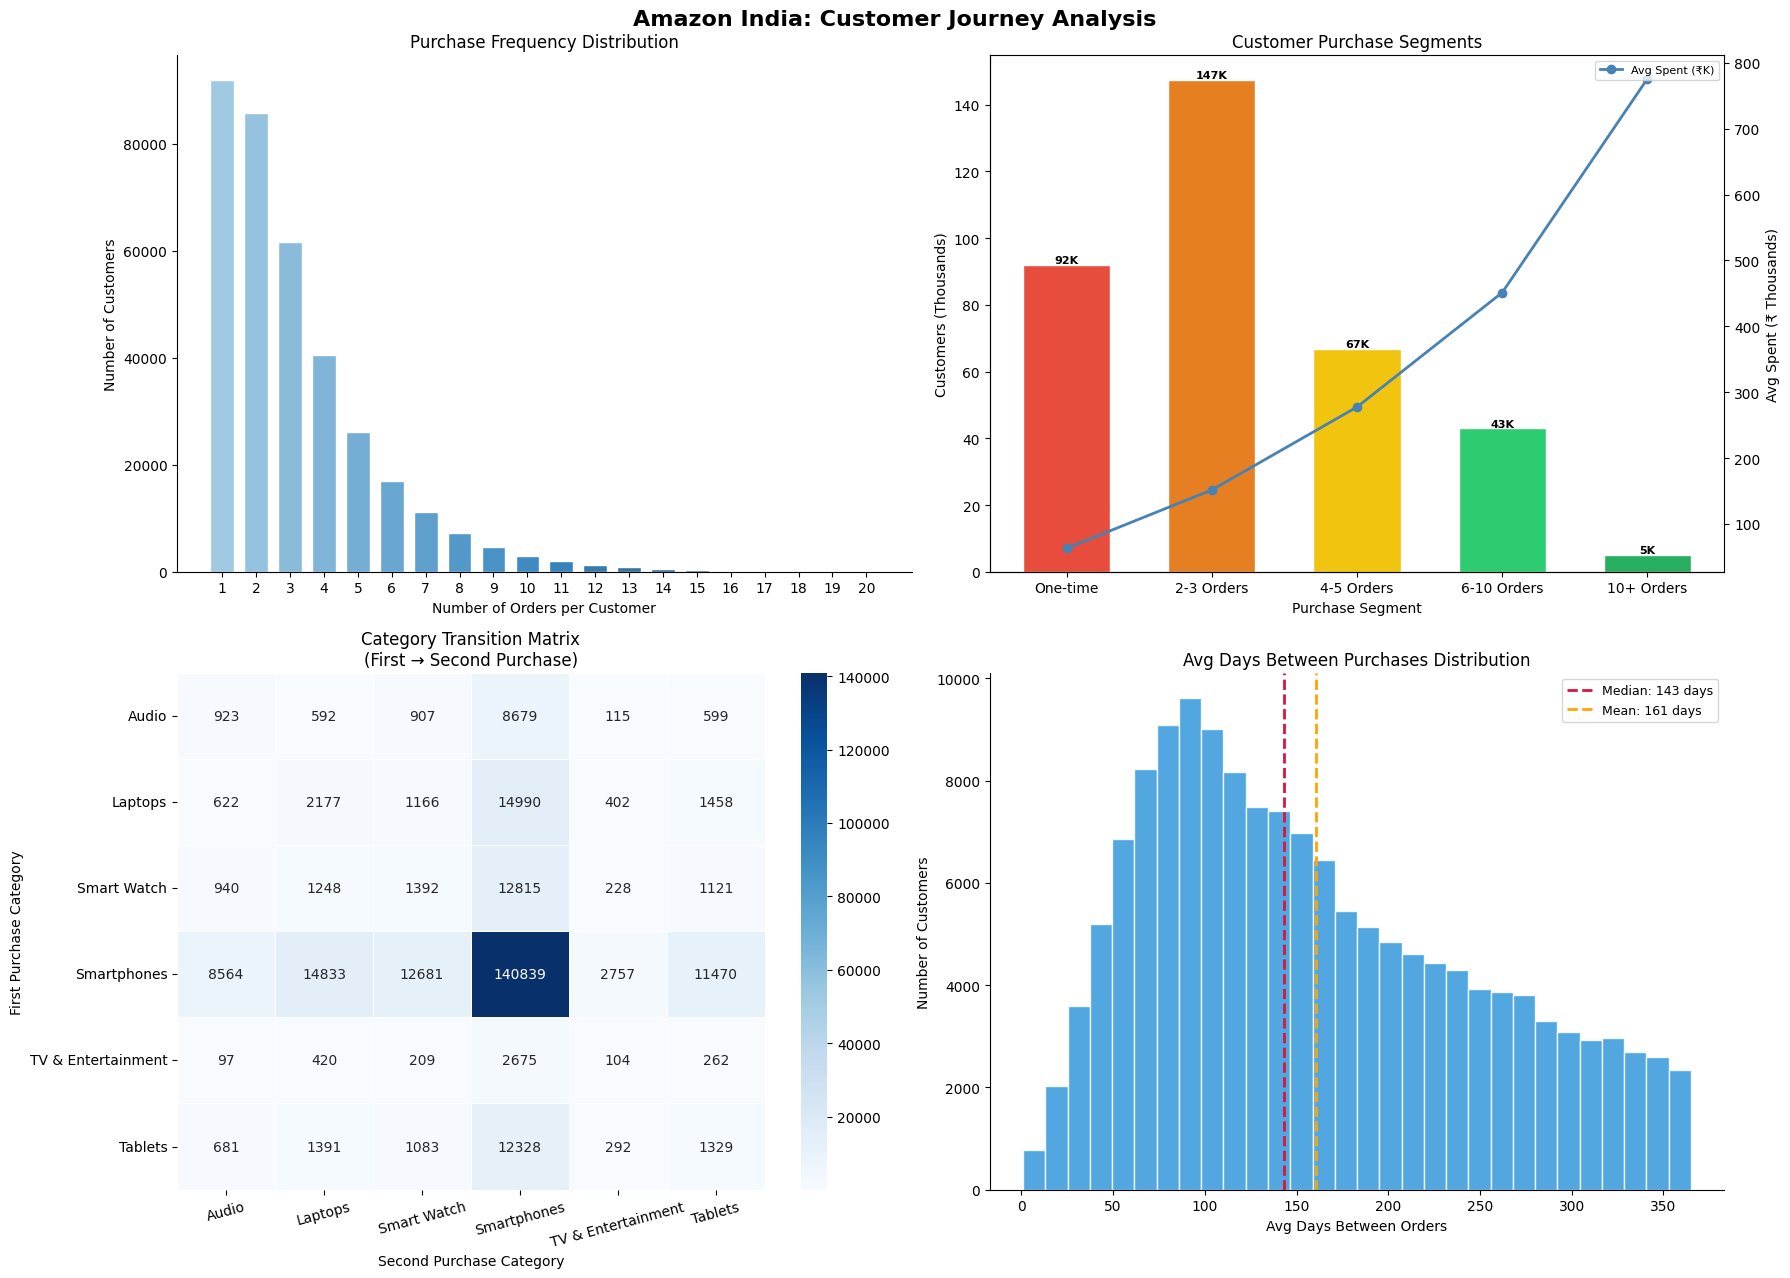

In [35]:
from sqlalchemy import text

# -- EDA Q17: Customer Journey Analysis (SQL) ----------

# -- SQL Query 1: Purchase Frequency Distribution -----
query_freq = text("""
    SELECT
        total_orders,
        COUNT(customer_id)                                      AS customer_count,
        ROUND((COUNT(customer_id) * 100.0 /
            SUM(COUNT(customer_id)) OVER ())::NUMERIC, 2)      AS customer_share
    FROM (
        SELECT
            customer_id,
            COUNT(transaction_id)                               AS total_orders
        FROM transactions
        GROUP BY customer_id
    ) AS order_counts
    GROUP BY total_orders
    ORDER BY total_orders
""")

# -- SQL Query 2: First vs Repeat Purchase Behavior ----
query_repeat = text("""
    WITH customer_orders AS (
        SELECT
            customer_id,
            COUNT(transaction_id)                               AS total_orders,
            MIN(order_date::DATE)                               AS first_purchase,
            MAX(order_date::DATE)                               AS last_purchase,
            SUM(final_amount_inr)                               AS total_spent
        FROM transactions
        GROUP BY customer_id
    )
    SELECT
        CASE
            WHEN total_orders = 1  THEN 'One-time'
            WHEN total_orders <= 3 THEN '2-3 Orders'
            WHEN total_orders <= 5 THEN '4-5 Orders'
            WHEN total_orders <= 10 THEN '6-10 Orders'
            ELSE '10+ Orders'
        END                                                     AS purchase_segment,
        COUNT(customer_id)                                      AS customers,
        ROUND(AVG(total_orders)::NUMERIC, 2)                   AS avg_orders,
        ROUND(AVG(total_spent)::NUMERIC, 2)                    AS avg_spent,
        ROUND((COUNT(customer_id) * 100.0 /
            SUM(COUNT(customer_id)) OVER ())::NUMERIC, 2)      AS customer_share
    FROM customer_orders
    GROUP BY purchase_segment
    ORDER BY MIN(total_orders)
""")

# -- SQL Query 3: Category Transition Analysis ----------
query_transition = text("""
    WITH ranked_orders AS (
        SELECT
            customer_id,
            subcategory,
            order_date,
            ROW_NUMBER() OVER (
                PARTITION BY customer_id
                ORDER BY order_date
            )                                                   AS order_rank
        FROM transactions
    )
    SELECT
        a.subcategory                                           AS first_category,
        b.subcategory                                           AS second_category,
        COUNT(*)                                                AS transitions
    FROM ranked_orders a
    JOIN ranked_orders b
        ON a.customer_id = b.customer_id
        AND a.order_rank = 1
        AND b.order_rank = 2
    GROUP BY a.subcategory, b.subcategory
    ORDER BY transitions DESC
""")

# -- SQL Query 4: Avg Days Between Purchases ------------
query_gap = text("""
    WITH order_gaps AS (
        SELECT
            customer_id,
            order_date::DATE,
            LAG(order_date::DATE) OVER (
                PARTITION BY customer_id
                ORDER BY order_date
            )                                                   AS prev_order_date
        FROM transactions
    )
    SELECT
        customer_id,
        ROUND(AVG(order_date - prev_order_date)::NUMERIC, 0)   AS avg_days_between_orders
    FROM order_gaps
    WHERE prev_order_date IS NOT NULL
    GROUP BY customer_id
    HAVING COUNT(*) >= 2
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_freq         = pd.read_sql(query_freq, conn)
    df_repeat       = pd.read_sql(query_repeat, conn)
    df_transition   = pd.read_sql(query_transition, conn)
    df_gap          = pd.read_sql(query_gap, conn)

print("=== Purchase Frequency Segments ===")
print(df_repeat.to_string(index=False))
print("\n=== Category Transitions (Top 10) ===")
print(df_transition.head(10).to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Customer Journey Analysis",
             fontsize=16, fontweight="bold")

segment_order  = ["One-time", "2-3 Orders", "4-5 Orders", "6-10 Orders", "10+ Orders"]
segment_colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]

# -- Plot 1: Purchase Frequency Distribution ------------
ax1 = axes[0, 0]
df_freq_plot = df_freq[df_freq["total_orders"] <= 20]
ax1.bar(df_freq_plot["total_orders"],
        df_freq_plot["customer_count"],
        color=sns.color_palette("Blues_d", len(df_freq_plot)),
        edgecolor="white", width=0.7)
ax1.set_title("Purchase Frequency Distribution", fontsize=12)
ax1.set_xlabel("Number of Orders per Customer")
ax1.set_ylabel("Number of Customers")
ax1.set_xticks(df_freq_plot["total_orders"])
sns.despine(ax=ax1)

# -- Plot 2: Purchase Segment Analysis ----------------
ax2 = axes[0, 1]
df_rep = df_repeat.set_index("purchase_segment").reindex(segment_order).reset_index()
bars = ax2.bar(df_rep["purchase_segment"], df_rep["customers"] / 1e3,
               color=segment_colors, edgecolor="white", width=0.6)
ax2_twin = ax2.twinx()
ax2_twin.plot(df_rep["purchase_segment"], df_rep["avg_spent"] / 1e3,
              color="steelblue", marker="o", linewidth=2, label="Avg Spent (₹K)")
for bar, val in zip(bars, df_rep["customers"] / 1e3):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.0f}K\n({df_rep.iloc[list(df_rep['purchase_segment']).index(bar.get_x() + bar.get_width()/2 - 0.5 + 0.5)]['customer_share']:.1f}%)"
             if False else f"{val:.0f}K",
             ha="center", fontsize=8, fontweight="bold")
ax2.set_title("Customer Purchase Segments", fontsize=12)
ax2.set_xlabel("Purchase Segment")
ax2.set_ylabel("Customers (Thousands)")
ax2_twin.set_ylabel("Avg Spent (₹ Thousands)")
ax2_twin.legend(loc="upper right", fontsize=8)
sns.despine(ax=ax2)

# -- Plot 3: Category Transition Heatmap --------------
ax3 = axes[1, 0]
transition_pivot = df_transition.pivot(
    index="first_category", columns="second_category", values="transitions"
).fillna(0)
sns.heatmap(transition_pivot, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, ax=ax3)
ax3.set_title("Category Transition Matrix\n(First → Second Purchase)", fontsize=12)
ax3.set_xlabel("Second Purchase Category")
ax3.set_ylabel("First Purchase Category")
ax3.tick_params(axis="x", rotation=15)
ax3.tick_params(axis="y", rotation=0)

# -- Plot 4: Days Between Purchases Distribution --------
ax4 = axes[1, 1]
df_gap_clean = df_gap[
    (df_gap["avg_days_between_orders"] > 0) &
    (df_gap["avg_days_between_orders"] <= 365)
]
ax4.hist(df_gap_clean["avg_days_between_orders"], bins=30,
         color="#3498db", edgecolor="white", alpha=0.85)
ax4.axvline(df_gap_clean["avg_days_between_orders"].median(),
            color="crimson", linewidth=2, linestyle="--",
            label=f"Median: {df_gap_clean['avg_days_between_orders'].median():.0f} days")
ax4.axvline(df_gap_clean["avg_days_between_orders"].mean(),
            color="orange", linewidth=2, linestyle="--",
            label=f"Mean: {df_gap_clean['avg_days_between_orders'].mean():.0f} days")
ax4.set_title("Avg Days Between Purchases Distribution", fontsize=12)
ax4.set_xlabel("Avg Days Between Orders")
ax4.set_ylabel("Number of Customers")
ax4.legend(fontsize=9)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q17_customer_journey.png", dpi=150, bbox_inches="tight")
plt.show()

Question 18
Analyze inventory and product lifecycle patterns. Study product launch success, decline phases, and category evolution over the decade with detailed trend analysis.


=== Product Launch by Year ===
 launch_year  products_launched  total_orders  revenue_cr  avg_order_value
        2015                164        210967     1284.95         60907.53
        2016                148        165877     1106.81         66724.77
        2017                156        159793      959.62         60054.22
        2018                188        144791      897.83         62008.43
        2019                208        144296      970.94         67287.76
        2020                205        109883      701.98         63883.92
        2021                193         71659      443.31         61863.90
        2022                177         45754      294.67         64403.77
        2023                189         36182      207.09         57235.61
        2024                195         20006      109.97         54970.04
        2025                181          6902       33.28         48223.34

=== Top 10 Products ===
 product_id                      product_nam

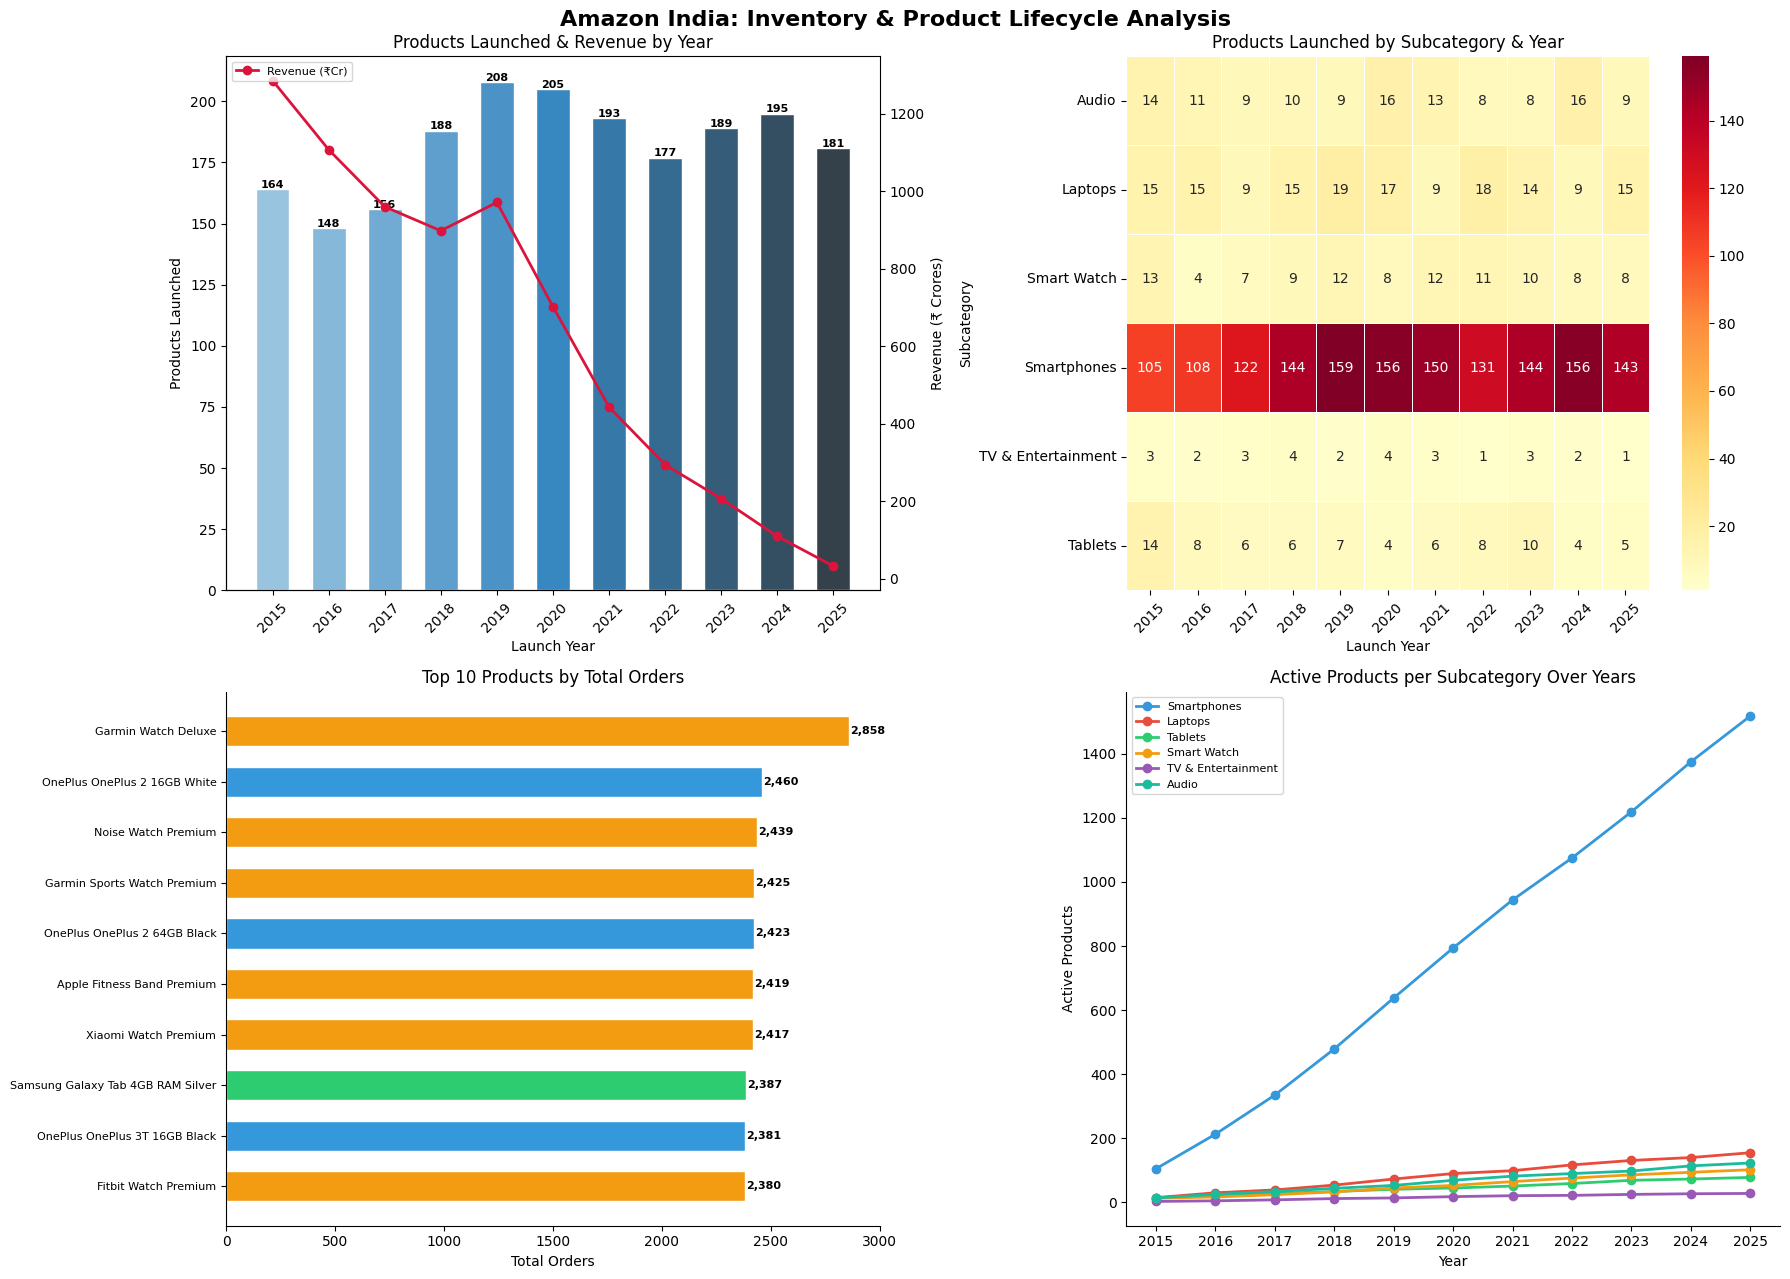

In [36]:
from sqlalchemy import text

# -- EDA Q18: Inventory & Product Lifecycle  ------

# -- SQL Query 1: Product Launch Success by Year --------
query_launch = text("""
    SELECT
        p.launch_year,
        COUNT(DISTINCT p.product_id)                            AS products_launched,
        COUNT(t.transaction_id)                                 AS total_orders,
        ROUND((SUM(t.final_amount_inr) / 1e7)::NUMERIC, 2)     AS revenue_cr,
        ROUND(AVG(t.final_amount_inr)::NUMERIC, 2)             AS avg_order_value
    FROM products p
    LEFT JOIN transactions t ON p.product_id = t.product_id
    GROUP BY p.launch_year
    ORDER BY p.launch_year
""")

# -- SQL Query 2: Product Lifecycle by Subcategory ------
query_lifecycle = text("""
    SELECT
        p.subcategory,
        p.launch_year,
        COUNT(DISTINCT p.product_id)                            AS products,
        COUNT(t.transaction_id)                                 AS total_orders,
        ROUND((SUM(t.final_amount_inr) / 1e7)::NUMERIC, 2)     AS revenue_cr
    FROM products p
    LEFT JOIN transactions t ON p.product_id = t.product_id
    GROUP BY p.subcategory, p.launch_year
    ORDER BY p.subcategory, p.launch_year
""")

# -- SQL Query 3: Top & Bottom Products by Orders ------
query_product_perf = text("""
    SELECT
        t.product_id,
        t.product_name,
        t.subcategory,
        COUNT(t.transaction_id)                                 AS total_orders,
        ROUND((SUM(t.final_amount_inr) / 1e7)::NUMERIC, 2)     AS revenue_cr,
        ROUND(AVG(t.product_rating)::NUMERIC, 2)               AS avg_rating,
        p.launch_year
    FROM transactions t
    JOIN products p ON t.product_id = p.product_id
    GROUP BY t.product_id, t.product_name, t.subcategory, p.launch_year
    ORDER BY total_orders DESC
    LIMIT 20
""")

# -- SQL Query 4: Subcategory Evolution Over Years ------
query_sub_evolution = text("""
    SELECT
        order_year,
        subcategory,
        COUNT(DISTINCT product_id)                              AS active_products,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    GROUP BY order_year, subcategory
    ORDER BY order_year, subcategory
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_launch       = pd.read_sql(query_launch, conn)
    df_lifecycle    = pd.read_sql(query_lifecycle, conn)
    df_product_perf = pd.read_sql(query_product_perf, conn)
    df_sub_evo      = pd.read_sql(query_sub_evolution, conn)

print("=== Product Launch by Year ===")
print(df_launch.to_string(index=False))
print("\n=== Top 10 Products ===")
print(df_product_perf.head(10).to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Inventory & Product Lifecycle Analysis",
             fontsize=16, fontweight="bold")

sub_colors = {
    "Smartphones":        "#3498db",
    "Laptops":            "#e74c3c",
    "Tablets":            "#2ecc71",
    "Smart Watch":        "#f39c12",
    "TV & Entertainment": "#9b59b6",
    "Audio":              "#1abc9c"
}

# -- Plot 1: Product Launch & Revenue by Year ----------
ax1 = axes[0, 0]
bars = ax1.bar(df_launch["launch_year"],
               df_launch["products_launched"],
               color=sns.color_palette("Blues_d", len(df_launch)),
               edgecolor="white", width=0.6)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_launch["launch_year"],
              df_launch["revenue_cr"],
              color="crimson", marker="o", linewidth=2, label="Revenue (₹Cr)")
for bar, val in zip(bars, df_launch["products_launched"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val}", ha="center", fontsize=8, fontweight="bold")
ax1.set_title("Products Launched & Revenue by Year", fontsize=12)
ax1.set_xlabel("Launch Year")
ax1.set_ylabel("Products Launched")
ax1_twin.set_ylabel("Revenue (₹ Crores)")
ax1_twin.legend(loc="upper left", fontsize=8)
ax1.set_xticks(df_launch["launch_year"])
ax1.tick_params(axis="x", rotation=45)
sns.despine(ax=ax1)

# -- Plot 2: Subcategory Product Lifecycle Heatmap ------
ax2 = axes[0, 1]
lifecycle_pivot = df_lifecycle.pivot_table(
    index="subcategory", columns="launch_year",
    values="products", aggfunc="sum"
).fillna(0)
sns.heatmap(lifecycle_pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax2)
ax2.set_title("Products Launched by Subcategory & Year", fontsize=12)
ax2.set_xlabel("Launch Year")
ax2.set_ylabel("Subcategory")
ax2.tick_params(axis="x", rotation=45)
ax2.tick_params(axis="y", rotation=0)

# -- Plot 3: Top 10 Products by Orders ----------------
ax3 = axes[1, 0]
df_top10 = df_product_perf.head(10).sort_values("total_orders", ascending=True)
bars3 = ax3.barh(df_top10["product_name"], df_top10["total_orders"],
                 color=[sub_colors.get(s, "#95a5a6") for s in df_top10["subcategory"]],
                 edgecolor="white", height=0.6)
for bar, val in zip(bars3, df_top10["total_orders"]):
    ax3.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=8, fontweight="bold")
ax3.set_title("Top 10 Products by Total Orders", fontsize=12)
ax3.set_xlabel("Total Orders")
ax3.tick_params(axis="y", labelsize=8)
sns.despine(ax=ax3)

# -- Plot 4: Subcategory Active Products Over Years ----
ax4 = axes[1, 1]
sub_evo_pivot = df_sub_evo.pivot(
    index="order_year", columns="subcategory", values="active_products"
).fillna(0)
for col, color in sub_colors.items():
    if col in sub_evo_pivot.columns:
        ax4.plot(sub_evo_pivot.index, sub_evo_pivot[col],
                 marker="o", linewidth=2, label=col, color=color)
ax4.set_title("Active Products per Subcategory Over Years", fontsize=12)
ax4.set_xlabel("Year")
ax4.set_ylabel("Active Products")
ax4.legend(fontsize=8)
ax4.set_xticks(sub_evo_pivot.index)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q18_product_lifecycle.png", dpi=150, bbox_inches="tight")
plt.show()

Question 19
Build competitive pricing analysis comparing brand positioning, price ranges, and market penetration strategies across different product categories using box plots and competitive matrices.


=== Brand Price Positioning (Smartphones Top 8) ===
  brand subcategory  avg_price  min_price  max_price  price_stddev  total_products  total_orders
  Apple Smartphones  132560.64    1055.39  342829.99      74847.87             268         81350
Samsung Smartphones   84257.46    1001.19  342964.60      48750.72             293        191995
OnePlus Smartphones   68907.66    1018.55  396216.80      25116.64             205        157642
Nothing Smartphones   34388.00    4061.14  344081.30      13304.88              54         11535
   Vivo Smartphones   32134.39    1837.28  359455.80      13163.96             102         70556
 Xiaomi Smartphones   31350.27    1695.33  365792.30      12900.87             223        129895
   Oppo Smartphones   31155.18    1944.34  368338.10      12043.24              98         70560
 Realme Smartphones   30325.98    1593.39  352283.00      13214.07             173         68069


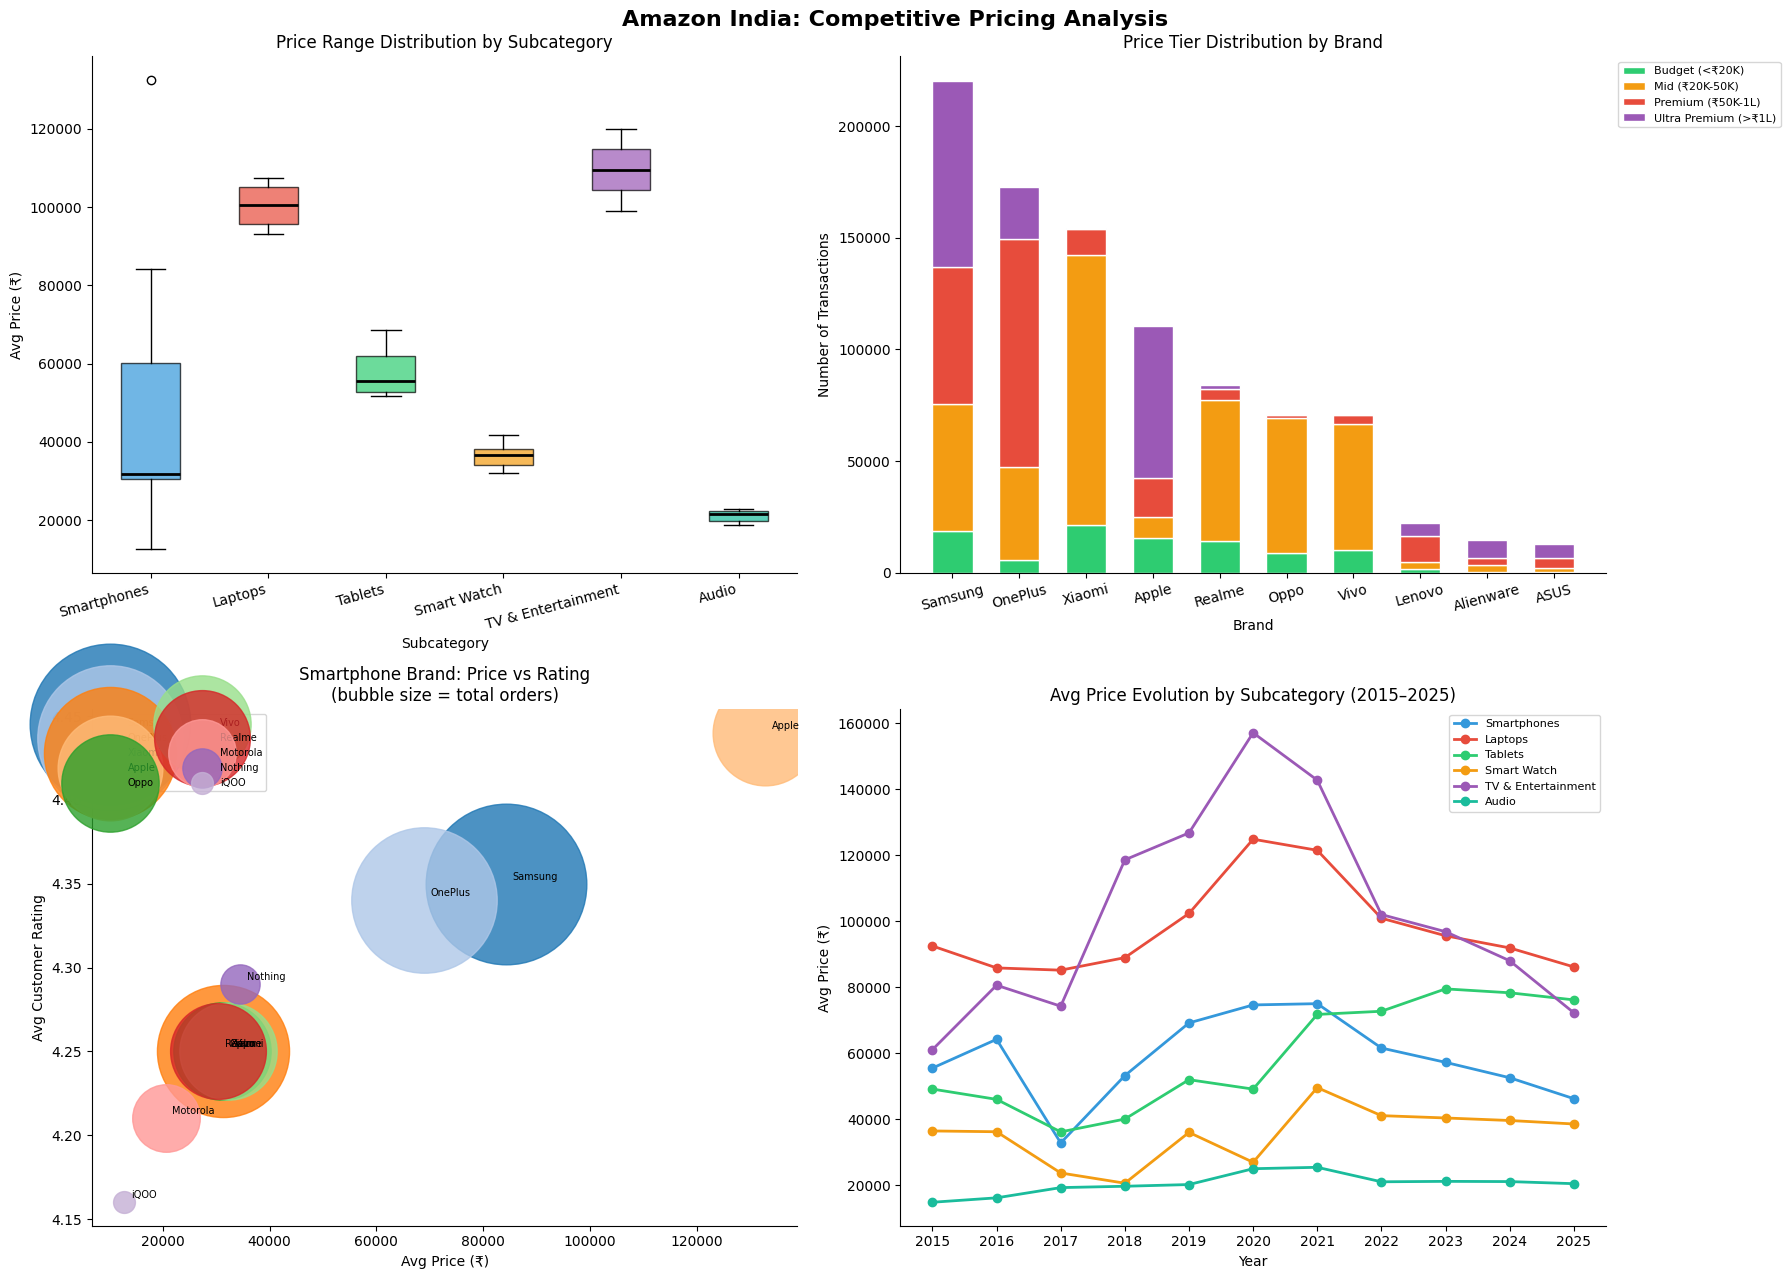

In [37]:
from sqlalchemy import text

# -- EDA Q19: Competitive Pricing Analysis  --------

# -- SQL Query 1: Brand Price Positioning --------------
query_brand_price = text("""
    SELECT
        brand,
        subcategory,
        ROUND(AVG(original_price_inr)::NUMERIC, 2)             AS avg_price,
        ROUND(MIN(original_price_inr)::NUMERIC, 2)             AS min_price,
        ROUND(MAX(original_price_inr)::NUMERIC, 2)             AS max_price,
        ROUND(STDDEV(original_price_inr)::NUMERIC, 2)          AS price_stddev,
        COUNT(DISTINCT product_id)                              AS total_products,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    GROUP BY brand, subcategory
    ORDER BY subcategory, avg_price DESC
""")

# -- SQL Query 2: Price Tier Distribution by Brand ------
query_price_tier = text("""
    SELECT
        brand,
        SUM(CASE WHEN original_price_inr < 20000
            THEN 1 ELSE 0 END)                                  AS budget,
        SUM(CASE WHEN original_price_inr BETWEEN 20000 AND 50000
            THEN 1 ELSE 0 END)                                  AS mid_range,
        SUM(CASE WHEN original_price_inr BETWEEN 50001 AND 100000
            THEN 1 ELSE 0 END)                                  AS premium,
        SUM(CASE WHEN original_price_inr > 100000
            THEN 1 ELSE 0 END)                                  AS ultra_premium,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    WHERE brand IN (
        SELECT brand FROM transactions
        GROUP BY brand
        ORDER BY SUM(final_amount_inr) DESC
        LIMIT 10
    )
    GROUP BY brand
    ORDER BY total_orders DESC
""")

# -- SQL Query 3: Subcategory Price Range Analysis ------
query_sub_price = text("""
    SELECT
        subcategory,
        brand,
        ROUND(AVG(original_price_inr)::NUMERIC, 2)             AS avg_price,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    WHERE customer_rating IS NOT NULL
    GROUP BY subcategory, brand
    ORDER BY subcategory, avg_price DESC
""")

# -- SQL Query 4: Price Evolution by Subcategory --------
query_price_evolution = text("""
    SELECT
        order_year,
        subcategory,
        ROUND(AVG(original_price_inr)::NUMERIC, 2)             AS avg_price,
        ROUND(MIN(original_price_inr)::NUMERIC, 2)             AS min_price,
        ROUND(MAX(original_price_inr)::NUMERIC, 2)             AS max_price
    FROM transactions
    GROUP BY order_year, subcategory
    ORDER BY order_year, subcategory
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_brand_price    = pd.read_sql(query_brand_price, conn)
    df_price_tier     = pd.read_sql(query_price_tier, conn)
    df_sub_price      = pd.read_sql(query_sub_price, conn)
    df_price_evo      = pd.read_sql(query_price_evolution, conn)

print("=== Brand Price Positioning (Smartphones Top 8) ===")
print(df_brand_price[df_brand_price["subcategory"] == "Smartphones"]
      .head(8).to_string(index=False))

# -- Plotting --------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Amazon India: Competitive Pricing Analysis",
             fontsize=16, fontweight="bold")

sub_colors = {
    "Smartphones":        "#3498db",
    "Laptops":            "#e74c3c",
    "Tablets":            "#2ecc71",
    "Smart Watch":        "#f39c12",
    "TV & Entertainment": "#9b59b6",
    "Audio":              "#1abc9c"
}

# -- Plot 1: Box Plot - Price Range by Subcategory ------
ax1 = axes[0, 0]
sub_price_data = [
    df_brand_price[df_brand_price["subcategory"] == sub]["avg_price"].values
    for sub in sub_colors.keys()
    if sub in df_brand_price["subcategory"].values
]
sub_labels = [s for s in sub_colors.keys()
              if s in df_brand_price["subcategory"].values]
bp = ax1.boxplot(sub_price_data, patch_artist=True,
                 medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], [sub_colors[s] for s in sub_labels]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title("Price Range Distribution by Subcategory", fontsize=12)
ax1.set_xlabel("Subcategory")
ax1.set_ylabel("Avg Price (₹)")
ax1.set_xticklabels(sub_labels, rotation=15, ha="right")
sns.despine(ax=ax1)

# -- Plot 2: Brand Price Tier Stacked Bar --------------
ax2 = axes[0, 1]
tier_cols   = ["budget", "mid_range", "premium", "ultra_premium"]
tier_colors = ["#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"]
tier_labels = ["Budget (<₹20K)", "Mid (₹20K-50K)",
               "Premium (₹50K-1L)", "Ultra Premium (>₹1L)"]
bottom = pd.Series([0] * len(df_price_tier))
for col, color, label in zip(tier_cols, tier_colors, tier_labels):
    ax2.bar(df_price_tier["brand"], df_price_tier[col],
            bottom=bottom, label=label, color=color, edgecolor="white", width=0.6)
    bottom += df_price_tier[col]
ax2.set_title("Price Tier Distribution by Brand", fontsize=12)
ax2.set_xlabel("Brand")
ax2.set_ylabel("Number of Transactions")
ax2.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax2.tick_params(axis="x", rotation=15)
sns.despine(ax=ax2)

# -- Plot 3: Price vs Rating Scatter by Brand ----------
ax3 = axes[1, 0]
smartphones_price = df_sub_price[df_sub_price["subcategory"] == "Smartphones"]
top_brands        = smartphones_price.nlargest(12, "total_orders")["brand"].unique()
brand_palette     = sns.color_palette("tab20", len(top_brands))
for brand, color in zip(top_brands, brand_palette):
    data = smartphones_price[smartphones_price["brand"] == brand]
    ax3.scatter(data["avg_price"], data["avg_rating"],
                s=data["total_orders"] / 10,
                color=color, alpha=0.8, label=brand)
    ax3.annotate(brand, (data["avg_price"].values[0],
                         data["avg_rating"].values[0]),
                 textcoords="offset points", xytext=(5, 3), fontsize=7)
ax3.set_title("Smartphone Brand: Price vs Rating\n(bubble size = total orders)",
              fontsize=12)
ax3.set_xlabel("Avg Price (₹)")
ax3.set_ylabel("Avg Customer Rating")
ax3.legend(fontsize=7, ncol=2)
sns.despine(ax=ax3)

# -- Plot 4: Price Evolution by Subcategory ------------
ax4 = axes[1, 1]
price_evo_pivot = df_price_evo.pivot(
    index="order_year", columns="subcategory", values="avg_price"
).fillna(0)
for col, color in sub_colors.items():
    if col in price_evo_pivot.columns:
        ax4.plot(price_evo_pivot.index, price_evo_pivot[col],
                 marker="o", linewidth=2, label=col, color=color)
ax4.set_title("Avg Price Evolution by Subcategory (2015–2025)", fontsize=12)
ax4.set_xlabel("Year")
ax4.set_ylabel("Avg Price (₹)")
ax4.legend(fontsize=8)
ax4.set_xticks(price_evo_pivot.index)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q19_competitive_pricing.png", dpi=150, bbox_inches="tight")
plt.show()

Question 20
Create a comprehensive business health dashboard combining key metrics like revenue growth, customer acquisition, retention rates, and operational efficiency using multi-panel visualizations with executive summary insights.


=== Overall Business KPIs ===
 total_customers  total_orders  total_revenue_cr  avg_order_value  avg_discount  avg_delivery_days  return_rate  avg_rating  prime_rate
          354362       1116110           7010.45         62811.46         17.42               3.32         7.02        4.31       38.31


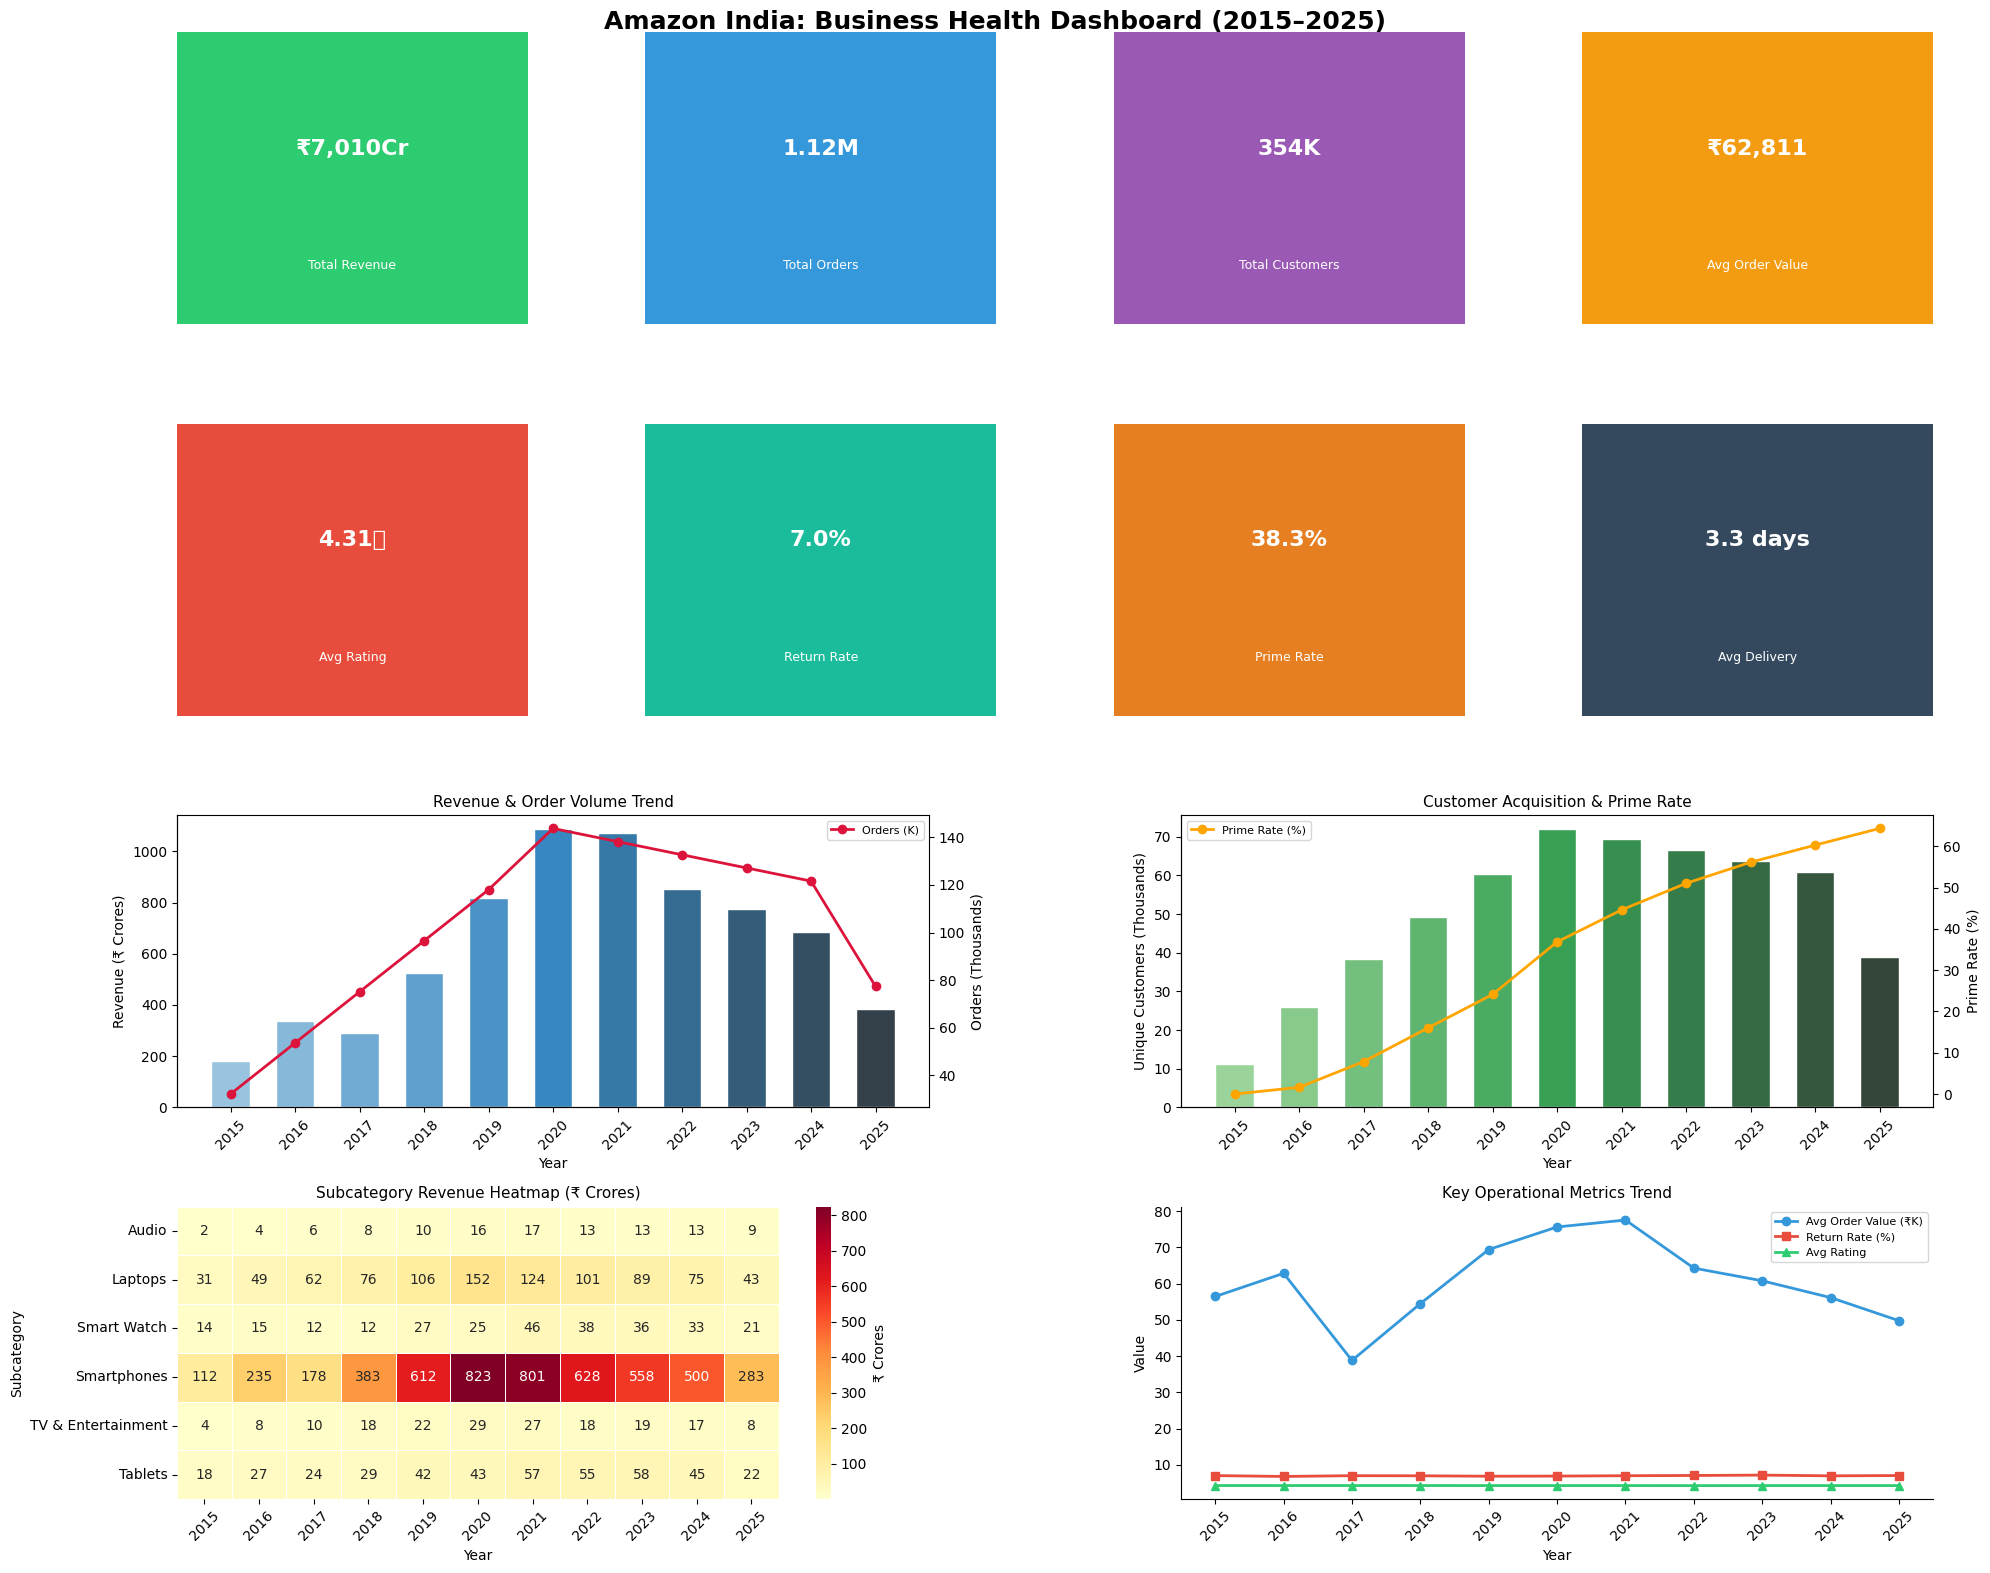

In [38]:

from sqlalchemy import text

# -- EDA Q20: Business Health Dashboard ----------

# -- SQL Query 1: Overall KPIs ------------------------
query_kpi = text("""
    SELECT
        COUNT(DISTINCT customer_id)                             AS total_customers,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS total_revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND(AVG(discount_percent)::NUMERIC, 2)               AS avg_discount,
        ROUND(AVG(delivery_days)::NUMERIC, 2)                  AS avg_delivery_days,
        ROUND((SUM(CASE WHEN return_status = 'Returned'
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                AS return_rate,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating,
        ROUND((SUM(CASE WHEN is_prime_member = TRUE
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                AS prime_rate
    FROM transactions
""")

# -- SQL Query 2: YoY Revenue & Orders ----------------
query_yoy = text("""
    SELECT
        order_year,
        COUNT(DISTINCT customer_id)                             AS unique_customers,
        COUNT(transaction_id)                                   AS total_orders,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        ROUND(AVG(final_amount_inr)::NUMERIC, 2)               AS avg_order_value,
        ROUND((SUM(CASE WHEN return_status = 'Returned'
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                AS return_rate,
        ROUND(AVG(customer_rating)::NUMERIC, 2)                AS avg_rating,
        ROUND((SUM(CASE WHEN is_prime_member = TRUE
            THEN 1 ELSE 0 END) * 100.0 /
            COUNT(transaction_id))::NUMERIC, 2)                AS prime_rate
    FROM transactions
    GROUP BY order_year
    ORDER BY order_year
""")

# -- SQL Query 3: Revenue by Subcategory & Year --------
query_sub_year = text("""
    SELECT
        order_year,
        subcategory,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr
    FROM transactions
    GROUP BY order_year, subcategory
    ORDER BY order_year, revenue_cr DESC
""")

# -- SQL Query 4: Monthly Revenue Last 2 Years ----------
query_monthly = text("""
    SELECT
        order_year,
        order_month,
        ROUND((SUM(final_amount_inr) / 1e7)::NUMERIC, 2)       AS revenue_cr,
        COUNT(transaction_id)                                   AS total_orders
    FROM transactions
    WHERE order_year IN (2024, 2025)
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""")

# -- Fetch Data ------------------------
with engine.connect() as conn:
    df_kpi      = pd.read_sql(query_kpi, conn)
    df_yoy      = pd.read_sql(query_yoy, conn)
    df_sub_year = pd.read_sql(query_sub_year, conn)
    df_monthly  = pd.read_sql(query_monthly, conn)

print("=== Overall Business KPIs ===")
print(df_kpi.to_string(index=False))

# -- Plotting --------------------------
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Amazon India: Business Health Dashboard (2015–2025)",
             fontsize=18, fontweight="bold", y=0.98)

# -- KPI Cards Row --------------------------------------
kpi_data = [
    ("Total Revenue",    f"₹{df_kpi['total_revenue_cr'].values[0]:,.0f}Cr",  "#2ecc71"),
    ("Total Orders",     f"{df_kpi['total_orders'].values[0]/1e6:.2f}M",      "#3498db"),
    ("Total Customers",  f"{df_kpi['total_customers'].values[0]/1e3:.0f}K",   "#9b59b6"),
    ("Avg Order Value",  f"₹{df_kpi['avg_order_value'].values[0]:,.0f}",      "#f39c12"),
    ("Avg Rating",       f"{df_kpi['avg_rating'].values[0]:.2f}⭐",            "#e74c3c"),
    ("Return Rate",      f"{df_kpi['return_rate'].values[0]:.1f}%",           "#1abc9c"),
    ("Prime Rate",       f"{df_kpi['prime_rate'].values[0]:.1f}%",            "#e67e22"),
    ("Avg Delivery",     f"{df_kpi['avg_delivery_days'].values[0]:.1f} days", "#34495e"),
]
for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_subplot(4, 4, i + 1)
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha="center", va="center",
            fontsize=16, fontweight="bold", color="white",
            transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha="center", va="center",
            fontsize=9, color="white", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# -- Plot 1: Revenue & Orders Trend --------------------
ax1 = fig.add_subplot(4, 2, 5)
bars = ax1.bar(df_yoy["order_year"], df_yoy["revenue_cr"],
               color=sns.color_palette("Blues_d", len(df_yoy)),
               edgecolor="white", width=0.6)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_yoy["order_year"], df_yoy["total_orders"] / 1e3,
              color="crimson", marker="o", linewidth=2, label="Orders (K)")
ax1.set_title("Revenue & Order Volume Trend", fontsize=11)
ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue (₹ Crores)")
ax1_twin.set_ylabel("Orders (Thousands)")
ax1_twin.legend(loc="upper right", fontsize=8)
ax1.set_xticks(df_yoy["order_year"])
ax1.tick_params(axis="x", rotation=45)
sns.despine(ax=ax1)

# -- Plot 2: Customer Acquisition Trend ----------------
ax2 = fig.add_subplot(4, 2, 6)
ax2.bar(df_yoy["order_year"], df_yoy["unique_customers"] / 1e3,
        color=sns.color_palette("Greens_d", len(df_yoy)),
        edgecolor="white", width=0.6)
ax2_twin = ax2.twinx()
ax2_twin.plot(df_yoy["order_year"], df_yoy["prime_rate"],
              color="orange", marker="o", linewidth=2, label="Prime Rate (%)")
ax2.set_title("Customer Acquisition & Prime Rate", fontsize=11)
ax2.set_xlabel("Year")
ax2.set_ylabel("Unique Customers (Thousands)")
ax2_twin.set_ylabel("Prime Rate (%)")
ax2_twin.legend(loc="upper left", fontsize=8)
ax2.set_xticks(df_yoy["order_year"])
ax2.tick_params(axis="x", rotation=45)
sns.despine(ax=ax2)

# -- Plot 3: Subcategory Revenue Heatmap --------------
ax3 = fig.add_subplot(4, 2, 7)
sub_pivot = df_sub_year.pivot(
    index="subcategory", columns="order_year", values="revenue_cr"
).fillna(0)
sns.heatmap(sub_pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax3, cbar_kws={"label": "₹ Crores"})
ax3.set_title("Subcategory Revenue Heatmap (₹ Crores)", fontsize=11)
ax3.set_xlabel("Year")
ax3.set_ylabel("Subcategory")
ax3.tick_params(axis="x", rotation=45)
ax3.tick_params(axis="y", rotation=0)

# -- Plot 4: Key Metrics Trend ------------------------
ax4 = fig.add_subplot(4, 2, 8)
ax4.plot(df_yoy["order_year"], df_yoy["avg_order_value"] / 1e3,
         marker="o", linewidth=2, color="#3498db", label="Avg Order Value (₹K)")
ax4.plot(df_yoy["order_year"], df_yoy["return_rate"],
         marker="s", linewidth=2, color="#e74c3c", label="Return Rate (%)")
ax4.plot(df_yoy["order_year"], df_yoy["avg_rating"],
         marker="^", linewidth=2, color="#2ecc71", label="Avg Rating")
ax4.set_title("Key Operational Metrics Trend", fontsize=11)
ax4.set_xlabel("Year")
ax4.set_ylabel("Value")
ax4.legend(fontsize=8)
ax4.set_xticks(df_yoy["order_year"])
ax4.tick_params(axis="x", rotation=45)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig("eda_q20_business_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()